# DRG calcium imaging — event detection before vs after SNI

**Questions.** (1) Does a cell's response *pattern* change after spared-nerve injury? (2) Does its
response *amplitude* go up or down? Both are **within-cell, before-versus-after** questions, and that
drives every design decision below.

> Full write-up — the reasoning behind each section, and what the x, y and colour of every figure
> mean — is in **`README.md`**, under *Analysis notebook*. This cell is the short version.

**Method.** Event detection on the CASCADE inferred rate → features → two outputs. Per cell, a
threshold of `baseline mean + DETECT_K·SD` is built from the **pre-stimulus segment only**,
sub-threshold signal is erased, and runs of `N_CONSEC` supra-threshold frames count as events.
Spike inference is **not run here**: §6 loads pre-computed runs from
`data/pro_drg/<group>/<FOV>/<model>/spike_rate.npy`.

### Five conventions that explain most of the code

| | |
| --- | --- |
| **Threshold from S1 only** | Using the whole trace is circular — a strong responder inflates its own SD and censors itself. `detect_events` is protocol-blind so this holds in both parts. |
| **0 ≠ NaN** | Erased sub-threshold bins are `0` ("no activity"); CASCADE's edge padding is `NaN` ("not measured"). They never mix — grey vs near-black in every figure. |
| **Original scale** | No per-cell normalisation. Dividing a cell by its own total would divide out the biology: a cell whose response grew 10× would look unchanged. |
| **Declared, not fitted** | Segment edges, `DETECT_K`, `ON_GAP_HIGH`, `EARLY_MAX_TRIAL` are parameters in Config. A fitted cut would mean something different on the two days. |
| **Chance from a circular shift** | Rotating a cell's finite samples preserves its own statistics and destroys only its alignment to the stimulus — exactly what the claim is about. |

Detection is **one-sided** (the rate is non-negative and zero-inflated), so this pipeline detects
*increases*. **It cannot see a cell going silent.**

### The analysis forks after §8

The two protocols are not the same experiment with different words:

| | clip | graze |
| --- | --- | --- |
| stimulus | one 20 s application | 12 × (5 s on, 5 s gap) |
| share of recording | 20 s of ~70 s | 120 s of 135 s (**89 %**) |
| window afterwards | ~32–40 s | **9.9 s → no "chronic" claim is possible** |
| natural label | 3 bits, `S1 S2 S3` | per-cycle: when it started, how phasic |

A 3-bit label on graze puts 89 % of the recording inside one `S2` bit, so nearly every responder
becomes `010` and a circular shift leaves the response inside `S2` almost regardless of offset.
Hence **Part A = clip, Part B = graze**, routed on `experiment`, sharing every function.

| § | Step | Produces |
| --- | --- | --- |
| 0–7 | Setup · load · ROI map · preprocess · model pick · traces | ΔF/F + inferred rate, re-zeroed to pre-stimulus |
| 8 | Event detection | protocol-dependent **segments** with kinds `{pre, on, gap, post}`; protocol-blind **threshold** |
| 8a · 8b · 8c | Pre-flight checks · circular-shift null (**constrained for graze**) · shared amplitude/shape helpers | chance level, and the offset-pool guard |
| **9A · 9Ab** | *clip* — 3-bit segment labels + per-segment amplitude · does shape separate anything? | labels like `010`, `001` |
| **10A · 11A** | *clip* — PCA + k-means · transition matrix | clusters, Baseline label × SNI label |
| **12A · 12Ab · 12Ac** | *clip* — spectrum, and two ways to drop quiet rows | every ROI over time, rows ordered by weight |
| **9B** | *graze* — per-cycle table + 5-way phenotype | `first_trial`, `on_gap_ratio`, phase locking |
| **10B · 11B · 12B** | *graze* — PCA + k-means · transitions · spectrum with per-cycle markers | weight from the **constrained** shift over the ON windows |
| 12d | Row index → ROI id | pins a "rows 150–250" claim to actual cells |
| 13 · 14 · 15 | Response across cycles · clip phenotype accounting · co-activation | the trend test, group counts, synchrony vs a null |

**Row numbers are figure-local.** §12A, §12Ab, §12Ac and §12B each sort a different surviving subset,
and cells with no detected event score weight `0` *exactly*, forming a large tied block that
`argsort` orders arbitrarily. A row range inside that block names no reproducible set of cells.
**§12d converts rows to ROI ids, and everything after it takes ids.**

### Not answerable here

No marker channel → **no cell-type claim**. No SNI variant or skin territory in the files → both are
config strings in §12d, typed in and printed, never inferred. One animal, one session, one FOV →
every percentage has *cells* for its denominator, not mice.

## 0. Setup

In [77]:
from __future__ import annotations

import itertools
import json
import re
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "image.interpolation": "nearest", "axes.grid": False})
print(f"numpy {np.__version__} | pandas {pd.__version__} — imports ready")

numpy 2.4.6 | pandas 3.0.2 — imports ready


### Config

The only cell you normally edit. `FOVS` is set to FOV3 alone; add `"FOV1", "FOV2"` to widen.

In [78]:
# ── Input ──────────────────────────────────────────────────────────────────────
PRO_ROOT   = Path("/Users/samsonho/KSL/data/pro_drg")   # pre-computed spike inference
TRACE_ROOT = Path("/Users/samsonho/KSL/leftDRGcut")     # the dF/F exports behind it
FOVS       = ("FOV3",)                                  # FOV3 first; add FOV1/FOV2 to widen
EXPERIMENTS = ("graze", "clip")
GROUPS = {("Baseline", "graze"): "Baseline_Graze", ("Baseline", "clip"): "Baseline_Clip",
          ("SNI", "graze"): "SNI-live_Graze",     ("SNI", "clip"): "SNI-live_Clip"}
MODEL_DEFAULT = "GC8_EXC_10Hz_smoothing150ms_high_noise"

# ── Stimulus protocol (seconds) ────────────────────────────────────────────────
# graze: 5 s baseline, then 12 x (5 s graze, 5 s gap)  ->  stimulus block 5–125 s
# clip : applied at 10 s, withdrawn at 30 s
GRAZE_BASELINE_S, GRAZE_CYCLE_S, GRAZE_ON_S, GRAZE_N_TRIALS = 5.0, 10.0, 5.0, 12
CLIP_ON_S, CLIP_OFF_S = 10.0, 30.0

# ── Protocol routing — the analysis forks after §8 ─────────────────────────────
# The two protocols answer different questions and cannot share a segment model. clip has one
# 20 s application inside a ~70 s recording, so before/during/after is the right frame. graze
# has 12 repeats filling 92% of the recording, so "during" is nearly the whole trace and a
# 3-segment label carries almost no information. Everything up to and including §8 is shared;
# §9A–§12A are clip, §9B–§12B are graze.
PART_A = tuple(e for e in EXPERIMENTS if e == "clip")     # 3 segments
PART_B = tuple(e for e in EXPERIMENTS if e == "graze")    # 26 segments, per-cycle

# ── Segments (§8) — BOUNDARIES ARE A PARAMETER, not auto-selected ──────────────
# Seconds, clip only. The last edge is None = end of recording. The graze edges are generated
# from the protocol constants above (S1, then an ON and a GAP window per cycle, then S3), so
# there is nothing to hand-set. In both cases the FIRST segment is the pre-stimulus window:
# the detection threshold is computed there and nowhere else, in both protocols.
SEGMENT_EDGES_S = {"clip": (0.0, 10.0, 30.0, None)}       # before | clip applied | after
GRAZE_MIN_POST_S = 10.0    # below this, graze cannot carry a "chronic / post-stimulus" claim

# ── Event detection (§8) ───────────────────────────────────────────────────────
DETECT_K   = 3.0    # threshold = baseline mean + DETECT_K x baseline SD, one-sided
N_CONSEC   = 3      # frames a crossing must last to count as an event (2 or 3 at ~10 Hz)
NULL_SHIFTS = 5     # circular-shift surrogates for the empirical calibration in §8b
MIN_BASELINE_FRAMES = 20   # usable (non-NaN) frames the threshold must be built from

# ── Constrained circular shift for graze (§8b, §12B) ───────────────────────────
# An offset of about k whole cycles lands the response back on top of a DIFFERENT cycle, so the
# surrogate is still stimulus-locked and the null is inflated — which is why the unconstrained
# shift has almost no power on graze. Offsets within CYCLE_EXCLUSION_FRAMES of any multiple of
# the cycle period are therefore illegal. clip has one application and does not have this
# problem, so its shift is unconstrained.
CYCLE_EXCLUSION_FRAMES = None   # None = half the ON window, in frames
SHIFT_POOL_FACTOR = 10          # legal offsets must outnumber the surrogates by this factor
SPECTRUM_N_SURROGATES_GRAZE = 60   # capped by the pool — see the arithmetic printed in §8b

# ── graze phenotype label (§9B) — DECLARED, not fitted ─────────────────────────
EARLY_MAX_TRIAL = 3     # first responded cycle <= this = "early"; >= 4 = "late"
ON_GAP_HIGH = 2.0       # on_gap_ratio >= this = "phasic"; below = "tonic". Pick by looking at
                        # the distribution §9B prints, not by optimising anything.
ON_GAP_EPS = 0.01       # regulariser for log10(on/gap); ~ the AUC of one minimal event
RAYLEIGH_MIN_EVENTS = 3 # fewer detected events than this -> phase statistics undefined

# ── Spectrum (§12A / §12B) ─────────────────────────────────────────────────────
# What the ROI rows are ordered by. "significance" = -log10(p) against the §8b circular-shift
# null; the others are original-scale amplitude columns from the §9 table.
SPECTRUM_WEIGHT = "significance"   # significance | auc_stim | auc_total | peak_total | n_event_frames
SPECTRUM_N_SURROGATES = 200        # clip; graze uses SPECTRUM_N_SURROGATES_GRAZE above

# ── Clustering (§10A / §10B) ───────────────────────────────────────────────────
CLUSTER_K = 4       # k-means on [amplitude axes + timing axes], fitted once on both datasets

# ── PCA ────────────────────────────────────────────────────────────────────────
PCA_ARRANGEMENT_DEFAULT = "B"      # "A" = time x neurons | "B" = neurons x features
PCA_N_COMPONENTS        = 4

# ── Output ─────────────────────────────────────────────────────────────────────
SAVE_OUTPUTS = False
OUTPUT_DIR   = Path("main_new_output")

print(f"pro_drg {PRO_ROOT}\ntraces  {TRACE_ROOT}\nFOVs {list(FOVS)}  |  experiments "
      f"{list(EXPERIMENTS)}  |  model {MODEL_DEFAULT}\n"
      f"detection: threshold = baseline mean + {DETECT_K:g} SD (one-sided), "
      f"event = {N_CONSEC} consecutive frames\n"
      f"fork after §8:  Part A (3 segments) {list(PART_A)}  |  "
      f"Part B (per-cycle) {list(PART_B)}\n"
      f"clip segments: {SEGMENT_EDGES_S['clip']}  |  graze segments: generated, "
      f"1 + 2x{GRAZE_N_TRIALS} + 1 = {2 + 2 * GRAZE_N_TRIALS}")

pro_drg /Users/samsonho/KSL/data/pro_drg
traces  /Users/samsonho/KSL/leftDRGcut
FOVs ['FOV3']  |  experiments ['graze', 'clip']  |  model GC8_EXC_10Hz_smoothing150ms_high_noise
detection: threshold = baseline mean + 3 SD (one-sided), event = 3 consecutive frames
fork after §8:  Part A (3 segments) ['clip']  |  Part B (per-cycle) ['graze']
clip segments: (0.0, 10.0, 30.0, None)  |  graze segments: generated, 1 + 2x12 + 1 = 26


In [79]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name: str) -> None:
    """Write a figure to OUTPUT_DIR when SAVE_OUTPUTS is on. Figures always show inline."""
    if SAVE_OUTPUTS:
        fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")


print("figures " + (f"-> {OUTPUT_DIR}/" if SAVE_OUTPUTS else "inline only")
      + "  |  nothing is written into the dataset folders")

figures inline only  |  nothing is written into the dataset folders


## 1. Load the recordings

Each recording is one `spike_rate.npy` under `pro_drg/<group>/<FOV>/<model>/`, plus the
`*_roi_traces.txt` it was computed from. The params JSON names that source file and the ROI ids, so
the two are matched by provenance rather than by guesswork.

Only `Trace_ROI<x>` is read from the export — `Green_Mean_` / `Red_Mean_` are raw camera counts
(~220), not dF/F. ROIs are ordered **numerically**: a text sort puts `ROI10` before `ROI2`, and that
order would silently become the row order of every matrix downstream.

In [80]:
_TRACE_COL = re.compile(r"^Trace_ROI(\d+)$")


def load_dff(txt_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Parse one export -> time_s, dff (n_time, n_roi), roi_ids — numerically ordered."""
    table = pd.read_csv(txt_path, sep="\t")
    cols = sorted((int(m.group(1)), c) for c in table.columns if (m := _TRACE_COL.match(c)))
    return (table["Time"].to_numpy(float),
            table[[c for _, c in cols]].to_numpy(np.float32),
            np.array([i for i, _ in cols], dtype=np.int32))


def available_models() -> list[str]:
    """Model folders present for every group/FOV we need, so a pick is always loadable."""
    per_run = []
    for (cond, exp), group in GROUPS.items():
        for fov in FOVS:
            run = PRO_ROOT / group / fov
            if run.is_dir():
                per_run.append({p.name for p in run.iterdir()
                                if p.is_dir() and (p / "spike_rate.npy").is_file()})
    return sorted(set.intersection(*per_run)) if per_run else []


def load_recording(cond: str, exp: str, fov: str, model: str) -> dict:
    """Spike rate + its source dF/F, checked against the params JSON."""
    run = PRO_ROOT / GROUPS[(cond, exp)] / fov / model
    params = json.loads((run / "spike_inference_params.json").read_text())
    rate = np.load(run / "spike_rate.npy").T                      # -> (n_time, n_roi)

    # The params name the trace export this run came from, as a path under a "raw_data" root.
    # Resolve the WHOLE relative path, not just the filename: Baseline and SNI use identical
    # file names, so matching on name alone silently loads the wrong day's traces.
    rel = Path(params["source_trace_file"])
    if rel.parts and rel.parts[0] == "raw_data":
        rel = Path(*rel.parts[1:])
    source = TRACE_ROOT / rel
    if not source.is_file():
        raise FileNotFoundError(f"{cond} {exp} {fov}: source trace not found at {source}")
    time_s, dff, roi_ids = load_dff(source)

    if rate.shape != dff.shape:
        raise ValueError(f"{cond} {exp} {fov}: rate {rate.shape} != dF/F {dff.shape}")
    if not np.array_equal(roi_ids, np.array(params["roi_ids"], dtype=np.int32)):
        raise ValueError(f"{cond} {exp} {fov}: ROI ids disagree with the params JSON")
    return {"time_s": time_s, "dff": dff, "rate": rate, "roi_ids": roi_ids,
            "params": params, "source": source}


MODELS = available_models()
if MODEL_DEFAULT not in MODELS:
    raise FileNotFoundError(f"{MODEL_DEFAULT} is not present for every run; found {MODELS}")

runs = {}
for (cond, exp) in GROUPS:
    if exp not in EXPERIMENTS:
        continue
    for fov in FOVS:
        runs[(cond, exp, fov)] = load_recording(cond, exp, fov, MODEL_DEFAULT)

overview = pd.DataFrame([
    {"condition": k[0], "experiment": k[1], "fov": k[2], "n_roi": v["dff"].shape[1],
     "n_frames": v["dff"].shape[0], "dur_s": round(float(v["time_s"][-1]), 1),
     "fps": round((len(v["time_s"]) - 1) / (v["time_s"][-1] - v["time_s"][0]), 2),
     "rate_nan_%": round(100 * float(np.isnan(v["rate"]).mean()), 1),
     "source": v["source"].name[:38]}
    for k, v in runs.items()])

print(f"{len(MODELS)} model(s) available for every run: {', '.join(MODELS)}")
display(overview)

1 model(s) available for every run: GC8_EXC_10Hz_smoothing150ms_high_noise


,condition,experiment,fov,n_roi,n_frames,dur_s,fps,rate_nan_%,source
0,Baseline,graze,FOV3,291,1420,134.9,10.52,2.3,RightDRG_FOV3_Graze_FOOT_5s10isi12x_ro
1,Baseline,clip,FOV3,291,734,69.7,10.52,4.5,RightDRG_FOV3_clip_FOOT_10s20secs_roi_
2,SNI,graze,FOV3,349,1420,134.9,10.52,2.3,RightDRG_FOV3_Graze_FOOT_5s10isi12x_ro
3,SNI,clip,FOV3,349,652,61.9,10.52,5.1,RightDRG_FOV3_clip_FOOT_10s20secs_roi_


## 2. ROI map

`*_roi_positions.json` gives one bounding box per ROI, `"ROI <x>"` matching `Trace_ROI<x>`. It is a
list of boxes, not a label image, so centroids and box sizes are what the geometry supports — there
are no masks or pixel areas here.

In [81]:
def load_roi_map(source_trace: Path) -> dict | None:
    """The positions JSON belonging to a traces export -> ids, centroids (x, y), box sizes.

    Scoped to that export's own condition folder: the two days use identical file names, so a
    search across the whole tree would return the wrong day's geometry.
    """
    condition_dir = TRACE_ROOT / source_trace.relative_to(TRACE_ROOT).parts[0]
    stem = source_trace.name.replace("_roi_traces.txt", "")
    for name in (f"{stem}_roi_positions.json", f"{stem}_roi_position.json"):   # FOV3 lacks the 's'
        hits = sorted(condition_dir.rglob(name))
        if hits:
            rois = json.loads(hits[0].read_text())["rois"]
            ids = np.array([int(re.search(r"(\d+)", r["name"]).group(1)) for r in rois])
            box = np.array([r["xyxy"] for r in rois], dtype=float)
            order = np.argsort(ids)
            return {"roi_ids": ids[order],
                    "centroids": np.column_stack([(box[:, 0] + box[:, 2]) / 2,
                                                  (box[:, 1] + box[:, 3]) / 2])[order],
                    "sizes": np.column_stack([box[:, 2] - box[:, 0],
                                              box[:, 3] - box[:, 1]])[order]}
    return None


roi_maps = {k: load_roi_map(v["source"]) for k, v in runs.items()}
for k, m in roi_maps.items():
    if m is not None and len(m["roi_ids"]) != runs[k]["dff"].shape[1]:
        raise ValueError(f"{k}: {len(m['roi_ids'])} ROIs in the position JSON but "
                         f"{runs[k]['dff'].shape[1]} trace columns")

found = {k: m for k, m in roi_maps.items() if m is not None}
print(f"{len(found)}/{len(roi_maps)} ROI maps found, each matching its recording's ROI count"
      + (f"  |  box sizes {np.concatenate([m['sizes'].ravel() for m in found.values()]).min():.0f}–"
         f"{np.concatenate([m['sizes'].ravel() for m in found.values()]).max():.0f} px" if found else ""))

4/4 ROI maps found, each matching its recording's ROI count  |  box sizes 5–29 px


## 3. The field and the ROIs

Baseline against SNI for each FOV. **No denoiser dropdown**: denoising acts on image frames and this
dataset has none — the traces arrive already extracted and already normalised.

Read the ROI counts in the titles. They differ between the two days, which is the caveat §9 opens
with.

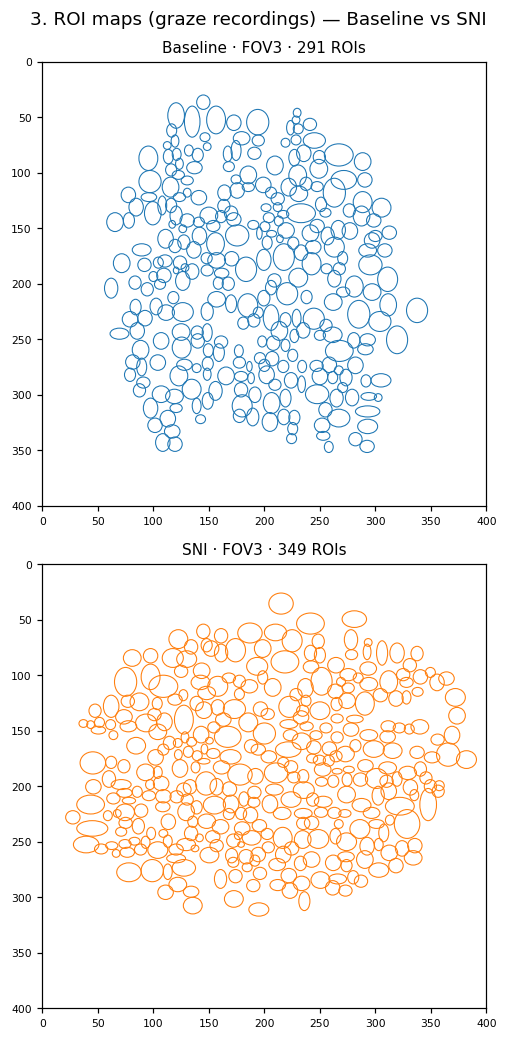

ROI counts:  FOV3 Baseline 291, SNI 349


In [82]:
CONDITIONS = ("Baseline", "SNI")
fig, axes = plt.subplots(len(CONDITIONS), len(FOVS), squeeze=False,
                         figsize=(4.8 * len(FOVS), 4.8 * len(CONDITIONS)))
for r, cond in enumerate(CONDITIONS):
    for c, fov in enumerate(FOVS):
        ax = axes[r][c]
        m = roi_maps.get((cond, "graze", fov))
        if m is None:
            ax.axis("off")
            continue
        for (x, y), (w, h) in zip(m["centroids"], m["sizes"]):
            ax.add_patch(Ellipse((x, y), w, h, facecolor="none", edgecolor=plt.cm.tab10(r), lw=0.7))
        ax.set_xlim(0, 400); ax.set_ylim(400, 0); ax.set_aspect("equal")
        ax.set_title(f"{cond} · {fov} · {len(m['roi_ids'])} ROIs", fontsize=10)
        ax.tick_params(labelsize=7)
fig.suptitle("3. ROI maps (graze recordings) — Baseline vs SNI")
fig.tight_layout()
save_fig(fig, "3_roi_maps")
plt.show()
print("ROI counts:  " + "  |  ".join(
    f"{fov} " + ", ".join(f"{c} {len(roi_maps[(c, 'graze', fov)]['roi_ids'])}"
                          for c in CONDITIONS if roi_maps.get((c, "graze", fov)) is not None)
    for fov in FOVS))

## 4. Napari — unavailable for this dataset

The viewer opens a frame stack and lets ROI masks be repainted. These folders hold traces, spike
rates and boxes — no frames and no label image — so there is nothing to open, and nothing
downstream needs a mask.

In [83]:
print("napari skipped: traces-only dataset (no .npy frame stack, no label TIFF).")

napari skipped: traces-only dataset (no .npy frame stack, no label TIFF).


## 5. Preprocess — re-zero dF/F to the pre-stimulus window

`Trace_ROI<x>` is already dF/F, produced upstream against a full-trace baseline and documented as
not re-baselinable from these files. So this is **not** a dF/F₀ computation — each ROI simply has
its own pre-stimulus mean subtracted, so that "response amplitude" means the same thing on both
days. The shape of the signal is untouched.

The spike rate is left exactly as computed; its edge `NaN`s are CASCADE's padding (17 frames per
end) and are kept as `NaN`.

In [84]:
def prestim_window(experiment: str) -> tuple[float, float]:
    """The quiet window before the first stimulus."""
    return (0.0, GRAZE_BASELINE_S) if experiment == "graze" else (0.0, CLIP_ON_S)


def stimulus_spans(experiment: str, t_end: float) -> list[tuple[float, float]]:
    """The windows when the stimulus is on."""
    if experiment == "graze":
        return [(GRAZE_BASELINE_S + i * GRAZE_CYCLE_S,
                 GRAZE_BASELINE_S + i * GRAZE_CYCLE_S + GRAZE_ON_S) for i in range(GRAZE_N_TRIALS)]
    return [(CLIP_ON_S, min(CLIP_OFF_S, t_end))]


for (cond, exp, fov), rec in runs.items():
    lo, hi = prestim_window(exp)
    pre = (rec["time_s"] >= lo) & (rec["time_s"] < hi)
    if pre.sum() < 5:
        raise ValueError(f"{cond} {exp} {fov}: pre-stimulus window holds {int(pre.sum())} frames")
    rec["dff"] = rec["dff"] - rec["dff"][pre].mean(axis=0, keepdims=True)
    rec["pre"] = pre

qc = pd.DataFrame([
    {"condition": k[0], "experiment": k[1], "fov": k[2],
     "pre_window_s": f"{prestim_window(k[1])[0]:.0f}–{prestim_window(k[1])[1]:.0f}",
     "pre_frames": int(v["pre"].sum()),
     "dff_p1": round(float(np.percentile(v["dff"], 1)), 3),
     "dff_p99": round(float(np.percentile(v["dff"], 99)), 3),
     "rate_mean": round(float(np.nanmean(v["rate"])), 4),
     "rate_max": round(float(np.nanmax(v["rate"])), 2),
     "rate_min": round(float(np.nanmin(v["rate"])), 4)}
    for k, v in runs.items()])
print(f"{len(runs)} recordings re-zeroed. The spike rate carries small negatives — §8 clips it at 0 "
      "before taking fractions.")
display(qc)

4 recordings re-zeroed. The spike rate carries small negatives — §8 clips it at 0 before taking fractions.


,condition,experiment,fov,pre_window_s,pre_frames,dff_p1,dff_p99,rate_mean,rate_max,rate_min
0,Baseline,graze,FOV3,0–5,53,-0.086,0.091,0.0298,17.02,-0.0308
1,Baseline,clip,FOV3,0–10,106,-0.147,0.466,0.0442,20.72,-0.0396
2,SNI,graze,FOV3,0–5,53,-0.122,0.117,0.0280,9.62,-0.0336
3,SNI,clip,FOV3,0–10,106,-0.175,0.205,0.0438,18.93,-0.0363


## 6. Spike inference — pick which pre-computed run to use

Inference is **not run here**. The dropdown lists the model folders that exist for *every*
group/FOV in this session, so any pick loads cleanly. The default,
`GC8_EXC_10Hz_smoothing150ms_high_noise`, is GCaMP8 trained at 10 Hz against a 10.53 Hz
acquisition — a 0.95 resample rather than the ~3× round trip a 30 Hz model would need.

The rate is a **model-estimated expected spike rate**, not detected spikes, and is never
thresholded into events here.

In [85]:
model_choice = widgets.Dropdown(
    options=MODELS, value=MODEL_DEFAULT, description="model:",
    style={"description_width": "initial"}, layout=widgets.Layout(width="620px"))
display(model_choice)

p = runs[("Baseline", EXPERIMENTS[0], FOVS[0])]["params"]
print(f"{len(MODELS)} model(s) available for every run  |  loaded: {MODEL_DEFAULT}\n"
      f"  algorithm     {p['algorithm']}\n"
      f"  trained on    {', '.join(p['model_training_datasets'])}\n"
      f"  model rate    {p['model_rate_hz_from_name']} Hz vs recording "
      f"{p['recording_frame_rate_hz']:.2f} Hz (resample {p['resample_ratio']:.3f}, "
      f"{p['resample_method'].split('(')[0].strip()})\n"
      f"  units         {p['output_units']}  |  padding {p['padding']}, "
      f"{p['pad_frames_per_end']} frames per end\n"
      "Changing the dropdown changes nothing until you re-run §1 with MODEL_DEFAULT set to it.")

Dropdown(description='model:', layout=Layout(width='620px'), options=('GC8_EXC_10Hz_smoothing150ms_high_noise'…

1 model(s) available for every run  |  loaded: GC8_EXC_10Hz_smoothing150ms_high_noise
  algorithm     CASCADE (Rupprecht et al. 2021), CascadeTorch
  trained on    DS30-GCaMP8f-m-V1, DS31-GCaMP8m-m-V1, DS32-GCaMP8s-m-V1
  model rate    10.0 Hz vs recording 10.53 Hz (resample 0.950, scipy.signal.resample_poly)
  units         spikes/s (CASCADE spikes-per-frame x grid rate)  |  padding nan, 17 frames per end
Changing the dropdown changes nothing until you re-run §1 with MODEL_DEFAULT set to it.


## 7. Traces per ROI

A few hundred ROIs per recording, so the per-ROI view is a heatmap sorted by response rather than a
grid of line plots: **dF/F** first, then the **inferred rate**, same row order in both so a cell can
be compared line for line. Red bars mark the stimulus.

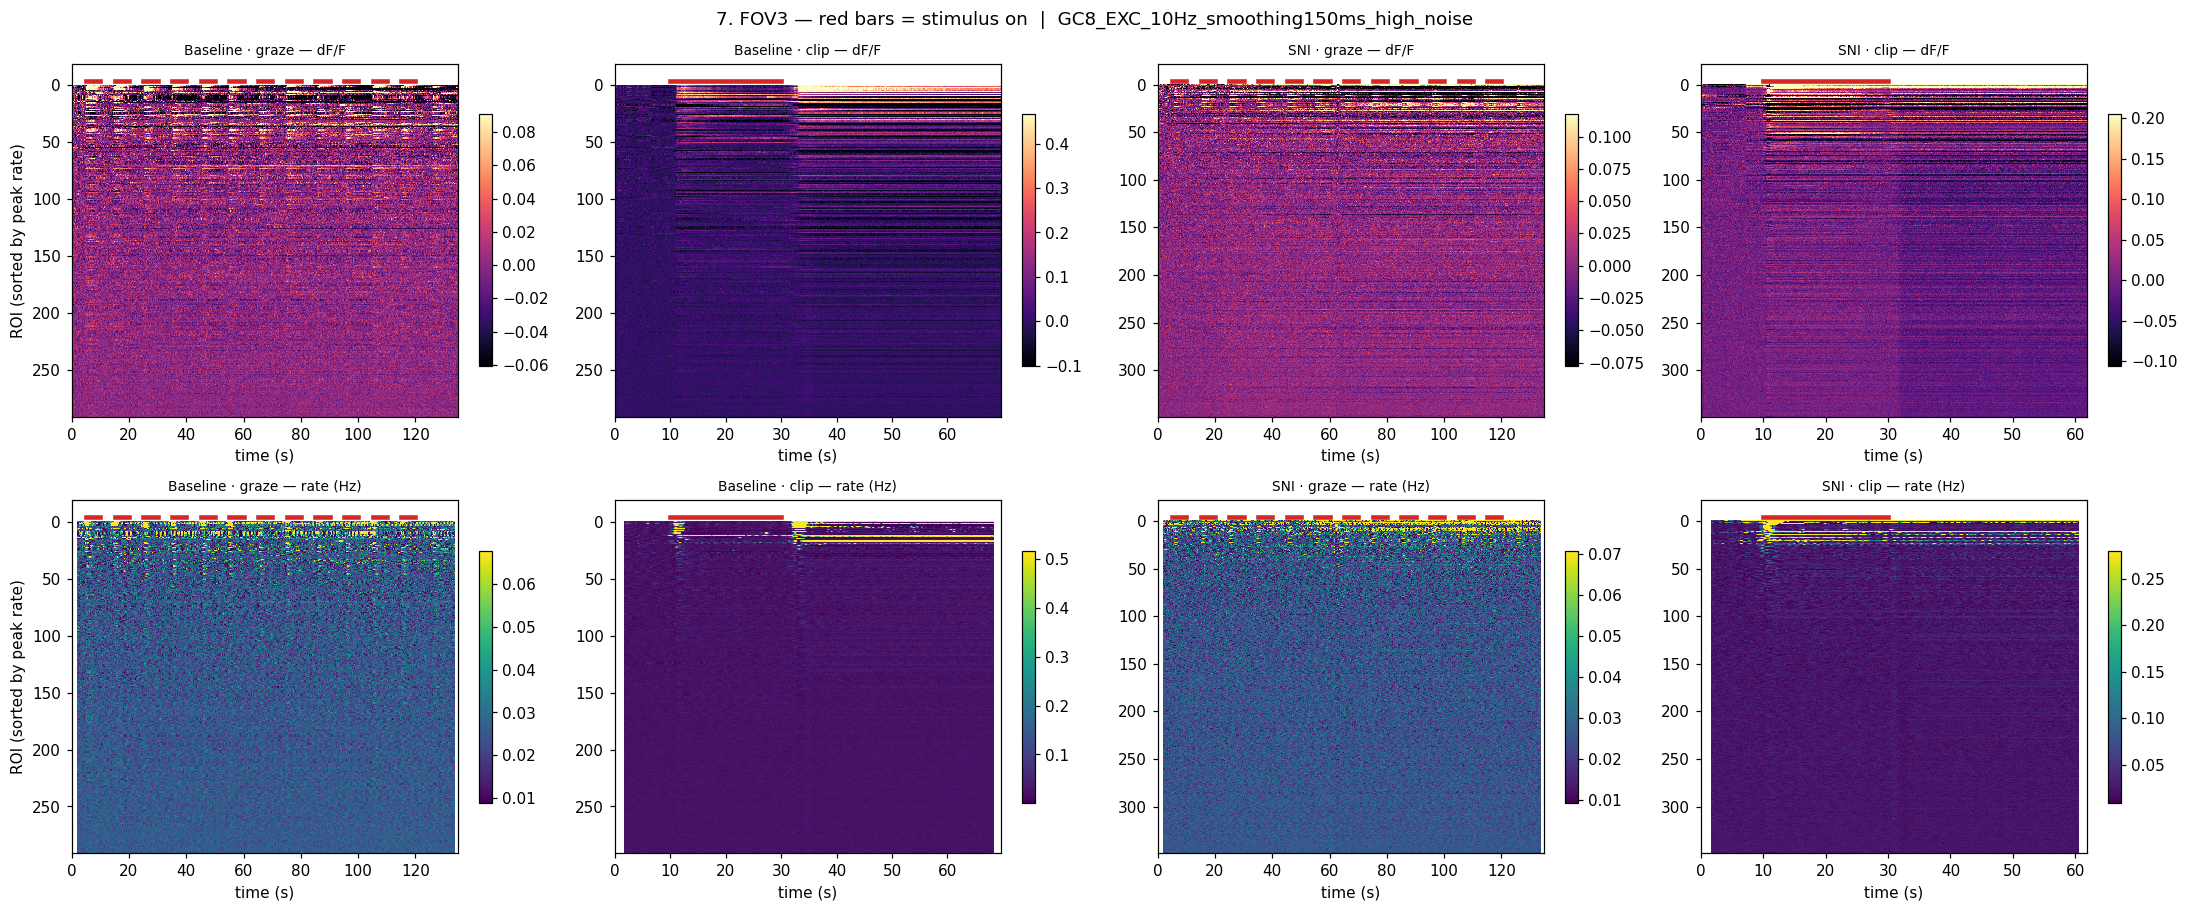

7 · Baseline graze: 291 ROIs x 1420 frames  |  dF/F [-0.37, 0.53]  |  rate mean 0.0298 Hz, max 17.02 Hz
7 · Baseline clip : 291 ROIs x 734 frames  |  dF/F [-0.89, 1.00]  |  rate mean 0.0442 Hz, max 20.72 Hz
7 · SNI      graze: 349 ROIs x 1420 frames  |  dF/F [-0.79, 0.89]  |  rate mean 0.0280 Hz, max 9.62 Hz
7 · SNI      clip : 349 ROIs x 652 frames  |  dF/F [-0.84, 1.23]  |  rate mean 0.0438 Hz, max 18.93 Hz


In [86]:
FOV0 = FOVS[0]
fig, axes = plt.subplots(2, len(EXPERIMENTS) * 2, squeeze=False,
                         figsize=(5.0 * len(EXPERIMENTS) * 2, 8.4))
for c, (cond, exp) in enumerate(itertools.product(CONDITIONS, EXPERIMENTS)):
    rec = runs[(cond, exp, FOV0)]
    t, dff, rate = rec["time_s"], rec["dff"], rec["rate"]
    order = np.argsort(-np.nanmax(rate, axis=0))       # most responsive cell at the top
    for r, (M, name, cmap) in enumerate(((dff, "dF/F", "magma"), (rate, "rate (Hz)", "viridis"))):
        ax = axes[r][c]
        lo, hi = np.nanpercentile(M, [2, 99])
        im = ax.imshow(M[:, order].T, aspect="auto", cmap=cmap, vmin=lo, vmax=hi,
                       extent=[t[0], t[-1], M.shape[1], 0])
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            ax.plot([x0, x1], [-4, -4], lw=3, color="tab:red", clip_on=False)
        ax.set_xlabel("time (s)")
        if c == 0:
            ax.set_ylabel("ROI (sorted by peak rate)")
        ax.set_title(f"{cond} · {exp} — {name}", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.03)
fig.suptitle(f"7. {FOV0} — red bars = stimulus on  |  {MODEL_DEFAULT}")
fig.tight_layout()
save_fig(fig, "7_trace_heatmaps")
plt.show()

for (cond, exp) in itertools.product(CONDITIONS, EXPERIMENTS):
    rec = runs[(cond, exp, FOV0)]
    print(f"7 · {cond:8s} {exp:5s}: {rec['dff'].shape[1]} ROIs x {rec['dff'].shape[0]} frames  |  "
          f"dF/F [{rec['dff'].min():.2f}, {rec['dff'].max():.2f}]  |  rate mean "
          f"{np.nanmean(rec['rate']):.4f} Hz, max {np.nanmax(rec['rate']):.2f} Hz")

## 8. Event detection — shared, with protocol-dependent segments

Per cell, per dataset:

1. `mu, sd` = mean and SD of the inferred rate over the **first segment only**. Using the whole
   trace would be circular — a strongly responding cell inflates its own SD and censors itself.
2. `thr = mu + DETECT_K * sd`, applied **one-sided**. The rate is non-negative and zero-inflated, so
   `mu - k*sd` is meaningless; this detects increases only and cannot see a cell going silent.
3. A crossing counts as an event only if it lasts `N_CONSEC` frames.
4. Sub-threshold bins are erased to **0** ("no activity"). CASCADE's edge bins stay **NaN**
   ("undefined"). The two never mix.

`detect_events` is **not protocol-aware and must stay that way.** The threshold always comes from
`edges[0]`–`edges[1]`, which is the pre-stimulus window under either segment model. That is what
keeps Baseline and SNI comparable; making it depend on the protocol would break the one thing both
parts of the analysis rest on.

### What does change: the segments

| protocol | segments | why |
|---|---|---|
| clip | 3 — `S1 \| S2 \| S3` | one 20 s application inside a ~70 s recording; before/during/after is the natural frame |
| graze | 26 — `S1 \| C1_on \| C1_gap \| … \| C12_gap \| S3` | 12 repeats filling 89 % of the recording; a single "during" block cannot attribute a response to a cycle |

Each segment carries a **kind** in `{pre, on, gap, post}` alongside its index, so everything
downstream selects by kind — `kind_of_t == "on"` — rather than by index arithmetic that would mean
different things in the two protocols.

> **The graze post-window is checked, not assumed.** It is whatever is left after the 12th cycle,
> and the cell below prints it. On this recording it is under 10 s, which is too short to separate
> a sustained response from the tail of the last graze. Where clip can speak about a *chronic*
> response, graze can only speak about activity in the **gap windows between cycles** — 5 s after
> each graze, not minutes after all of them. Those are different statements and the notebook words
> them differently.

In [87]:
SEG_KINDS = ("pre", "on", "gap", "post")


def segment_edges(experiment: str, t_end: float) -> np.ndarray:
    """Segment boundaries in seconds — protocol-dependent.

    clip  -> the configured three windows: before | clip applied | after withdrawal.
    graze -> S1, then an ON and a GAP window for every cycle, then whatever is left:
             2 + 2*GRAZE_N_TRIALS segments. A single "during" block would span 5–125 s of a
             135 s recording and could not attribute a response to a cycle.
    """
    if experiment == "graze":
        edges = [0.0, GRAZE_BASELINE_S]
        for i in range(GRAZE_N_TRIALS):
            s = GRAZE_BASELINE_S + i * GRAZE_CYCLE_S
            edges += [s + GRAZE_ON_S, s + GRAZE_CYCLE_S]
        return np.array(edges + [float(t_end)])
    return np.array([t_end if e is None else float(e) for e in SEGMENT_EDGES_S[experiment]])


def segment_kinds(experiment: str) -> np.ndarray:
    """What each segment IS, so downstream code selects by kind and never by index arithmetic."""
    if experiment == "graze":
        return np.array(["pre"] + ["on", "gap"] * GRAZE_N_TRIALS + ["post"])
    return np.array(["pre", "on", "post"])


def segment_names(experiment: str) -> np.ndarray:
    """Readable segment labels: S1 | C1_on | C1_gap | ... | S3."""
    if experiment == "graze":
        return np.array(["S1"] + [f"C{i + 1}_{k}" for i in range(GRAZE_N_TRIALS)
                                  for k in ("on", "gap")] + ["S3"])
    return np.array(["S1", "S2", "S3"])


def segment_of(t: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Segment index per timepoint; the final timepoint stays in the last segment."""
    return np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(edges) - 2)


def detect_events(rate: np.ndarray, t: np.ndarray, edges: np.ndarray,
                  k: float | None = None, n_consec: int | None = None) -> dict:
    """Threshold from the pre-stimulus segment, then keep runs of >= n_consec supra-threshold frames.

    The threshold is built from `edges[0]`–`edges[1]` and nowhere else, in BOTH protocols — that
    first segment is always the pre-stimulus window, which is what keeps Baseline and SNI
    comparable. This function is deliberately not protocol-aware.

    Returns the event mask and `detected`, which is the rate inside events, 0 outside, and NaN
    wherever CASCADE left the bin undefined.
    """
    k = DETECT_K if k is None else k
    n_consec = N_CONSEC if n_consec is None else n_consec
    baseline = (t >= edges[0]) & (t < edges[1])
    usable = int(np.isfinite(rate[baseline]).all(axis=1).sum())
    if usable < MIN_BASELINE_FRAMES:
        raise ValueError(f"only {usable} usable baseline frames (CASCADE pads the edges with NaN) — "
                         "mu/sd cannot be computed; move the first segment boundary")

    mu = np.nanmean(rate[baseline], axis=0)
    sd = np.nanstd(rate[baseline], axis=0)
    thr = mu + k * sd

    finite = np.isfinite(rate)
    active = finite & (rate > thr[None, :])         # NaN is undefined, so never active
    events = np.zeros_like(active)
    for j in range(active.shape[1]):                # keep only runs of >= n_consec frames
        col = active[:, j]
        if not col.any():
            continue
        edge = np.diff(np.concatenate(([0], col.view(np.int8), [0])))
        for lo, hi in zip(np.flatnonzero(edge == 1), np.flatnonzero(edge == -1)):
            if hi - lo >= n_consec:
                events[lo:hi, j] = True

    detected = np.where(events, rate, 0.0)          # erased = 0, "no activity"
    detected[~finite] = np.nan                      # undefined stays NaN
    return {"events": events, "detected": detected, "thr": thr, "mu": mu, "sd": sd,
            "baseline_frames": usable}


for (cond, exp, fov), rec in runs.items():
    rec["edges"] = segment_edges(exp, float(rec["time_s"][-1]))
    rec["seg_kind"] = segment_kinds(exp)
    rec["seg_name"] = segment_names(exp)
    rec["seg_of_t"] = segment_of(rec["time_s"], rec["edges"])
    rec["kind_of_t"] = rec["seg_kind"][rec["seg_of_t"]]
    if rec["seg_kind"][0] != "pre" or len(rec["seg_kind"]) != len(rec["edges"]) - 1:
        raise ValueError(f"{cond} {exp}: segment kinds do not line up with the edges")
    rec["det"] = detect_events(rec["rate"], rec["time_s"], rec["edges"])

print(f"detection: thr = baseline mean + {DETECT_K:g} SD, one-sided, >= {N_CONSEC} consecutive "
      "frames, built on the FIRST segment only in both protocols")
display(pd.DataFrame([
    {"condition": k[0], "experiment": k[1], "fov": k[2], "n_segments": len(v["seg_kind"]),
     "baseline_s": f"{v['edges'][0]:.0f}–{v['edges'][1]:.0f}",
     "baseline_frames_usable": v["det"]["baseline_frames"],
     "thr_median": round(float(np.median(v["det"]["thr"])), 4),
     "cells_with_events": int(v["det"]["events"].any(axis=0).sum()),
     "n_roi": v["rate"].shape[1]}
    for k, v in runs.items()]))

# The graze post-stimulus window is whatever is left after the 12th cycle — it is not a designed
# epoch, and on this recording it is short. Check it explicitly rather than let a "chronic"
# reading be made of it downstream.
for exp in PART_B:
    for cond in CONDITIONS:
        rec = runs[(cond, exp, FOVS[0])]
        post_s = float(rec["edges"][-1] - rec["edges"][-2])
        stim_frac = 100 * (rec["edges"][-2] - rec["edges"][1]) / rec["edges"][-1]
        print(f"\n{cond} {exp}: recording {rec['edges'][-1]:.1f} s  |  cycles cover "
              f"{rec['edges'][1]:.0f}–{rec['edges'][-2]:.0f} s ({stim_frac:.0f}% of it)  |  "
              f"post-stimulus window {post_s:.1f} s")
        if post_s < GRAZE_MIN_POST_S:
            print(f"  ! post window is under {GRAZE_MIN_POST_S:.0f} s — graze CANNOT support a "
                  "'chronic' or 'post-stimulus' claim. There is not enough recording after the\n"
                  "    last cycle to distinguish a sustained response from the tail of the last "
                  "one. Persistence for graze means activity in the GAP windows between cycles,\n"
                  "    which is a different statement (5 s after each graze, not minutes after "
                  "all of them) and must be worded differently wherever it is reported.")

detection: thr = baseline mean + 3 SD, one-sided, >= 3 consecutive frames, built on the FIRST segment only in both protocols


,condition,experiment,fov,n_segments,baseline_s,baseline_frames_usable,thr_median,cells_with_events,n_roi
0,Baseline,graze,FOV3,26,0–5,36,0.0397,122,291
1,Baseline,clip,FOV3,3,0–10,89,0.0408,132,291
2,SNI,graze,FOV3,26,0–5,36,0.0404,130,349
3,SNI,clip,FOV3,3,0–10,89,0.0425,101,349



Baseline graze: recording 134.9 s  |  cycles cover 5–125 s (89% of it)  |  post-stimulus window 9.9 s
  ! post window is under 10 s — graze CANNOT support a 'chronic' or 'post-stimulus' claim. There is not enough recording after the
    last cycle to distinguish a sustained response from the tail of the last one. Persistence for graze means activity in the GAP windows between cycles,
    which is a different statement (5 s after each graze, not minutes after all of them) and must be worded differently wherever it is reported.

SNI graze: recording 134.9 s  |  cycles cover 5–125 s (89% of it)  |  post-stimulus window 9.9 s
  ! post window is under 10 s — graze CANNOT support a 'chronic' or 'post-stimulus' claim. There is not enough recording after the
    last cycle to distinguish a sustained response from the tail of the last one. Persistence for graze means activity in the GAP windows between cycles,
    which is a different statement (5 s after each graze, not minutes after all of t

### 8a. Two checks before the counts mean anything

**Is the baseline window inside CASCADE's padding?** The model leaves 17 frames of `NaN` at each
end. The graze pre-stimulus window is 0–5 s = 53 frames, so a third of it is padding and `mu/sd`
come from the ~36 frames that survive; the clip window (0–10 s) keeps ~89. `detect_events` refuses
to run on fewer than `MIN_BASELINE_FRAMES`.

**Are the two baselines comparable?** The after-SNI baseline window is itself post-injury
spontaneous activity. If SNI raised resting activity, the after-threshold would sit on an already
elevated baseline, the same response would be less likely to clear it, and cells would appear to
*lose* responses for purely arithmetic reasons. The table below is that check.

In [88]:
base = pd.DataFrame([
    {"condition": k[0], "experiment": k[1], "fov": k[2],
     "baseline_frames": v["det"]["baseline_frames"],
     "mu_median": round(float(np.median(v["det"]["mu"])), 4),
     "sd_median": round(float(np.median(v["det"]["sd"])), 4),
     "thr_median": round(float(np.median(v["det"]["thr"])), 4)}
    for k, v in runs.items()])
display(base)

for exp in EXPERIMENTS:
    a = base[(base.condition == "Baseline") & (base.experiment == exp)].iloc[0]
    b = base[(base.condition == "SNI") & (base.experiment == exp)].iloc[0]
    shift = 100 * (b.thr_median - a.thr_median) / max(a.thr_median, 1e-12)
    verdict = ("comparable — the directional artefact does not apply here" if abs(shift) < 10
               else "NOT comparable — the after-threshold is shifted, read §11 as a lower bound")
    print(f"{exp}: baseline mu {a.mu_median:.4f} -> {b.mu_median:.4f} Hz  |  threshold "
          f"{a.thr_median:.4f} -> {b.thr_median:.4f} Hz ({shift:+.1f}%)  |  {verdict}")

,condition,experiment,fov,baseline_frames,mu_median,sd_median,thr_median
0,Baseline,graze,FOV3,36,0.0252,0.0051,0.0397
1,Baseline,clip,FOV3,89,0.0252,0.0052,0.0408
2,SNI,graze,FOV3,36,0.0253,0.0051,0.0404
3,SNI,clip,FOV3,89,0.0254,0.0059,0.0425


graze: baseline mu 0.0252 -> 0.0253 Hz  |  threshold 0.0397 -> 0.0404 Hz (+1.8%)  |  comparable — the directional artefact does not apply here
clip: baseline mu 0.0252 -> 0.0254 Hz  |  threshold 0.0408 -> 0.0425 Hz (+4.2%)  |  comparable — the directional artefact does not apply here


### 8b. Calibrating detection against an empirical null — constrained for graze

The null rotates each cell's own trace and re-runs detection: if a surrogate scores as often as
the real trace, the detection is at chance. Only the **finite** samples are rotated, so CASCADE's
edge padding stays where it is rather than being dragged into the baseline window.

**Why graze needs a constrained shift.** With a 10 s cycle, an offset of about *k* whole cycles
lands the response back on top of a *different* graze. The surrogate is then still stimulus-locked,
scores as high as the real trace, and the null swallows exactly the effect it exists to measure.
Offsets within `CYCLE_EXCLUSION_FRAMES` of any multiple of the cycle period are therefore illegal
for graze. clip has one application and no such structure, so its shift is unconstrained.

The constraint is not free: it removes about half the possible offsets, and the pool that remains
caps how many surrogates can be drawn before the "null" is just a few rotations resampled.
`SHIFT_POOL_FACTOR` is that guard, and the cell prints the arithmetic.

> **The guard is hard only where it is actionable.** For graze the pool is set by
> `CYCLE_EXCLUSION_FRAMES` and the surrogate count, both of which can be changed, so a shortfall
> raises. For the unconstrained shift the pool *is* the number of valid frames — no parameter
> enlarges it — so a shortfall warns and continues. clip does fall short of the 10× target at 200
> surrogates; this is a property of a 70 s recording, and the practical consequence is only that
> p is resolution-limited, which it already is at 1/201.

Counts are aggregated **by segment kind** rather than per segment: graze has 26 segments and a
per-segment table would be unreadable, while "any ON window" is the quantity these counts are
about.

shift-offset pools — the graze constraint costs offsets and buys power:


,experiment,valid_frames,cycle_frames,exclusion_frames,legal_offsets,surrogates_used,max_at_10x,pool/surrogates,guard
0,graze,1387,105.0,26.0,676,60,67,11.3,hard (graze)
1,clip,701,NaN,NaN,700,200,70,3.5,warn (pool = recording)


graze: excluding ±26 frames around every whole cycle of 105 is what caps the surrogate count at 67. Fewer surrogates costs p-resolution (best p = 1/61 = 0.016); the constraint buys back more than it costs — the before/after table in §12B is the receipt.


,condition,experiment,kind,windows,seconds,n_roi,real,null,excess
0,Baseline,graze,pre,1,5.0,291,2,0.0,2.0
1,Baseline,graze,on,12,60.0,291,97,89.8,7.2
2,Baseline,graze,gap,12,60.0,291,74,90.2,-16.2
3,Baseline,graze,post,1,9.9,291,25,34.0,-9.0
4,Baseline,clip,pre,1,10.0,291,8,11.0,-3.0
5,Baseline,clip,on,1,20.0,291,87,42.8,44.2
6,Baseline,clip,post,1,39.7,291,106,79.6,26.4
7,SNI,graze,pre,1,5.0,349,0,0.6,-0.6
8,SNI,graze,on,12,60.0,349,94,84.4,9.6
9,SNI,graze,gap,12,60.0,349,92,82.0,10.0


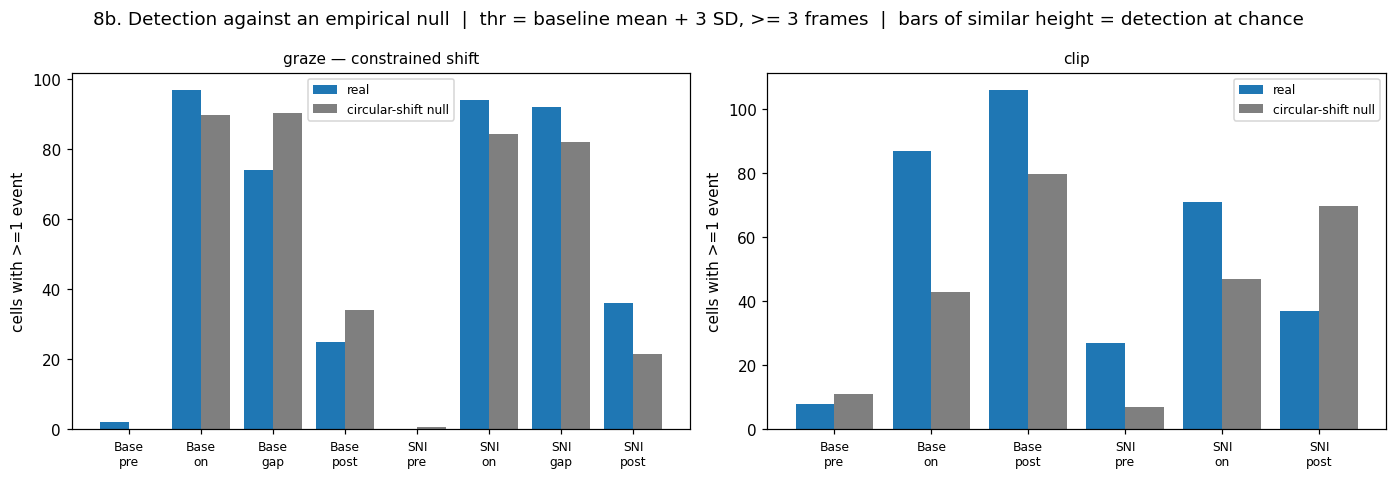

! at or near chance (excess < 5% of cells) — these are not interpretable as responses:
    Baseline graze on  : real 97, null 89.8, excess +7.2 of 291 cells
    Baseline graze gap : real 74, null 90.2, excess -16.2 of 291 cells
    Baseline graze post: real 25, null 34.0, excess -9.0 of 291 cells
    SNI      graze on  : real 94, null 84.4, excess +9.6 of 349 cells
    SNI      graze gap : real 92, null 82.0, excess +10.0 of 349 cells
    SNI      graze post: real 36, null 21.4, excess +14.6 of 349 cells
    SNI      clip  post: real 37, null 69.6, excess -32.6 of 349 cells

If a later window comes back empty, the small-and-sustained phenotype may have been erased by a height-based rule. Lower DETECT_K to 2, or raise N_CONSEC to trade height for duration.


In [89]:
def cycle_period_frames(dt: float) -> int:
    """The graze cycle expressed in frames."""
    return max(int(round(GRAZE_CYCLE_S / dt)), 1)


def exclusion_frames(dt: float) -> int:
    """How close to a whole cycle an offset may not come. Default: half the ON window."""
    return (int(round(GRAZE_ON_S / 2 / dt)) if CYCLE_EXCLUSION_FRAMES is None
            else int(CYCLE_EXCLUSION_FRAMES))


def shift_offsets(n_valid: int, dt: float, experiment: str) -> np.ndarray:
    """Legal rotation offsets, in frames, for one cell's finite samples.

    clip  -> any offset; one application in a long recording, so a rotation genuinely moves the
             response off the stimulus.
    graze -> only offsets whose distance to EVERY multiple of the cycle period exceeds the
             exclusion. A shift of about k whole cycles lands the response back on top of a
             different cycle: the surrogate stays stimulus-locked, scores as high as the real
             trace, and the null swallows the effect it is supposed to measure.
    """
    offs = np.arange(1, max(n_valid, 2))
    if experiment != "graze":
        return offs
    period = cycle_period_frames(dt)
    to_nearest = np.minimum(offs % period, period - offs % period)
    return offs[to_nearest > exclusion_frames(dt)]


def checked_offsets(rec: dict, experiment: str, n_surrogates: int, tag: str = "",
                    strict: bool | None = None) -> np.ndarray:
    """`shift_offsets` plus the pool-size guard.

    A pool barely larger than the surrogate count means the "null" is a handful of rotations
    resampled, and its percentiles mean less than the surrogate count implies.

    The guard is HARD only where it is actionable — the graze constraint, where the pool is set
    by CYCLE_EXCLUSION_FRAMES and the surrogate count, both of which can be changed. For the
    unconstrained shift the pool IS the number of valid frames, so no parameter enlarges it and
    raising would only block the analysis; there it warns and continues.
    """
    strict = (experiment in PART_B) if strict is None else strict
    finite = np.isfinite(rec["rate"])
    n_valid = int(finite.sum(axis=0).min())
    dt = float(np.median(np.diff(rec["time_s"])))
    pool = shift_offsets(n_valid, dt, experiment)
    need = SHIFT_POOL_FACTOR * n_surrogates
    if len(pool) >= need:
        return pool
    msg = (f"{tag}{experiment}: {len(pool)} legal shift offsets for {n_surrogates} surrogates, "
           f"below the {SHIFT_POOL_FACTOR}x target of {need} "
           f"(max at this pool = {len(pool) // SHIFT_POOL_FACTOR})")
    if strict:
        raise ValueError(msg + f". Lower the surrogate count, or lower CYCLE_EXCLUSION_FRAMES "
                               f"(now {exclusion_frames(dt)} frames of a "
                               f"{cycle_period_frames(dt)}-frame cycle).")
    print(f"  ! {msg}. The pool is the recording length itself, so no parameter enlarges it — "
          f"the null is resampled from {len(pool)} rotations and p is resolution-limited at "
          f"1/{n_surrogates + 1:.0f} regardless. Not raised: this is a property of the recording.")
    return pool


def circular_shift(rate: np.ndarray, rng, offsets: np.ndarray | None = None) -> np.ndarray:
    """Rotate each cell's *finite* samples by a random offset, leaving NaN bins where they are.

    Rolling the raw array would drag CASCADE's edge padding into the baseline window and leave
    nothing to build a threshold from. The padding is a property of the recording, not of the cell.
    `offsets` restricts which rotations are legal; None means any, the unconstrained shift.
    """
    out = np.full_like(rate, np.nan)
    for j in range(rate.shape[1]):
        finite = np.isfinite(rate[:, j])
        values = rate[finite, j]
        k = (rng.integers(values.size) if offsets is None
             else int(offsets[rng.integers(len(offsets))]))
        out[finite, j] = np.roll(values, k % max(values.size, 1))
    return out


print("shift-offset pools — the graze constraint costs offsets and buys power:")
pool_rows = []
for exp in EXPERIMENTS:
    rec = runs[("Baseline", exp, FOVS[0])]
    dt = float(np.median(np.diff(rec["time_s"])))
    n_valid = int(np.isfinite(rec["rate"]).sum(axis=0).min())
    n_sur = SPECTRUM_N_SURROGATES_GRAZE if exp in PART_B else SPECTRUM_N_SURROGATES
    pool = shift_offsets(n_valid, dt, exp)
    pool_rows.append({"experiment": exp, "valid_frames": n_valid,
                      "cycle_frames": cycle_period_frames(dt) if exp == "graze" else None,
                      "exclusion_frames": exclusion_frames(dt) if exp == "graze" else None,
                      "legal_offsets": len(pool), "surrogates_used": n_sur,
                      f"max_at_{SHIFT_POOL_FACTOR}x": len(pool) // SHIFT_POOL_FACTOR,
                      "pool/surrogates": round(len(pool) / n_sur, 1),
                      "guard": ("hard (graze)" if exp in PART_B else "warn (pool = recording)")})
display(pd.DataFrame(pool_rows))
for r in pool_rows:
    if r["experiment"] in PART_B:
        print(f"graze: excluding ±{r['exclusion_frames']} frames around every whole cycle of "
              f"{r['cycle_frames']} is what caps the surrogate count at "
              f"{r[f'max_at_{SHIFT_POOL_FACTOR}x']}. Fewer surrogates costs p-resolution "
              f"(best p = 1/{SPECTRUM_N_SURROGATES_GRAZE + 1} = "
              f"{1 / (SPECTRUM_N_SURROGATES_GRAZE + 1):.3f}); the constraint buys back more than "
              "it costs — the before/after table in §12B is the receipt.")


def null_counts(rec: dict, experiment: str, n_shifts: int | None = None, seed: int = 0):
    """Cells flagged per segment KIND after circular-shifting each cell — the surrogate null.

    Aggregated by kind rather than by segment: graze has 26 segments and a per-segment table
    would be unreadable, while "any ON window" is the quantity the counts are about.
    """
    n_shifts = NULL_SHIFTS if n_shifts is None else n_shifts
    rng = np.random.default_rng(seed)
    offsets = checked_offsets(rec, experiment, n_shifts, tag="§8b ")
    rate, t, edges, kind = rec["rate"], rec["time_s"], rec["edges"], rec["kind_of_t"]
    kinds = [k for k in SEG_KINDS if (kind == k).any()]
    out = []
    for _ in range(n_shifts):
        ev = detect_events(circular_shift(rate, rng, offsets), t, edges)["events"]
        out.append([int(ev[kind == k].any(axis=0).sum()) for k in kinds])
    return kinds, np.mean(out, axis=0)


rows = []
for (cond, exp, fov), rec in runs.items():
    kind = rec["kind_of_t"]
    ev = rec["det"]["events"]
    kinds, null = null_counts(rec, exp)
    for i, k in enumerate(kinds):
        real = int(ev[kind == k].any(axis=0).sum())
        rows.append({"condition": cond, "experiment": exp, "kind": k,
                     "windows": int((rec["seg_kind"] == k).sum()),
                     "seconds": round(float(np.sum(np.diff(rec["edges"])[rec["seg_kind"] == k])), 1),
                     "n_roi": rec["rate"].shape[1], "real": real,
                     "null": round(float(null[i]), 1),
                     "excess": round(float(real - null[i]), 1)})
calibration = pd.DataFrame(rows)
display(calibration)

fig, axes = plt.subplots(1, len(EXPERIMENTS), squeeze=False, figsize=(6.4 * len(EXPERIMENTS), 4.4))
for c, exp in enumerate(EXPERIMENTS):
    ax = axes[0][c]
    sub = calibration[calibration.experiment == exp].reset_index(drop=True)
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub["real"], 0.4, label="real", color="tab:blue")
    ax.bar(x + 0.2, sub["null"], 0.4, label="circular-shift null", color="tab:grey")
    ax.set_xticks(x, [f"{r.condition[:4]}\n{r.kind}" for r in sub.itertuples()], fontsize=8)
    ax.set_ylabel("cells with >=1 event")
    ax.set_title(f"{exp}" + (" — constrained shift" if exp in PART_B else ""), fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle(f"8b. Detection against an empirical null  |  thr = baseline mean + {DETECT_K:g} SD, "
             f">= {N_CONSEC} frames  |  bars of similar height = detection at chance")
fig.tight_layout()
save_fig(fig, "8b_calibration")
plt.show()

weak = calibration[(calibration.kind != "pre")
                   & (calibration.excess < 0.05 * calibration.n_roi)]
if len(weak):
    print("! at or near chance (excess < 5% of cells) — these are not interpretable as responses:")
    for r in weak.itertuples():
        print(f"    {r.condition:8s} {r.experiment:5s} {r.kind:4s}: real {r.real}, null {r.null}, "
              f"excess {r.excess:+.1f} of {r.n_roi} cells")
print("\nIf a later window comes back empty, the small-and-sustained phenotype may have been "
      "erased by a height-based rule. Lower DETECT_K to 2, or raise N_CONSEC to trade height "
      "for duration.")

### 8c. Shared per-ROI amplitude and shape

Three things mean the same under either segment model, so they are computed once here and used by
both parts rather than twice with a chance of drifting apart:

- **`amplitude_totals`** — `auc_total`, `peak_total`, `n_event_frames` in the original scale, plus
  `sharpness_total` and `peak_time_frac`. Amplitude is deliberately **not** normalised per cell:
  dividing each cell by its own total would divide out exactly the biology in question, since a
  cell whose response grew 10× would look unchanged.
- **`sharpness`** — `peak / mean-height-while-active`. AUC collapses amplitude × duration into one
  number, so a sharp transient and a low sustained plateau can share an AUC; this ratio separates
  them and is dimensionless, which is what makes it orthogonal to the amplitude axes. Undefined
  (`NaN`) where a cell has no events — never 0, never 1.
- **`event_onsets`** — one time per detected **event**, not per supra-threshold frame. Frames
  inside one event are serially correlated, and counting each of them would inflate the *n* of the
  circular statistics in §9B.

> **Limitation carried forward.** Acquisition is ~10.5 Hz and the model applies a 150 ms smoothing
> kernel, so "sharp" has a physical floor here. Sharpness separates a few-hundred-ms transient from
> a tens-of-seconds plateau; it must not be used to claim sub-100 ms timing differences.

In [90]:
COND_COLOR = {"Baseline": "tab:blue", "SNI": "tab:orange"}   # one convention for both parts


def sharpness(peak: np.ndarray, auc: np.ndarray, n_frames: np.ndarray, dt: float) -> np.ndarray:
    """peak / mean-height-while-active. NaN where the cell has no events — never 0, never 1.

    AUC collapses amplitude x duration into one number, so a sharp transient and a low sustained
    plateau can share an AUC. This ratio separates them and is dimensionless: scaling a whole
    trace by 10 leaves it unchanged, which is what makes it orthogonal to the amplitude axes.
      duration      = n_frames * dt        time spent inside events
      mean_in_event = auc / duration       average height while active
      sharpness     = peak / mean_in_event = peak * duration / auc
    Small known bias: np.trapezoid weights an n-frame event by ~(n-1)*dt while n*dt is used here,
    so a perfect rectangle lands above 1 by about n/(n-1). Negligible at N_CONSEC >= 3 and
    deliberately left uncorrected.
    """
    return np.divide(peak * (n_frames * dt), auc,
                     out=np.full(len(np.atleast_1d(auc)), np.nan, dtype=float),
                     where=(n_frames > 0) & (auc > 0))


def amplitude_totals(rec: dict) -> dict:
    """Whole-recording amplitude and shape per ROI, in the ORIGINAL scale.

    Shared by §9A and §9B: these columns mean the same thing under either segment model, so they
    are computed once here rather than twice with a chance of drifting apart.
    """
    t = rec["time_s"]
    ev, det = rec["det"]["events"], rec["det"]["detected"]
    dt = float(np.median(np.diff(t)))
    d_all = np.nan_to_num(det, nan=0.0)             # undefined bins contribute nothing

    out = {"roi_id": rec["roi_ids"],
           "auc_total": np.trapezoid(d_all, t, axis=0),
           "peak_total": d_all.max(axis=0),
           "n_event_frames": ev.sum(axis=0)}
    out["sharpness_total"] = sharpness(out["peak_total"], out["auc_total"],
                                       out["n_event_frames"], dt)
    out["mean_in_event_total"] = np.divide(
        out["auc_total"], out["n_event_frames"] * dt,
        out=np.full(det.shape[1], np.nan, dtype=float), where=out["n_event_frames"] > 0)

    has = ev.any(axis=0)
    peak_i = np.argmax(d_all, axis=0)
    out["peak_time_frac"] = np.where(has, (t[peak_i] - t[0]) / (t[-1] - t[0]), np.nan)
    return out


def event_onsets(events: np.ndarray, t: np.ndarray) -> list[np.ndarray]:
    """Onset time of each detected event, per cell.

    One sample per EVENT, not per supra-threshold frame: frames inside one event are serially
    correlated, and counting each of them would inflate the n of any circular statistic.
    """
    out = []
    for j in range(events.shape[1]):
        col = events[:, j]
        edge = np.diff(np.concatenate(([0], col.view(np.int8), [0])))
        out.append(t[np.flatnonzero(edge == 1)])
    return out


def window_auc(rec: dict, mask: np.ndarray) -> np.ndarray:
    """Detected AUC inside one time mask, per ROI, original scale."""
    t = rec["time_s"][mask]
    d = np.nan_to_num(rec["det"]["detected"][mask], nan=0.0)
    return np.trapezoid(d, t, axis=0) if mask.sum() > 1 else np.zeros(d.shape[1])


for key, rec in runs.items():
    rec["totals"] = amplitude_totals(rec)

print("shared per-ROI amplitude and shape computed for all "
      f"{len(runs)} recordings — used by §9A (clip) and §9B (graze) alike")
display(pd.DataFrame([
    {"condition": k[0], "experiment": k[1],
     "cells_with_events": int((v["totals"]["n_event_frames"] > 0).sum()),
     "auc_total_median": round(float(np.median(
         v["totals"]["auc_total"][v["totals"]["n_event_frames"] > 0])), 4),
     "sharpness_median": round(float(np.nanmedian(v["totals"]["sharpness_total"])), 2)}
    for k, v in runs.items()]))

shared per-ROI amplitude and shape computed for all 4 recordings — used by §9A (clip) and §9B (graze) alike


,condition,experiment,cells_with_events,auc_total_median,sharpness_median
0,Baseline,graze,122,0.0430,1.14
1,Baseline,clip,132,0.1011,1.24
2,SNI,graze,130,0.0323,1.14
3,SNI,clip,101,0.0494,1.17


# The analysis forks here: Part A = clip, Part B = graze

Everything above is shared — loading, re-zeroing, detection, the threshold, the null machinery.
Everything below routes on `experiment`, and no function is written twice.

The two protocols are not the same experiment with different words, and forcing them through one
segment model costs both of them:

| | clip | graze |
|---|---|---|
| stimulus | one 20 s application | 12 × (5 s on, 5 s gap) |
| stimulus share of recording | 20 s of ~70 s | 120 s of 135 s |
| after-stimulus window | ~32–40 s | **9.9 s** |
| natural label | 3 bits, `S1 S2 S3` | per-cycle: when it started, how phasic it is |
| what a "chronic" claim can mean | activity after withdrawal | **nothing** — see §8 |

A 3-bit label applied to graze puts 89 % of the recording inside one `S2` bit, which is why the
graze `S2` column carried almost no information: nearly every responding cell is `010`, and a
circular shift leaves the response inside `S2` almost regardless of offset.

| § | Part A — clip | Part B — graze |
|---|---|---|
| 9 | `9A` 3-bit segment labels + per-segment amplitude | `9B` per-cycle table + 5-way phenotype label |
| 10 | `10A` PCA/k-means on amplitude × segment timing | `10B` PCA/k-means on amplitude × per-cycle timing |
| 11 | `11A` transitions over 8 bit-string labels | `11B` transitions over 5 phenotype labels |
| 12 | `12A` spectrum (+ `12Ab`, `12Ac` row filters) | `12B` spectrum with per-cycle bands, constrained-shift weight |

§12d onwards is shared again: the row→ROI map covers both spectra, §13 tests the graze cycle trend,
§14 is clip-only phenotype accounting, and §15 measures co-activation in both.

## 9A. Output 1 (clip) — rule-based segment labels

**Part A. clip only.**

`r[s] = any detected event in segment s`, one bit per segment, so three segments give 8 possible
labels. The label is what makes the two days comparable; the amplitude is **not** discarded —
per-segment AUC and peak of the detected events ride alongside in the original scale, and the
whole-recording amplitude and shape columns come from the shared §8c helper.

Each segment also carries `sharpness` (§8c): `≈ 1` is a flat sustained pulse, `≫ 1` is one dominant
spike inside a longer window. It is a ratio, so it is dimensionless and invariant to amplitude —
that is what makes it orthogonal to the amplitude axes. Where a cell has no events in a segment the
sharpness is **undefined and stored as `NaN`** — never 0, never 1.

> Why this is Part A only: applied to graze's 26 segments this rule yields a 26-bit string with
> 2²⁶ possible values, which is not a label but a serial number. §9B replaces it with a per-cycle
> summary and a 5-way phenotype.

In [91]:
def label_and_amplitude(rec: dict) -> pd.DataFrame:
    """A bit per segment, plus original-scale AUC and peak of the detected events per segment.

    Part A only: this is the 3-segment model, which fits clip (one 20 s application inside a
    ~70 s recording) and would give graze a 26-bit label. The whole-recording amplitude and
    shape columns come from the shared §8c helper, so §9A and §9B cannot drift apart on them.
    """
    t, seg = rec["time_s"], rec["seg_of_t"]
    ev, det = rec["det"]["events"], rec["det"]["detected"]
    n_seg, n_roi = len(rec["edges"]) - 1, det.shape[1]
    dt = float(np.median(np.diff(t)))

    bits, out = [], dict(rec["totals"])                 # roi_id + the shared total columns
    for s in range(n_seg):
        m = seg == s
        d = np.nan_to_num(det[m], nan=0.0)              # undefined bins contribute nothing
        bits.append(ev[m].any(axis=0))
        out[f"auc_S{s + 1}"] = np.trapezoid(d, t[m], axis=0)
        out[f"peak_S{s + 1}"] = d.max(axis=0)
        out[f"n_event_frames_S{s + 1}"] = ev[m].sum(axis=0)
        out[f"sharpness_S{s + 1}"] = sharpness(out[f"peak_S{s + 1}"], out[f"auc_S{s + 1}"],
                                               out[f"n_event_frames_S{s + 1}"], dt)
    out["label"] = np.array(["".join("1" if b[j] else "0" for b in bits) for j in range(n_roi)])

    # Timing axis: which segment holds the largest detected event.
    has = ev.any(axis=0)
    peak_i = np.argmax(np.nan_to_num(det, nan=0.0), axis=0)
    out["peak_segment"] = np.where(has, seg[peak_i], -1)
    return pd.DataFrame(out)


for exp in PART_A:
    for cond in CONDITIONS:
        for fov in FOVS:
            runs[(cond, exp, fov)]["table"] = label_and_amplitude(runs[(cond, exp, fov)])

LABELS_8 = ["".join(b) for b in itertools.product("01", repeat=3)]
label_colors = {lab: plt.cm.tab10(i % 10) for i, lab in enumerate(LABELS_8)}
print("Part A (clip) bits are (S1 before, S2 during, S3 after)  |  010 = responds during the "
      "clip then stops  ·  001 = quiet during, chronic afterwards")
display(pd.DataFrame([
    {"condition": cond, "experiment": exp, "fov": fov,
     **{lab: int((runs[(cond, exp, fov)]["table"].label == lab).sum()) for lab in LABELS_8}}
    for exp in PART_A for cond in CONDITIONS for fov in FOVS]))

print("Original-scale amplitude of the detected events — median over cells that have any:")
display(pd.DataFrame([
    {"condition": cond, "experiment": exp,
     **{f"auc_S{s}": round(float(tb.loc[tb.label != "000", f"auc_S{s}"].median()), 4)
        for s in (1, 2, 3)},
     **{f"peak_S{s}": round(float(tb.loc[tb.label != "000", f"peak_S{s}"].median()), 3)
        for s in (1, 2, 3)}}
    for exp in PART_A for cond in CONDITIONS
    for tb in [runs[(cond, exp, FOVS[0])]["table"]]]))

Part A (clip) bits are (S1 before, S2 during, S3 after)  |  010 = responds during the clip then stops  ·  001 = quiet during, chronic afterwards


,condition,experiment,fov,000,001,010,011,100,101,110,111
0,Baseline,clip,FOV3,159,44,24,56,1,0,1,6
1,SNI,clip,FOV3,248,21,40,13,9,0,15,3


Original-scale amplitude of the detected events — median over cells that have any:


,condition,experiment,auc_S1,auc_S2,auc_S3,peak_S1,peak_S2,peak_S3
0,Baseline,clip,0.0,0.0217,0.0472,0.0,0.048,0.057
1,SNI,clip,0.0,0.0231,0.0000,0.0,0.061,0.000


### 9Ab. Is the shape axis doing any work?

`auc_S2` against `sharpness_S2`, both on log axes, coloured by label. If the two phenotypes are
really there, `010` and `001` should sit at different heights even where they overlap in AUC. If it
is one blob, sharpness separates nothing on this dataset — worth knowing *before* it goes into the
clustering.

Only cells with events **in S2** can appear: sharpness is undefined elsewhere, so a cell whose only
events fall in S3 is absent from this panel by construction.

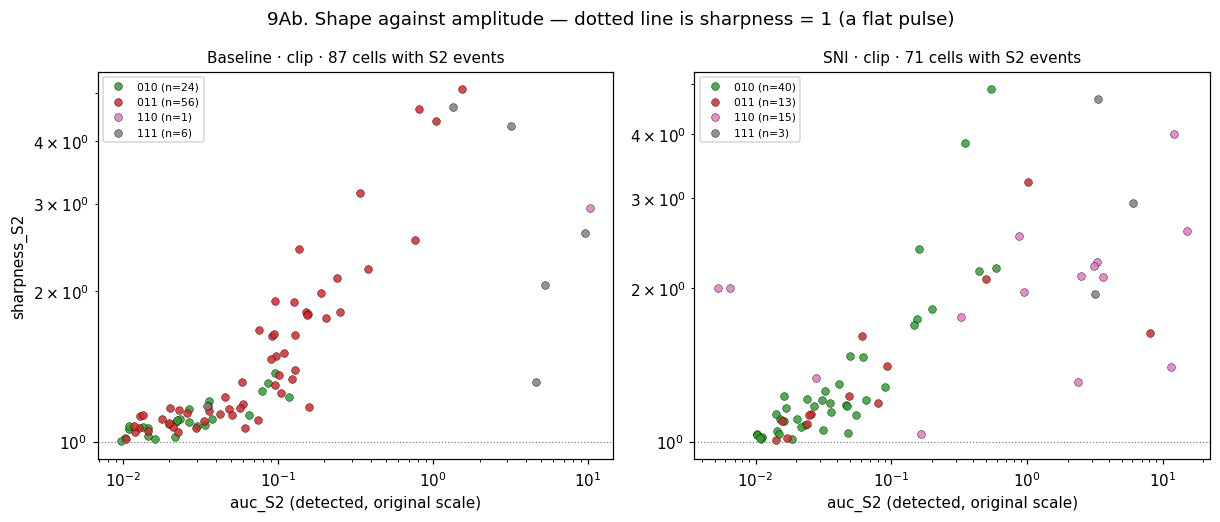

,condition,experiment,label,n,median_sharpness_S2,median_auc_S2
0,Baseline,clip,010,24,1.09,0.0230
1,SNI,clip,010,40,1.17,0.0320
2,Baseline,clip,011,56,1.27,0.0834
3,SNI,clip,011,13,1.19,0.0488
4,Baseline,clip,110,1,2.93,10.3135
5,SNI,clip,110,15,2.00,2.3640
6,Baseline,clip,111,6,2.34,3.9023
7,SNI,clip,111,3,2.93,3.3462


In [92]:
fig, axes = plt.subplots(max(len(PART_A), 1), len(CONDITIONS), squeeze=False,
                         figsize=(5.6 * len(CONDITIONS), 4.8 * max(len(PART_A), 1)))
rows = []
for r, exp in enumerate(PART_A):
    for c, cond in enumerate(CONDITIONS):
        ax = axes[r][c]
        tb = runs[(cond, exp, FOV0)]["table"]
        shown = (tb.label != "000") & np.isfinite(tb.sharpness_S2) & (tb.auc_S2 > 0)
        for lab in sorted(tb.loc[shown, "label"].unique()):
            sel = shown & (tb.label == lab)
            ax.scatter(tb.loc[sel, "auc_S2"], tb.loc[sel, "sharpness_S2"], s=26,
                       color=label_colors.get(lab, "grey"), edgecolor="k", linewidth=0.3,
                       alpha=0.85, label=f"{lab} (n={int(sel.sum())})")
            rows.append({"condition": cond, "experiment": exp, "label": lab, "n": int(sel.sum()),
                         "median_sharpness_S2": round(float(tb.loc[sel, "sharpness_S2"].median()), 2),
                         "median_auc_S2": round(float(tb.loc[sel, "auc_S2"].median()), 4)})
        ax.axhline(1.0, color="grey", lw=0.8, ls=":")          # sharpness = 1 is a flat pulse
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("auc_S2 (detected, original scale)")
        ax.set_ylabel("sharpness_S2" if c == 0 else "")
        ax.set_title(f"{cond} · {exp} · {int(shown.sum())} cells with S2 events", fontsize=10)
        ax.legend(fontsize=7)
fig.suptitle("9Ab. Shape against amplitude — dotted line is sharpness = 1 (a flat pulse)")
fig.tight_layout()
save_fig(fig, "9Ab_sharpness")
plt.show()
display(pd.DataFrame(rows).sort_values(["experiment", "label", "condition"], ignore_index=True))

## 10A. Output 2 (clip) — PCA + clustering on amplitude × timing

Amplitude-only features (mean, max, AUC of detected events) are collinear, so erasing sub-threshold
signal trims the origin end of the cloud but leaves the fan and the volcano returns unchanged. The
feature set therefore carries both kinds of axis:

- **amplitude**, original scale — `auc_total`, `peak_total`, `n_event_frames`
- **timing and shape** — `peak_time_frac` (when the largest event happens), `peak_segment` (which
  segment holds it), and `sharpness_total` (§9: transient versus plateau, amplitude-invariant)

`sharpness_**total**` is used rather than `sharpness_S2` deliberately. The `keep` mask here is
`label != "000"` — cells with an event *somewhere* — and `sharpness_S2` is `NaN` for a cell whose
only events fall outside the stimulus segment. Using it would drop the `001` chronic responders from
the clustering, which is the group the analysis exists to find. Any remaining non-finite value is a
hard error rather than something to impute.

Sharpness is right-skewed and bounded below near 1 while the amplitude axes are roughly
log-distributed, so the fit is done both raw and as `log10`, and whichever leaves PC2 a genuine
mixture — smaller largest-|loading| — is the one used. The printed loadings say which.

PCA and k-means are fitted **once on the pooled Baseline + SNI cells**, so a cluster id means the
same thing in both — the same reason the §9 labels are defined rather than fitted. Features are
z-scored across the pooled population for the fit; that is a population-level rescaling, not the
per-cell normalisation that would divide amplitude out. Cells with no detected events have no
timing and are held out.

clip: max |PC2 loading| — raw sharpness 0.707, log10 0.707  ->  using sharpness_total
clip — what the axes are made of:


,PC1,PC2
auc_total,0.52,-0.08
peak_total,0.49,-0.15
n_event_frames,0.46,0.03
peak_time_frac,0.06,0.71
peak_segment,0.16,0.68
sharpness_total,0.49,-0.12


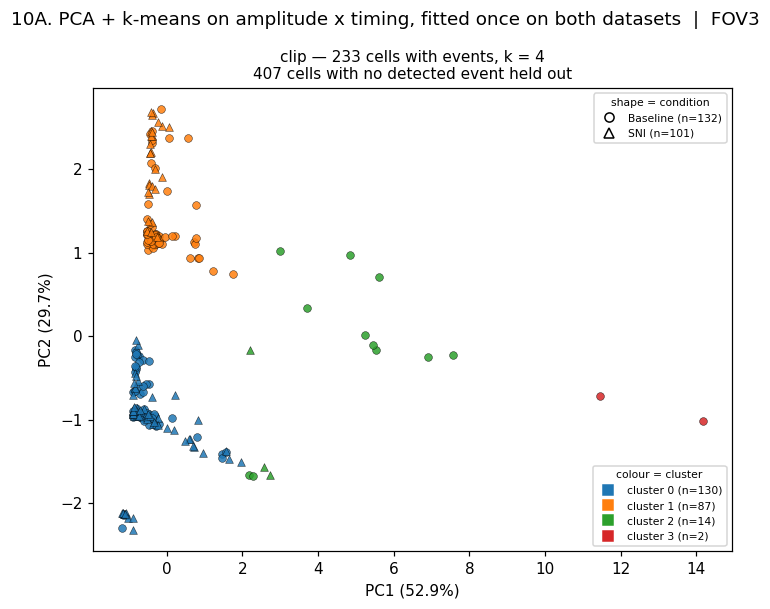

clip — cells per cluster (-1 = no detected event):


cluster,-1,0,1,2,3
condition,,,,,
Baseline,159,59,60,11,2
SNI,248,71,27,3,0


In [93]:
AMPLITUDE_AXES = ["auc_total", "peak_total", "n_event_frames"]
TIMING_AXES = ["peak_time_frac", "peak_segment", "sharpness_total"]
FEATURES = AMPLITUDE_AXES + TIMING_AXES


def zscore(X: np.ndarray) -> np.ndarray:
    """Standardise across the pooled population so PCA is not dominated by units."""
    sd = X.std(axis=0)
    return (X - X.mean(axis=0)) / np.where(sd > 0, sd, 1.0)


def feature_matrix(pooled: pd.DataFrame, keep: np.ndarray, log_sharpness: bool):
    """The pooled feature matrix, optionally with sharpness log-transformed."""
    X = pooled.loc[keep, FEATURES].to_numpy(float)
    if log_sharpness:
        X[:, FEATURES.index("sharpness_total")] = np.log10(
            X[:, FEATURES.index("sharpness_total")])
    if not np.isfinite(X).all():
        bad = {f: int((~np.isfinite(X[:, i])).sum()) for i, f in enumerate(FEATURES)
               if not np.isfinite(X[:, i]).all()}
        raise ValueError(f"non-finite features after the keep mask: {bad} — not imputing")
    return X


def pc2_degeneracy(Z: np.ndarray) -> float:
    """How far PC2 is just one feature rather than a combination: the largest |loading|."""
    return float(np.abs(PCA(n_components=2).fit(Z).components_[1]).max())


fig, axes = plt.subplots(1, max(len(PART_A), 1), squeeze=False, figsize=(6.6 * max(len(PART_A), 1), 5.6))
clustered = {}
for c, exp in enumerate(PART_A):
    pooled = pd.concat([runs[(cond, exp, FOV0)]["table"].assign(condition=cond)
                        for cond in CONDITIONS], ignore_index=True)
    keep = (pooled.label != "000").to_numpy()

    # sharpness is right-skewed and bounded below at ~1 while the amplitude axes are roughly
    # log-distributed. Fit both ways and keep whichever leaves PC2 a genuine mixture rather than
    # a single feature.
    scores = {use_log: pc2_degeneracy(zscore(feature_matrix(pooled, keep, use_log)))
              for use_log in (False, True)}
    log_sharpness = min(scores, key=scores.get)
    Z = zscore(feature_matrix(pooled, keep, log_sharpness))
    print(f"{exp}: max |PC2 loading| — raw sharpness {scores[False]:.3f}, "
          f"log10 {scores[True]:.3f}  ->  using "
          f"{'log10(sharpness_total)' if log_sharpness else 'sharpness_total'}")

    pca = PCA(n_components=min(PCA_N_COMPONENTS, *Z.shape))
    pts = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_ * 100
    groups = KMeans(CLUSTER_K, n_init=50, random_state=0).fit_predict(pts)
    pooled["cluster"] = -1                                   # -1 = no detected event
    pooled.loc[keep, "cluster"] = groups
    clustered[exp] = pooled

    # Two things are encoded at once, so each gets its own legend: colour = cluster, shape =
    # condition. Drawing every (cluster, condition) pair explicitly keeps the two independent.
    ax = axes[0][c]
    cond_kept = pooled.loc[keep, "condition"].to_numpy()
    for cl in range(CLUSTER_K):
        for cond, marker in (("Baseline", "o"), ("SNI", "^")):
            sel = (groups == cl) & (cond_kept == cond)
            if sel.any():
                ax.scatter(pts[sel, 0], pts[sel, 1], color=plt.cm.tab10(cl % 10), marker=marker,
                           s=26, edgecolor="k", linewidth=0.3, alpha=0.85)
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title(f"{exp} — {int(keep.sum())} cells with events, k = {CLUSTER_K}\n"
                 f"{int((~keep).sum())} cells with no detected event held out", fontsize=10)

    shape_key = [Line2D([], [], marker=m, linestyle="none", markerfacecolor="white",
                        markeredgecolor="k", label=f"{name} (n={int((cond_kept == name).sum())})")
                 for name, m in (("Baseline", "o"), ("SNI", "^"))]
    colour_key = [Line2D([], [], marker="s", linestyle="none", color=plt.cm.tab10(cl % 10),
                         label=f"cluster {cl} (n={int((groups == cl).sum())})")
                  for cl in range(CLUSTER_K)]
    # Both legends sit on the right: the cloud occupies the left half of both panels.
    ax.add_artist(ax.legend(handles=shape_key, title="shape = condition", loc="upper right",
                            fontsize=7, title_fontsize=7))
    ax.legend(handles=colour_key, title="colour = cluster", loc="lower right", fontsize=7,
              title_fontsize=7)

    names = [("log10(sharpness_total)" if (f == "sharpness_total" and log_sharpness) else f)
             for f in FEATURES]
    print(f"{exp} — what the axes are made of:")
    display(pd.DataFrame(pca.components_[:2].T, index=names, columns=["PC1", "PC2"]).round(2))
fig.suptitle(f"10A. PCA + k-means on amplitude x timing, fitted once on both datasets  |  {FOV0}")
fig.tight_layout()
save_fig(fig, "10A_pca_clusters")
plt.show()

for exp in PART_A:
    print(f"{exp} — cells per cluster (-1 = no detected event):")
    display(pd.crosstab(clustered[exp].condition, clustered[exp].cluster))

## 11A. Transition matrix (clip)

Rows are the Baseline label, columns the SNI label, cells are counts of paired ROIs. The diagonal is
cells that did not change; everything off it is a cell that did. Cells are paired **by ROI id**.

> The two days do not carry the same number of ROIs (FOV3: 291 → 349), so the pairing covers the ids
> present on both and the surplus SNI ids have no partner. Read this together with §8b: a segment
> whose `excess` over the null is small contributes transitions that are largely chance.

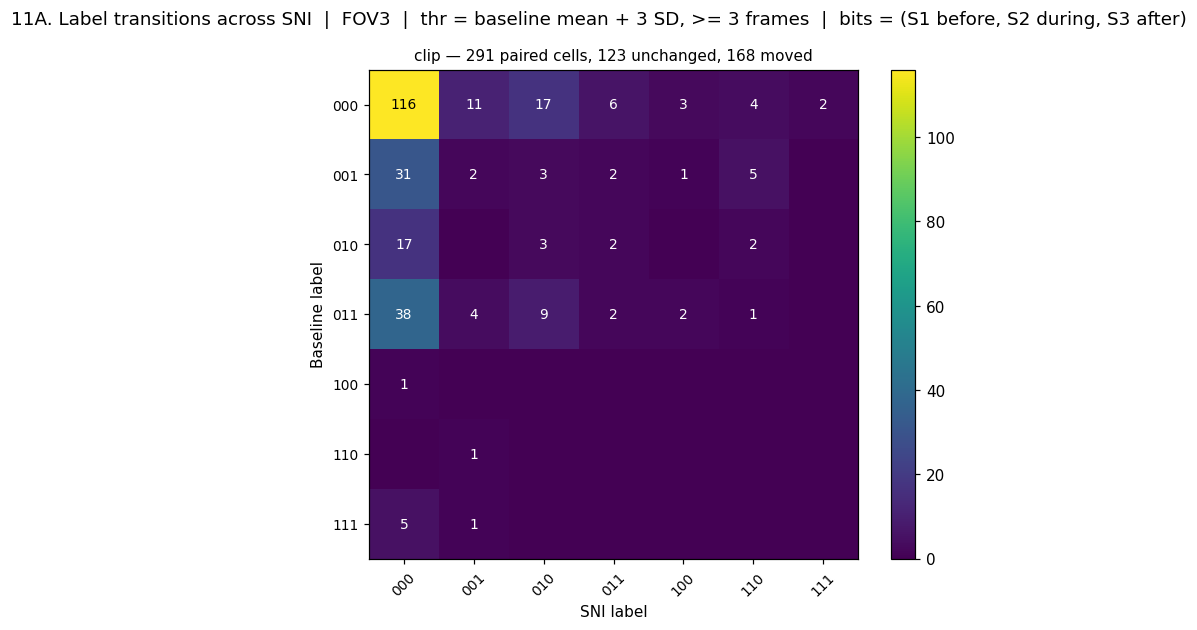


clip: 291 paired cells  |  123 unchanged (42%)  |  168 changed
    011 -> 000: 38
    001 -> 000: 31
    010 -> 000: 17
    000 -> 010: 17
    000 -> 001: 11
    011 -> 010: 9


In [94]:
def pair_indices(exp: str, fov: str):
    """ROI ids on both days, and each one's row index within its own recording."""
    a, b = runs[("Baseline", exp, fov)], runs[("SNI", exp, fov)]
    shared = np.intersect1d(a["roi_ids"], b["roi_ids"])
    return shared, np.searchsorted(a["roi_ids"], shared), np.searchsorted(b["roi_ids"], shared)


transition = {}
fig, axes = plt.subplots(1, max(len(PART_A), 1), squeeze=False, figsize=(6.8 * max(len(PART_A), 1), 5.8))
for c, exp in enumerate(PART_A):
    M = None
    for fov in FOVS:
        shared, ia, ib = pair_indices(exp, fov)
        la = runs[("Baseline", exp, fov)]["table"].label.to_numpy()[ia]
        lb = runs[("SNI", exp, fov)]["table"].label.to_numpy()[ib]
        ct = pd.crosstab(pd.Series(la, name="Baseline"), pd.Series(lb, name="SNI"))
        M = ct if M is None else M.add(ct, fill_value=0)
    M = M.fillna(0).astype(int)
    transition[exp] = M

    ax = axes[0][c]
    im = ax.imshow(M.values, cmap="viridis")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if M.values[i, j]:
                ax.text(j, i, str(M.values[i, j]), ha="center", va="center", fontsize=9,
                        color="white" if M.values[i, j] < M.values.max() * 0.6 else "black")
    ax.set_xticks(range(M.shape[1]), M.columns, rotation=45, fontsize=9)
    ax.set_yticks(range(M.shape[0]), M.index, fontsize=9)
    ax.set_xlabel("SNI label"); ax.set_ylabel("Baseline label")
    same = int(sum(M.loc[l, l] for l in M.index if l in M.columns))
    total = int(M.values.sum())
    ax.set_title(f"{exp} — {total} paired cells, {same} unchanged, {total - same} moved", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle(f"11A. Label transitions across SNI  |  {', '.join(FOVS)}  |  thr = baseline mean + "
             f"{DETECT_K:g} SD, >= {N_CONSEC} frames  |  bits = (S1 before, S2 during, S3 after)")
fig.tight_layout()
save_fig(fig, "11A_transitions")
plt.show()

for exp in PART_A:
    M = transition[exp]
    total = int(M.values.sum())
    same = int(sum(M.loc[l, l] for l in M.index if l in M.columns))
    print(f"\n{exp}: {total} paired cells  |  {same} unchanged "
          f"({100 * same / max(total, 1):.0f}%)  |  {total - same} changed")
    moves = sorted(((int(M.values[i, j]), M.index[i], M.columns[j])
                    for i in range(M.shape[0]) for j in range(M.shape[1])
                    if M.index[i] != M.columns[j] and M.values[i, j]), reverse=True)
    for n, a, b in moves[:6]:
        print(f"    {a} -> {b}: {n}")

## 12A. The spectrum — every ROI over time, ordered by weight

The final output. **x = time**, **y = one row per ROI**, colour = the **detected** inferred rate —
the signal that survived §8, so 0 means "no activity here", not "small activity". CASCADE's
undefined bins stay grey rather than being drawn as zero.

Rows are **sorted by weight, heaviest at the top**, so the y position itself carries the ranking.
`SPECTRUM_WEIGHT` picks what weight means:

| value | weight is |
|---|---|
| `significance` | −log₁₀(p) from the same circular-shift null as §8b: how rarely a surrogate of this cell matches its real detected AUC during the stimulus. Cells with no detected events get p = 1. |
| `auc_stim` | detected AUC inside the stimulus segment, original scale |
| `auc_total` | detected AUC over the whole recording |
| `peak_total` | largest detected rate |
| `n_event_frames` | how many frames the cell spent in an event |

Baseline and SNI share **one row order** — the order set by the Baseline recording — and only ROI
ids present on both days are drawn, so a given row is the same cell in both panels and can be read
straight across. The strip on the right plots the weight itself against that same ordering.

In [95]:
def roi_significance(rec: dict, exp: str, n_surrogates: int,
                     seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Per-ROI empirical p from the §8b null: how often a surrogate of this cell matches or beats
    its real detected AUC while the stimulus is on. Returns (real AUC, p).

    The stimulus window is selected by segment KIND, so this is the same code for either protocol
    even though only Part A calls it; §12B wraps the graze-specific choices around the same idea.
    """
    rng = np.random.default_rng(seed)
    t, edges = rec["time_s"], rec["edges"]
    stim = rec["kind_of_t"] == "on"
    offsets = checked_offsets(rec, exp, n_surrogates, tag="§12A ")
    real = np.trapezoid(np.nan_to_num(rec["det"]["detected"][stim], nan=0.0), t[stim], axis=0)
    beaten = np.zeros(rec["rate"].shape[1], dtype=int)
    for _ in range(n_surrogates):
        surrogate = detect_events(circular_shift(rec["rate"], rng, offsets), t, edges)["detected"]
        beaten += np.trapezoid(np.nan_to_num(surrogate[stim], nan=0.0), t[stim], axis=0) >= real
    return real, (1 + beaten) / (1 + n_surrogates)


def roi_weight(rec: dict, exp: str) -> np.ndarray:
    """The per-ROI quantity the spectrum is ordered by."""
    table = rec["table"]
    if SPECTRUM_WEIGHT == "significance":
        _, p = roi_significance(rec, exp, SPECTRUM_N_SURROGATES)
        return -np.log10(p)
    if SPECTRUM_WEIGHT == "auc_stim":
        return table["auc_S2"].to_numpy(float)
    if SPECTRUM_WEIGHT in table.columns:
        return table[SPECTRUM_WEIGHT].to_numpy(float)
    raise ValueError(f"SPECTRUM_WEIGHT must be 'significance', 'auc_stim', or a column of the §9A "
                     f"table; got {SPECTRUM_WEIGHT!r}")


for exp in PART_A:
    for cond in CONDITIONS:
        for fov in FOVS:
            runs[(cond, exp, fov)]["weight"] = roi_weight(runs[(cond, exp, fov)], exp)

print(f"weight = {SPECTRUM_WEIGHT}"
      + (f" ({SPECTRUM_N_SURROGATES} surrogates per ROI)" if SPECTRUM_WEIGHT == "significance"
         else "") + "   — Part A only; §12B computes the graze weight against its own null")
display(pd.DataFrame([
    {"condition": cond, "experiment": exp, "fov": fov, "n_roi": len(w),
     "weight_max": round(float(np.max(w)), 3),
     "weight_median": round(float(np.median(w)), 3),
     "nonzero_weight": int((w > 0).sum())}
    for exp in PART_A for cond in CONDITIONS for fov in FOVS
    for w in [runs[(cond, exp, fov)]["weight"]]]))

  ! §12A clip: 700 legal shift offsets for 200 surrogates, below the 10x target of 2000 (max at this pool = 70). The pool is the recording length itself, so no parameter enlarges it — the null is resampled from 700 rotations and p is resolution-limited at 1/201 regardless. Not raised: this is a property of the recording.
  ! §12A clip: 618 legal shift offsets for 200 surrogates, below the 10x target of 2000 (max at this pool = 61). The pool is the recording length itself, so no parameter enlarges it — the null is resampled from 618 rotations and p is resolution-limited at 1/201 regardless. Not raised: this is a property of the recording.
weight = significance (200 surrogates per ROI)   — Part A only; §12B computes the graze weight against its own null


,condition,experiment,fov,n_roi,weight_max,weight_median,nonzero_weight
0,Baseline,clip,FOV3,291,2.303,0.0,87
1,SNI,clip,FOV3,349,2.303,0.0,71


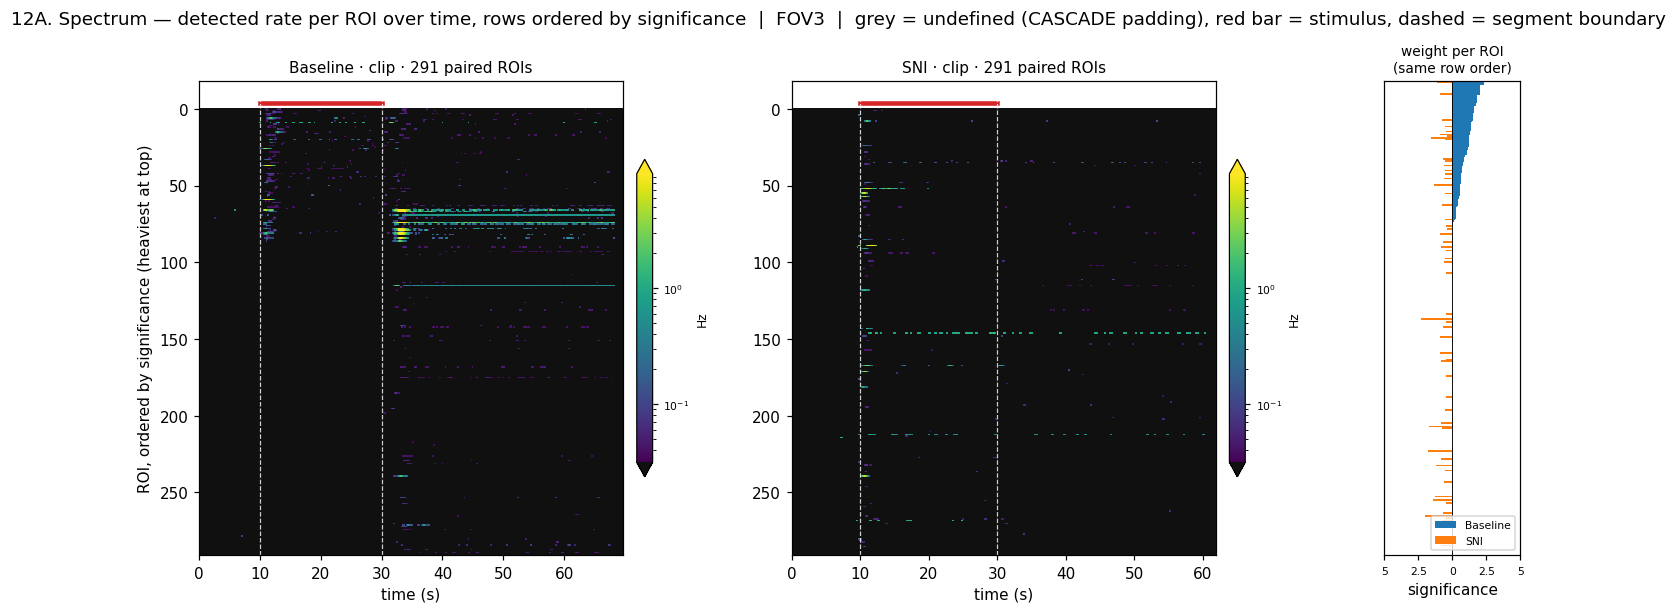

clip: 291 paired ROIs  |  weight>0  Baseline 87, SNI 58  |  gained 43, lost 83  |  top-10 Baseline ROI ids [126, 218, 5, 1, 137, 83, 78, 36, 86, 187]


In [96]:
spectrum_cmap = plt.get_cmap("viridis").copy()
spectrum_cmap.set_bad("0.85")        # CASCADE's undefined bins — never drawn as 0
spectrum_cmap.set_under("#101010")   # erased sub-threshold bins: "no activity", distinct from low

fig = plt.figure(figsize=(15.5, 5.6 * max(len(PART_A), 1)))
grid = fig.add_gridspec(max(len(PART_A), 1), 3, width_ratios=[1, 1, 0.30], hspace=0.38, wspace=0.40)

for r, exp in enumerate(PART_A):
    fov = FOVS[0]
    shared, ia, ib = pair_indices(exp, fov)
    base, sni = runs[("Baseline", exp, fov)], runs[("SNI", exp, fov)]

    # One order for both panels: the Baseline weight, heaviest first, so row 0 sits at the top.
    order = np.argsort(-base["weight"][ia])

    # Detected rates run from the detection threshold (~0.03 Hz) to ~20 Hz — three decades — and
    # the bulk sits just above threshold, so a linear ramp shows nothing but the few brightest
    # cells. Log scale, with the erased zeros pushed below vmin and drawn as "no activity".
    pooled_vals = np.concatenate([base["det"]["detected"][:, ia].ravel(),
                                  sni["det"]["detected"][:, ib].ravel()])
    nonzero = pooled_vals[np.isfinite(pooled_vals) & (pooled_vals > 0)]
    vmin = float(min(base["det"]["thr"].min(), sni["det"]["thr"].min()))
    vmax = float(np.percentile(nonzero, 99)) if nonzero.size else 1.0
    norm = LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10))

    for c, (rec, idx, name) in enumerate(((base, ia, "Baseline"), (sni, ib, "SNI"))):
        ax = fig.add_subplot(grid[r, c])
        # LogNorm treats 0 as invalid and would colour it with `set_bad`, i.e. identically to
        # CASCADE's undefined bins. Push the erased zeros just under vmin so they take `set_under`
        # instead, and leave only the true NaNs masked — 0 and "undefined" must not look alike.
        D = rec["det"]["detected"][:, idx][:, order].T
        M = np.ma.masked_invalid(np.where(D > 0, D, vmin * 0.1))
        t = rec["time_s"]
        im = ax.imshow(M, aspect="auto", cmap=spectrum_cmap, norm=norm,
                       extent=[t[0], t[-1], len(shared), 0], interpolation="nearest")
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            ax.plot([x0, x1], [-len(shared) * 0.012] * 2, lw=3, color="tab:red", clip_on=False)
        for edge in rec["edges"][1:-1]:
            ax.axvline(edge, color="white", lw=0.8, ls="--", alpha=0.8)
        ax.set_xlabel("time (s)")
        ax.set_ylabel(f"ROI, ordered by {SPECTRUM_WEIGHT} (heaviest at top)" if c == 0 else "")
        ax.set_title(f"{name} · {exp} · {len(shared)} paired ROIs", fontsize=10)
        cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, extend="both")
        cb.set_label("Hz", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    ax_w = fig.add_subplot(grid[r, 2])
    rows = np.arange(len(shared))
    ax_w.barh(rows, base["weight"][ia][order], height=1.0, color="tab:blue", label="Baseline")
    ax_w.barh(rows, -sni["weight"][ib][order], height=1.0, color="tab:orange", label="SNI")
    ax_w.axvline(0, color="k", lw=0.6)
    ax_w.set_ylim(len(shared), 0)
    ax_w.set_yticks([])
    ax_w.set_xlabel(SPECTRUM_WEIGHT)
    ax_w.set_title("weight per ROI\n(same row order)", fontsize=9)
    ax_w.legend(fontsize=7, loc="lower right")
    ticks = ax_w.get_xticks()
    ax_w.set_xticks(ticks, [f"{abs(v):g}" for v in ticks], fontsize=7)

fig.suptitle(f"12A. Spectrum — detected rate per ROI over time, rows ordered by {SPECTRUM_WEIGHT}"
             f"  |  {FOVS[0]}  |  grey = undefined (CASCADE padding), red bar = stimulus, "
             f"dashed = segment boundary", y=0.995)
save_fig(fig, "12A_spectrum")
plt.show()

for exp in PART_A:
    shared, ia, ib = pair_indices(exp, FOVS[0])
    wb = runs[("Baseline", exp, FOVS[0])]["weight"][ia]
    ws = runs[("SNI", exp, FOVS[0])]["weight"][ib]
    print(f"{exp}: {len(shared)} paired ROIs  |  weight>0  Baseline {int((wb > 0).sum())}, "
          f"SNI {int((ws > 0).sum())}  |  gained {int((ws > wb).sum())}, lost {int((ws < wb).sum())}"
          f"  |  top-10 Baseline ROI ids {shared[np.argsort(-wb)[:10]].tolist()}")

### 12Ab. Spectrum, quiet rows dropped

The black mass in §12a is the erased zeros, not a colour-scale problem: most rows are almost
entirely "no activity". Dropping cells that are quiet on **both** days removes those rows without
touching the phenotype of interest — a cell quiet at Baseline but active after SNI is kept, because
it only goes if it is quiet in *each* recording.

The cutoff is the `QUIET_PCT` percentile of the weight, computed **per day** so each recording is
judged against its own distribution. With `SPECTRUM_WEIGHT = "significance"` a cell with no detected
events scores exactly 0, so when more than `QUIET_PCT` % of cells are silent the percentile *is* 0
and a strict `<` would select nothing — hence `<=`, and `QUIET_ON_NONZERO` to take the percentile
over the responding cells only.

Row order and colour scaling follow §12a, so the two figures can be read against each other.

clip: cutoffs Baseline 0.575, SNI 0.504 (over weight>0)  |  dropped 198 of 291 (68%) quiet on both days  |  kept 93
    of the dropped: 19 had some Baseline signal, 14 had some SNI signal


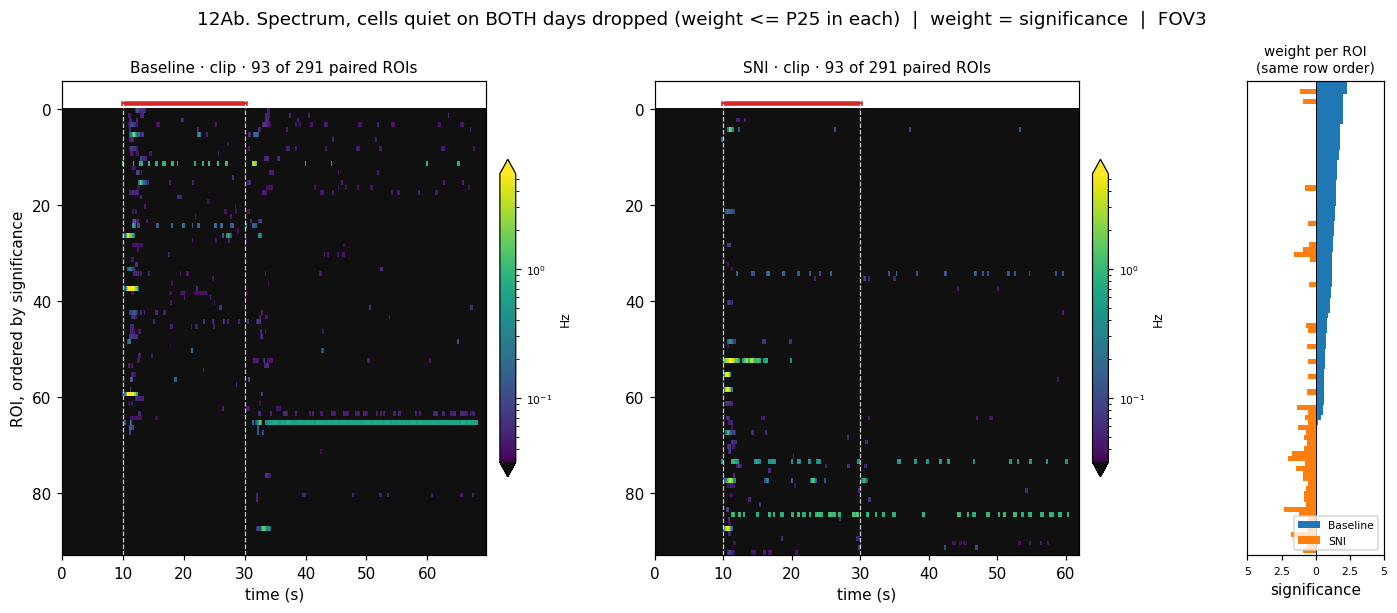

In [97]:
# Kept beside the figure they control rather than in the Config cell: these are display-only
# filters, and a long-lived kernel would otherwise raise NameError here whenever Config is not
# re-run after they change.
QUIET_PCT = 25              # percentile cutoff, applied per day
QUIET_ON_NONZERO = True     # take that percentile over weight > 0 only

fig = plt.figure(figsize=(15.5, 5.6 * max(len(PART_A), 1)))
grid = fig.add_gridspec(max(len(PART_A), 1), 3, width_ratios=[1, 1, 0.30], hspace=0.38, wspace=0.40)


def quiet_cutoff(w: np.ndarray) -> float:
    """The weight below which a cell counts as quiet, for one recording."""
    pool = w[w > 0] if (QUIET_ON_NONZERO and (w > 0).any()) else w
    return float(np.percentile(pool, QUIET_PCT))


for r, exp in enumerate(PART_A):
    fov = FOVS[0]
    shared, ia, ib = pair_indices(exp, fov)
    base, sni = runs[("Baseline", exp, fov)], runs[("SNI", exp, fov)]
    wb, ws = base["weight"][ia], sni["weight"][ib]

    cut_b, cut_s = quiet_cutoff(wb), quiet_cutoff(ws)
    keep = ~((wb <= cut_b) & (ws <= cut_s))        # AND: only drop cells quiet on both days
    if keep.sum() < 2:
        print(f"{exp}: filter would leave {int(keep.sum())} ROIs — skipped")
        continue

    kept = np.flatnonzero(keep)
    order = kept[np.argsort(-wb[kept])]            # same convention as §12a

    pooled_vals = np.concatenate([base["det"]["detected"][:, ia[kept]].ravel(),
                                  sni["det"]["detected"][:, ib[kept]].ravel()])
    nonzero = pooled_vals[np.isfinite(pooled_vals) & (pooled_vals > 0)]
    vmin = float(min(base["det"]["thr"].min(), sni["det"]["thr"].min()))
    vmax = float(np.percentile(nonzero, 99)) if nonzero.size else 1.0
    norm = LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10))

    for c, (rec, idx, name) in enumerate(((base, ia, "Baseline"), (sni, ib, "SNI"))):
        ax = fig.add_subplot(grid[r, c])
        D = rec["det"]["detected"][:, idx][:, order].T
        M = np.ma.masked_invalid(np.where(D > 0, D, vmin * 0.1))   # 0 -> set_under, NaN -> set_bad
        t = rec["time_s"]
        im = ax.imshow(M, aspect="auto", cmap=spectrum_cmap, norm=norm,
                       extent=[t[0], t[-1], len(order), 0], interpolation="nearest")
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            ax.plot([x0, x1], [-len(order) * 0.012] * 2, lw=3, color="tab:red", clip_on=False)
        for edge in rec["edges"][1:-1]:
            ax.axvline(edge, color="white", lw=0.8, ls="--", alpha=0.8)
        ax.set_xlabel("time (s)")
        ax.set_ylabel(f"ROI, ordered by {SPECTRUM_WEIGHT}" if c == 0 else "")
        ax.set_title(f"{name} · {exp} · {len(order)} of {len(shared)} paired ROIs", fontsize=10)
        cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, extend="both")
        cb.set_label("Hz", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    ax_w = fig.add_subplot(grid[r, 2])
    rows = np.arange(len(order))
    ax_w.barh(rows, wb[order], height=1.0, color="tab:blue", label="Baseline")
    ax_w.barh(rows, -ws[order], height=1.0, color="tab:orange", label="SNI")
    ax_w.axvline(0, color="k", lw=0.6)
    ax_w.set_ylim(len(order), 0)
    ax_w.set_yticks([])
    ax_w.set_xlabel(SPECTRUM_WEIGHT)
    ax_w.set_title("weight per ROI\n(same row order)", fontsize=9)
    ax_w.legend(fontsize=7, loc="lower right")
    ticks = ax_w.get_xticks()
    ax_w.set_xticks(ticks, [f"{abs(v):g}" for v in ticks], fontsize=7)

    dropped = (wb <= cut_b) & (ws <= cut_s)
    print(f"{exp}: cutoffs Baseline {cut_b:.3f}, SNI {cut_s:.3f}"
          f"{' (over weight>0)' if QUIET_ON_NONZERO else ''}  |  "
          f"dropped {int(dropped.sum())} of {len(shared)} ({100 * dropped.mean():.0f}%) "
          f"quiet on both days  |  kept {int(keep.sum())}\n"
          f"    of the dropped: {int((dropped & (wb > 0)).sum())} had some Baseline signal, "
          f"{int((dropped & (ws > 0)).sum())} had some SNI signal")

fig.suptitle(f"12Ab. Spectrum, cells quiet on BOTH days dropped (weight <= P{QUIET_PCT} in each)"
             f"  |  weight = {SPECTRUM_WEIGHT}  |  {FOVS[0]}", y=0.995)
save_fig(fig, "12Ab_spectrum_filtered")
plt.show()

### 12Ac. Spectrum, quiet rows dropped by rank-sum

A second way to drop quiet rows. §12b cuts each day at its own percentile; this one converts each
weight to a **percentile rank within the paired set** and drops a cell when
`pr_baseline + pr_sni < QUIET_PR_SUM`. A cell can therefore survive by being strong on one day
alone, which is the asymmetry the before/after question needs.

Two things guard it:

- **Ties matter.** Cells with no detected events all score exactly 0, and with
  `QUIET_RANK_METHOD = "average"` that tied block receives the midpoint of its own span. Once more
  than about half the cells are silent, two silent cells already sum above 50 and **the filter
  silently does nothing**. Diagnostic 1 below measures this and says so outright.
- **`PROTECT_LATE_RESPONDERS`.** Weight is computed on the stimulus segment S2 only, so a cell that
  is quiet during stimulation but responds chronically afterwards scores 0 on both days — that is
  the `001` phenotype, the thing this analysis exists to find. Any cell with at least one detected
  event outside S1, on either day, is never dropped.

**Scope: this is a display subset.** It changes nothing downstream — §11's transition matrix still
uses every paired ROI, and no analysis reads from here. Row order, colour scale and annotation
follow §12a; only the surviving rows are drawn, and the colour limits are recomputed over them.

clip: zero-weight cells 204 B / 233 S  |  zero-block percentile rank 35.0 B + 40.0 S = 75.0  (cutoff 50)
    ! the zero-weight block itself scores >= QUIET_PR_SUM — this rule will drop nothing. Switch QUIET_RANK_METHOD to 'min', or raise QUIET_PR_SUM.
    dropped 0 of 291 (0%)  |  of those, 0 had Baseline signal and 0 had SNI signal  |  guard rescued 0  |  kept 291


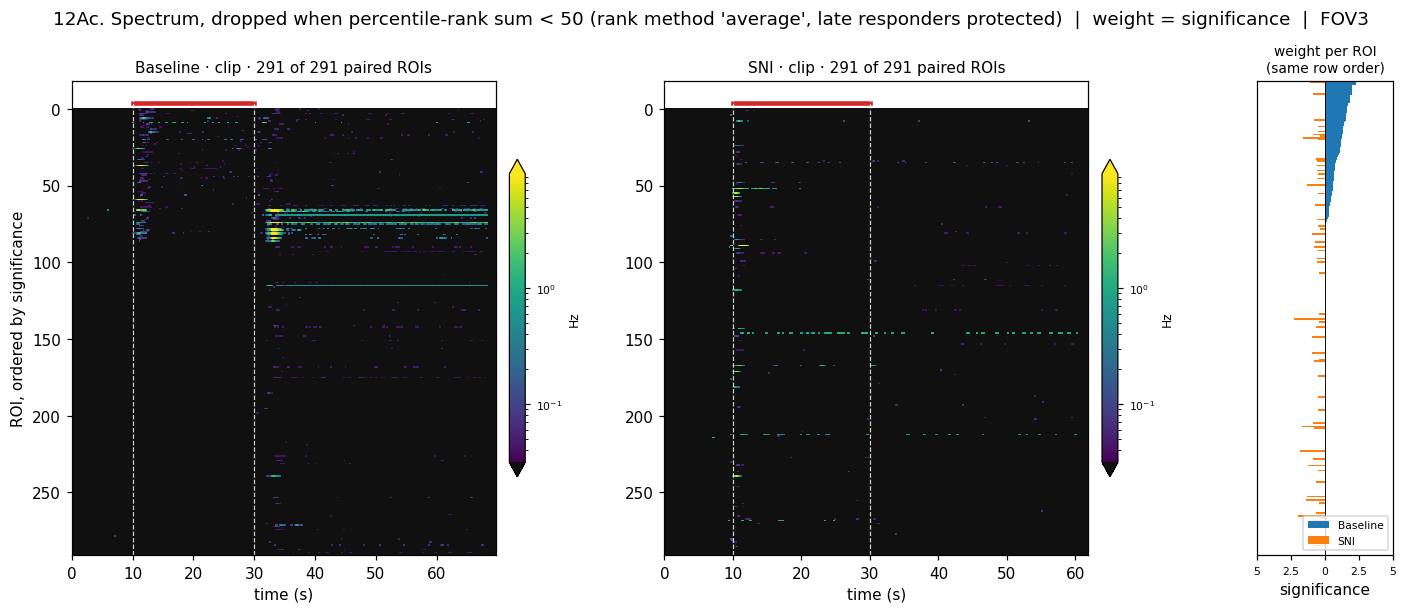

In [98]:
# Kept beside the figure they control rather than in the Config cell, for the same reason as §12b.
QUIET_PR_SUM = 50                # drop when the two days' percentile ranks sum below this
QUIET_RANK_METHOD = "average"    # "average" | "min" — see the tie diagnostic below
PROTECT_LATE_RESPONDERS = True   # never drop a cell with a detected event outside S1

from scipy.stats import rankdata


def percentile_rank(w: np.ndarray) -> np.ndarray:
    """Rank within the paired set, rescaled to 0–100."""
    return 100.0 * (rankdata(w, method=QUIET_RANK_METHOD) - 1) / (len(w) - 1)


fig = plt.figure(figsize=(15.5, 5.6 * max(len(PART_A), 1)))
grid = fig.add_gridspec(max(len(PART_A), 1), 3, width_ratios=[1, 1, 0.30], hspace=0.38, wspace=0.40)

for r, exp in enumerate(PART_A):
    fov = FOVS[0]
    shared, ia, ib = pair_indices(exp, fov)          # same pairing as §11
    base, sni = runs[("Baseline", exp, fov)], runs[("SNI", exp, fov)]
    wb, ws = base["weight"][ia], sni["weight"][ib]   # reuse §12a's weights, no new surrogates
    pr_b, pr_s = percentile_rank(wb), percentile_rank(ws)
    drop = (pr_b + pr_s) < QUIET_PR_SUM

    # Diagnostic 1 — tie degeneracy. A tied block of silent cells can score above the cutoff on
    # its own, in which case this rule cannot drop anything.
    zero_pr_b = float(pr_b[wb == 0].max()) if (wb == 0).any() else 0.0
    zero_pr_s = float(pr_s[ws == 0].max()) if (ws == 0).any() else 0.0
    print(f"{exp}: zero-weight cells {int((wb == 0).sum())} B / {int((ws == 0).sum())} S  |  "
          f"zero-block percentile rank {zero_pr_b:.1f} B + {zero_pr_s:.1f} S = "
          f"{zero_pr_b + zero_pr_s:.1f}  (cutoff {QUIET_PR_SUM})")
    if zero_pr_b + zero_pr_s >= QUIET_PR_SUM:
        print(f"    ! the zero-weight block itself scores >= QUIET_PR_SUM — this rule will drop "
              f"nothing. Switch QUIET_RANK_METHOD to 'min', or raise QUIET_PR_SUM.")

    # Step 4 — never drop a cell with a detected event outside the pre-stimulus segment.
    rescued = np.zeros_like(drop)
    if PROTECT_LATE_RESPONDERS:
        late_b = base["det"]["events"][base["seg_of_t"] != 0][:, ia].any(axis=0)
        late_s = sni["det"]["events"][sni["seg_of_t"] != 0][:, ib].any(axis=0)
        rescued = drop & (late_b | late_s)
        drop = drop & ~(late_b | late_s)
    keep = ~drop

    # Diagnostic 2 — drop accounting.
    print(f"    dropped {int(drop.sum())} of {len(shared)} ({100 * drop.mean():.0f}%)  |  "
          f"of those, {int((drop & (wb > 0)).sum())} had Baseline signal and "
          f"{int((drop & (ws > 0)).sum())} had SNI signal  |  guard rescued {int(rescued.sum())}"
          f"  |  kept {int(keep.sum())}")

    if keep.sum() < 2:
        print(f"    {exp}: filter would leave {int(keep.sum())} ROIs — not plotted")
        continue

    kept = np.flatnonzero(keep)
    order = kept[np.argsort(-wb[kept])]              # same convention as §12a

    # Colour limits over the surviving cells only.
    pooled_vals = np.concatenate([base["det"]["detected"][:, ia[kept]].ravel(),
                                  sni["det"]["detected"][:, ib[kept]].ravel()])
    nonzero = pooled_vals[np.isfinite(pooled_vals) & (pooled_vals > 0)]
    vmin = float(min(base["det"]["thr"].min(), sni["det"]["thr"].min()))
    vmax = float(np.percentile(nonzero, 99)) if nonzero.size else 1.0
    norm = LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10))

    for c, (rec, idx, name) in enumerate(((base, ia, "Baseline"), (sni, ib, "SNI"))):
        ax = fig.add_subplot(grid[r, c])
        D = rec["det"]["detected"][:, idx][:, order].T
        M = np.ma.masked_invalid(np.where(D > 0, D, vmin * 0.1))   # 0 -> set_under, NaN -> set_bad
        t = rec["time_s"]
        im = ax.imshow(M, aspect="auto", cmap=spectrum_cmap, norm=norm,
                       extent=[t[0], t[-1], len(order), 0], interpolation="nearest")
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            ax.plot([x0, x1], [-len(order) * 0.012] * 2, lw=3, color="tab:red", clip_on=False)
        for edge in rec["edges"][1:-1]:
            ax.axvline(edge, color="white", lw=0.8, ls="--", alpha=0.8)
        ax.set_xlabel("time (s)")
        ax.set_ylabel(f"ROI, ordered by {SPECTRUM_WEIGHT}" if c == 0 else "")
        ax.set_title(f"{name} · {exp} · {len(order)} of {len(shared)} paired ROIs", fontsize=10)
        cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, extend="both")
        cb.set_label("Hz", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    ax_w = fig.add_subplot(grid[r, 2])
    rows = np.arange(len(order))
    ax_w.barh(rows, wb[order], height=1.0, color="tab:blue", label="Baseline")
    ax_w.barh(rows, -ws[order], height=1.0, color="tab:orange", label="SNI")
    ax_w.axvline(0, color="k", lw=0.6)
    ax_w.set_ylim(len(order), 0)
    ax_w.set_yticks([])
    ax_w.set_xlabel(SPECTRUM_WEIGHT)
    ax_w.set_title("weight per ROI\n(same row order)", fontsize=9)
    ax_w.legend(fontsize=7, loc="lower right")
    ticks = ax_w.get_xticks()
    ax_w.set_xticks(ticks, [f"{abs(v):g}" for v in ticks], fontsize=7)

fig.suptitle(f"12Ac. Spectrum, dropped when percentile-rank sum < {QUIET_PR_SUM} "
             f"(rank method '{QUIET_RANK_METHOD}'"
             + (", late responders protected" if PROTECT_LATE_RESPONDERS else "")
             + f")  |  weight = {SPECTRUM_WEIGHT}  |  {FOVS[0]}", y=0.995)
save_fig(fig, "12Ac_spectrum_ranksum")
plt.show()

## 9B. Output 1 (graze) — per-cycle table and phenotype

**Part B. graze only.** This replaces the bit-string label: with 26 segments a bit per segment
gives 2²⁶ labels, which is a serial number rather than a phenotype.

Per ROI, per cycle *i*: `auc_on[i]`, `auc_gap[i]`, `peak_on[i]`, and
`responded[i]` = any detected event inside `C{i}_on`. This is **descriptive by design — there is no
per-cycle p-value.** A test per cycle per cell is 12 × n_roi tests answering a question nobody
asked; the trend across cycles (§13) and the whole-recording weight (§12B) are where the testing
belongs.

Summarised per ROI:

| column | is |
|---|---|
| `n_trials_responded` | 0–12 |
| `first_trial` | first responded cycle, `NaN` if none — **the direct test of "only from the 4th graze onwards"** |
| `last_trial` | last responded cycle |
| `trial_slope` | Theil–Sen slope of `auc_on` across cycles: robust, > 0 = sensitising, < 0 = adapting |
| `trial_rho` | Spearman(cycle index, `auc_on`) |
| `on_gap_ratio` | `sum(auc_on) / sum(auc_gap)` — **high = phasic, ≈ 1 or lower = tonic/sustained** |
| `phase_vector_strength`, `phase_p` | each event onset folded onto the cycle, mean unit vector, Rayleigh test |

`on_gap_ratio` is the axis a single `S2` bit made invisible, and it is what "persistent response"
can mean for graze — activity carrying into the 5 s gap after each graze. It is *not* the same
statement as clip's chronic response, and §8 explains why graze cannot make that one.

The phase statistics are reported **alongside** the shift-based weight of §12B, not instead of it:
they measure a different thing (is the response locked to a consistent point in the cycle) and they
say nothing about whether the cell responded more than chance.

### The label

| label | rule |
|---|---|
| `none` | `n_trials_responded == 0` |
| `early_phasic` | `first_trial ≤ EARLY_MAX_TRIAL` and `on_gap_ratio ≥ ON_GAP_HIGH` |
| `early_tonic` | `first_trial ≤ EARLY_MAX_TRIAL` and `on_gap_ratio < ON_GAP_HIGH` |
| `late_phasic` | `first_trial > EARLY_MAX_TRIAL` and `on_gap_ratio ≥ ON_GAP_HIGH` |
| `late_tonic` | `first_trial > EARLY_MAX_TRIAL` and `on_gap_ratio < ON_GAP_HIGH` |

Both thresholds are **declared parameters, not fitted** — the same status as the segment
boundaries. The cell prints the `on_gap_ratio` distribution with the cut drawn on it, so the cut
can be judged by looking rather than accepted because it appeared in the config.

graze: per-ROI summary — 12 cycles, label thresholds are DECLARED (early = first_trial <= 3, phasic = on_gap_ratio >= 2.0)


,condition,n_roi,none,early_phasic,early_tonic,late_phasic,late_tonic
0,Baseline,291,194,47,11,24,15
1,SNI,349,255,19,18,31,26


responders only — the summary axes:


,condition,responders,median_n_trials,median_first_trial,median_trial_slope,slope>0,slope<0,median_on_gap_ratio,on_gap_ratio=inf,phase_p<0.05
0,Baseline,97,2.0,3.0,0.0,7,2,1.07,43,21
1,SNI,94,2.0,5.0,0.0,12,5,0.66,34,6


  Baseline: 9 of 97 responders have a non-zero trial_slope — the median responder fires in 2 of 12 cycles, and a slope through a mostly-zero series is 0.
  SNI: 17 of 94 responders have a non-zero trial_slope — the median responder fires in 2 of 12 cycles, and a slope through a mostly-zero series is 0.


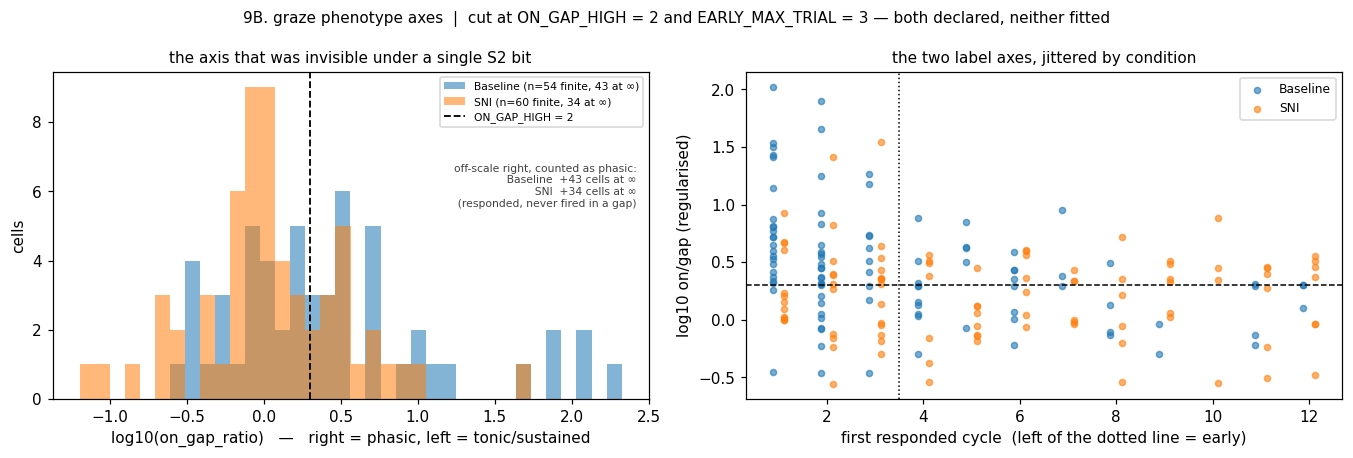

In [99]:
from scipy.stats import theilslopes, spearmanr

GRAZE_LABELS = ("none", "early_phasic", "early_tonic", "late_phasic", "late_tonic")
graze_label_colors = {lab: plt.cm.tab10(i) for i, lab in enumerate(GRAZE_LABELS)}


def cycle_masks(rec: dict) -> tuple[np.ndarray, np.ndarray]:
    """(n_cycle, n_time) boolean masks for each cycle's ON and GAP window.

    Built from seg_kind, so the cycles come from the §8 segmentation rather than from a second,
    independently-derived set of window boundaries that could drift out of step with it.
    """
    seg, kind = rec["seg_of_t"], rec["seg_kind"]
    on = np.array([seg == s for s in np.flatnonzero(kind == "on")])
    gap = np.array([seg == s for s in np.flatnonzero(kind == "gap")])
    return on, gap


def graze_cycle_table(rec: dict, cond: str) -> pd.DataFrame:
    """Per ROI, per cycle: detected AUC and peak in the graze window and in the gap after it.

    Descriptive by design — there is no per-cycle p-value here. A test per cycle per cell is
    12 x n_roi tests answering a question nobody asked; the trend across cycles (§13) and the
    whole-recording weight (§12B) are where the testing belongs.
    """
    on_m, gap_m = cycle_masks(rec)
    t = rec["time_s"]
    ev, det = rec["det"]["events"], rec["det"]["detected"]
    out = []
    for i in range(len(on_m)):
        d_on = np.nan_to_num(det[on_m[i]], nan=0.0)      # undefined bins contribute nothing
        d_gap = np.nan_to_num(det[gap_m[i]], nan=0.0)
        out.append(pd.DataFrame({
            "condition": cond, "roi_id": rec["roi_ids"], "cycle": i + 1,
            "auc_on": np.trapezoid(d_on, t[on_m[i]], axis=0),
            "auc_gap": np.trapezoid(d_gap, t[gap_m[i]], axis=0),
            "peak_on": d_on.max(axis=0),
            "responded": ev[on_m[i]].any(axis=0),
            "responded_gap": ev[gap_m[i]].any(axis=0)}))
    return pd.concat(out, ignore_index=True)


def rayleigh(phases: np.ndarray) -> tuple[float, float]:
    """Mean resultant length R and the Rayleigh p for uniformity, on angles in radians.

    p uses Zar's approximation. R near 1 = every event lands at the same point in the cycle;
    R near 0 = events scattered across the cycle.
    """
    n = len(phases)
    if n < RAYLEIGH_MIN_EVENTS:
        return np.nan, np.nan
    C, S = np.cos(phases).sum(), np.sin(phases).sum()
    R = float(np.hypot(C, S) / n)
    Z = n * R * R
    p = float(np.exp(np.sqrt(1 + 4 * n + 4 * (n * n - Z * n)) - (1 + 2 * n)))
    return R, min(p, 1.0)


def graze_summary(rec: dict, cycles: pd.DataFrame) -> pd.DataFrame:
    """One row per ROI: when it started responding, whether it grew, and how phasic it is."""
    n_roi = rec["rate"].shape[1]
    idx = np.arange(1, GRAZE_N_TRIALS + 1)
    piv = lambda col: (cycles.pivot_table(index="roi_id", columns="cycle", values=col)
                       .reindex(index=rec["roi_ids"], columns=idx).to_numpy(float))
    auc_on, auc_gap = piv("auc_on"), piv("auc_gap")
    resp = piv("responded") > 0.5

    n_resp = resp.sum(axis=1)
    any_resp = n_resp > 0
    first = np.where(any_resp, np.argmax(resp, axis=1) + 1.0, np.nan)
    last = np.where(any_resp, GRAZE_N_TRIALS - np.argmax(resp[:, ::-1], axis=1), np.nan)

    slope = np.full(n_roi, np.nan)
    rho = np.full(n_roi, np.nan)
    for j in range(n_roi):
        y = auc_on[j]
        if np.ptp(y) > 0:                       # a flat series has no slope and no rank order
            slope[j] = theilslopes(y, idx).slope
            rho[j] = spearmanr(idx, y).statistic

    sum_on, sum_gap = auc_on.sum(axis=1), auc_gap.sum(axis=1)
    ratio = np.divide(sum_on, sum_gap, out=np.full(n_roi, np.inf), where=sum_gap > 0)
    ratio[(sum_on == 0) & (sum_gap == 0)] = np.nan      # no events at all: undefined, not 0
    # Regularised twin for clustering and plotting: log10 of the ratio with ON_GAP_EPS on both
    # sides, so a cell with an empty gap window is finite instead of +inf. Declared, not fitted.
    ratio_log = np.log10((sum_on + ON_GAP_EPS) / (sum_gap + ON_GAP_EPS))

    # Phase: fold each detected event ONSET in the stimulus block onto the cycle.
    t = rec["time_s"]
    block = (t >= rec["edges"][1]) & (t < rec["edges"][-2])
    onsets = event_onsets(rec["det"]["events"] & block[:, None], t)
    R = np.full(n_roi, np.nan)
    p_ray = np.full(n_roi, np.nan)
    n_ev = np.zeros(n_roi, dtype=int)
    for j, times in enumerate(onsets):
        n_ev[j] = len(times)
        phase = 2 * np.pi * ((times - GRAZE_BASELINE_S) % GRAZE_CYCLE_S) / GRAZE_CYCLE_S
        R[j], p_ray[j] = rayleigh(phase)

    out = pd.DataFrame({**rec["totals"],
                        "n_trials_responded": n_resp, "first_trial": first, "last_trial": last,
                        "trial_slope": slope, "trial_rho": rho,
                        "auc_on_sum": sum_on, "auc_gap_sum": sum_gap,
                        "on_gap_ratio": ratio, "on_gap_log": ratio_log,
                        "n_events_in_block": n_ev,
                        "phase_vector_strength": R, "phase_p": p_ray})

    phasic = out.on_gap_ratio >= ON_GAP_HIGH             # +inf counts as phasic, correctly
    early = out.first_trial <= EARLY_MAX_TRIAL
    out["label"] = np.select(
        [out.n_trials_responded == 0, early & phasic, early & ~phasic, ~early & phasic],
        ["none", "early_phasic", "early_tonic", "late_phasic"], default="late_tonic")
    return out


graze_cycles, graze_table = {}, {}
for exp in PART_B:
    for cond in CONDITIONS:
        rec = runs[(cond, exp, FOV0)]
        graze_cycles[(cond, exp)] = graze_cycle_table(rec, cond)
        rec["table"] = graze_summary(rec, graze_cycles[(cond, exp)])
        graze_table[(cond, exp)] = rec["table"]

for exp in PART_B:
    print(f"{exp}: per-ROI summary — {GRAZE_N_TRIALS} cycles, label thresholds are DECLARED "
          f"(early = first_trial <= {EARLY_MAX_TRIAL}, phasic = on_gap_ratio >= {ON_GAP_HIGH})")
    display(pd.DataFrame([
        {"condition": cond, "n_roi": len(graze_table[(cond, exp)]),
         **{lab: int((graze_table[(cond, exp)].label == lab).sum()) for lab in GRAZE_LABELS}}
        for cond in CONDITIONS]))

    print("responders only — the summary axes:")
    display(pd.DataFrame([
        {"condition": cond,
         "responders": int((tb.n_trials_responded > 0).sum()),
         "median_n_trials": float(tb.loc[tb.n_trials_responded > 0, "n_trials_responded"].median()),
         "median_first_trial": float(tb.first_trial.median()),
         "median_trial_slope": round(float(tb.trial_slope.median(skipna=True)), 5),
         "slope>0": int((tb.trial_slope > 0).sum()), "slope<0": int((tb.trial_slope < 0).sum()),
         "median_on_gap_ratio": round(float(tb.loc[np.isfinite(tb.on_gap_ratio),
                                                   "on_gap_ratio"].median()), 2),
         "on_gap_ratio=inf": int(np.isinf(tb.on_gap_ratio).sum()),
         "phase_p<0.05": int((tb.phase_p < 0.05).sum())}
        for cond in CONDITIONS
        for tb in [graze_table[(cond, exp)]]]))

    # trial_slope is weak on this dataset and it is better to say so than to let it look like a
    # working axis: the median responder fires in 2 of 12 cycles, so auc_on is a mostly-zero
    # series and the Theil-Sen slope through it is exactly 0. It stays in the feature set (a
    # cell that really does ramp is exactly what it catches) but it carries little variance here.
    for cond in CONDITIONS:
        tb = graze_table[(cond, exp)]
        resp = tb.n_trials_responded > 0
        nz = int((resp & (tb.trial_slope != 0) & np.isfinite(tb.trial_slope)).sum())
        print(f"  {cond}: {nz} of {int(resp.sum())} responders have a non-zero trial_slope — the "
              f"median responder fires in {tb.loc[resp, 'n_trials_responded'].median():.0f} of "
              f"{GRAZE_N_TRIALS} cycles, and a slope through a mostly-zero series is 0.")

# The on_gap_ratio cut is a declared parameter, so print the distribution it is cutting and let
# the cut be judged by eye rather than by a number that came from nowhere.
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))
for exp in PART_B:
    ax = axes[0]
    # Cells that never fired in a gap have on_gap_ratio = +inf. They are the MOST phasic cells,
    # so dropping them would truncate exactly the tail the cut is meant to separate: they get an
    # explicit overflow bar to the right of the finite distribution instead.
    finite = {cond: graze_table[(cond, exp)].loc[
        np.isfinite(graze_table[(cond, exp)].on_gap_ratio)
        & (graze_table[(cond, exp)].n_trials_responded > 0), "on_gap_ratio"]
        for cond in CONDITIONS}
    for cond in CONDITIONS:
        n_inf = int(np.isinf(graze_table[(cond, exp)].on_gap_ratio).sum())
        ax.hist(np.log10(np.maximum(finite[cond], 1e-3)), bins=30, alpha=0.55,
                color=COND_COLOR[cond], label=f"{cond} (n={len(finite[cond])} finite, {n_inf} at ∞)")
    ax.axvline(np.log10(ON_GAP_HIGH), color="k", ls="--", lw=1.2,
               label=f"ON_GAP_HIGH = {ON_GAP_HIGH:g}")
    # Annotated rather than drawn as a bar: the infinite group is several times the tallest
    # finite bin, and plotting it would flatten the distribution this panel exists to show.
    ax.text(0.98, 0.72, "off-scale right, counted as phasic:\n"
            + "\n".join(f"  {c}  +{int(np.isinf(graze_table[(c, exp)].on_gap_ratio).sum())} "
                        "cells at ∞" for c in CONDITIONS)
            + "\n  (responded, never fired in a gap)",
            transform=ax.transAxes, ha="right", va="top", fontsize=7, color="0.25")
    ax.set_xlabel("log10(on_gap_ratio)   —   right = phasic, left = tonic/sustained")
    ax.set_ylabel("cells")
    ax.set_title("the axis that was invisible under a single S2 bit", fontsize=10)
    ax.legend(fontsize=7)

    ax = axes[1]
    for cond in CONDITIONS:
        tb = graze_table[(cond, exp)]
        sel = tb.n_trials_responded > 0
        ax.scatter(tb.loc[sel, "first_trial"] + (0.12 if cond == "SNI" else -0.12),
                   tb.loc[sel, "on_gap_log"], s=16, alpha=0.6, color=COND_COLOR[cond], label=cond)
    ax.axhline(np.log10(ON_GAP_HIGH), color="k", ls="--", lw=1.0)
    ax.axvline(EARLY_MAX_TRIAL + 0.5, color="k", ls=":", lw=1.0)
    ax.set_xlabel(f"first responded cycle  (left of the dotted line = early)")
    ax.set_ylabel("log10 on/gap (regularised)")
    ax.set_title("the two label axes, jittered by condition", fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle(f"9B. graze phenotype axes  |  cut at ON_GAP_HIGH = {ON_GAP_HIGH:g} and "
             f"EARLY_MAX_TRIAL = {EARLY_MAX_TRIAL} — both declared, neither fitted", fontsize=10)
fig.tight_layout()
save_fig(fig, "9B_graze_axes")
plt.show()

## 10B. Output 2 (graze) — PCA + clustering on amplitude × per-cycle timing

`AMPLITUDE_AXES` is the same list Part A uses. The timing axes are the graze ones:

```
TIMING_AXES_GRAZE = ["first_trial", "trial_slope", "on_gap_log", "sharpness_total"]
```

— when the cell started responding, whether it grew across cycles, how phasic it is, and its shape.
`on_gap_ratio` enters as its **log**, because the raw ratio spans decades and is `+inf` for a cell
that never fires in a gap; `on_gap_log` is the regularised form from §9B, with `ON_GAP_EPS` on both
sides of the fraction so those cells stay finite. The regulariser is declared, not fitted.

PCA and k-means are fitted **once on the pooled Baseline + SNI cells**, exactly as in §10A, so a
cluster id means the same thing on both days. Features are z-scored across the pooled population —
a population-level rescaling, not the per-cell normalisation that would divide amplitude out.

Cells that never responded in an ON window are **held out**, not imputed: `first_trial` is
undefined for them, and filling it in would invent the quantity the axis exists to measure.

> **`trial_slope` is weak on this dataset**, and the cell says so with a number. The median
> responder fires in 2 of 12 cycles, so `auc_on` is a mostly-zero series and a robust slope through
> it is exactly 0 for most cells. It stays in the feature set because a cell that genuinely ramps
> is precisely what it catches — but it carries little variance here, and the printed loadings show
> what PC1 and PC2 are actually made of.

graze — what the axes are made of:


,PC1,PC2
auc_total,0.51,-0.16
peak_total,0.47,-0.08
n_event_frames,0.41,0.14
first_trial,-0.15,-0.65
trial_slope,0.49,-0.19
on_gap_log,-0.02,0.66
sharpness_total,0.32,0.22


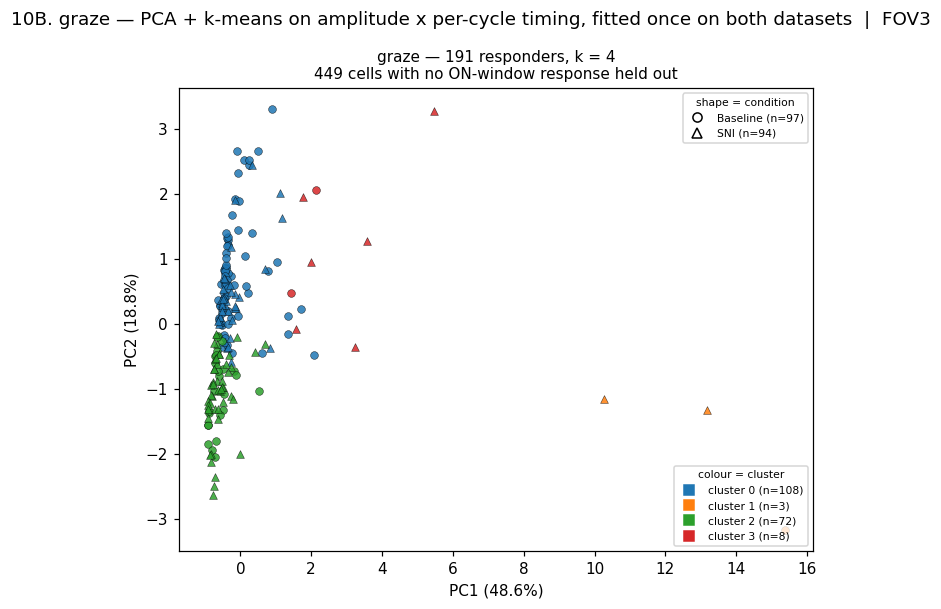

graze — cells per cluster (-1 = no ON-window response):


cluster,-1,0,1,2,3
condition,,,,,
Baseline,194,69,1,25,2
SNI,255,39,2,47,6


graze — cluster against the declared §9B label:


cluster,-1,0,1,2,3
label,,,,,
early_phasic,0,62,1,0,3
early_tonic,0,22,2,1,4
late_phasic,0,19,0,36,0
late_tonic,0,5,0,35,1
none,449,0,0,0,0


In [100]:
# AMPLITUDE_AXES is shared with §10A. The timing axes are the graze ones: when the cell started
# responding, whether it grew across cycles, how phasic it is, and its shape. on_gap_ratio enters
# as its log (the regularised `on_gap_log` from §9B) because the raw ratio spans decades and is
# +inf for cells that never fire in a gap.
TIMING_AXES_GRAZE = ["first_trial", "trial_slope", "on_gap_log", "sharpness_total"]
FEATURES_GRAZE = AMPLITUDE_AXES + TIMING_AXES_GRAZE

fig, axes = plt.subplots(1, max(len(PART_B), 1), squeeze=False, figsize=(6.6 * max(len(PART_B), 1), 5.6))
clustered_B = {}
for c, exp in enumerate(PART_B):
    pooled = pd.concat([graze_table[(cond, exp)].assign(condition=cond) for cond in CONDITIONS],
                       ignore_index=True)
    # Responders only: first_trial is undefined for a cell that never responded in an ON window,
    # and imputing it would invent the very quantity the axis exists to measure.
    keep = (pooled.n_trials_responded > 0).to_numpy()

    X = pooled.loc[keep, FEATURES_GRAZE].to_numpy(float)
    if not np.isfinite(X).all():
        bad = {f: int((~np.isfinite(X[:, i])).sum()) for i, f in enumerate(FEATURES_GRAZE)
               if not np.isfinite(X[:, i]).all()}
        raise ValueError(f"non-finite graze features after the keep mask: {bad} — not imputing")
    Z = zscore(X)

    pca = PCA(n_components=min(PCA_N_COMPONENTS, *Z.shape))
    pts = pca.fit_transform(Z)
    var = pca.explained_variance_ratio_ * 100
    groups = KMeans(CLUSTER_K, n_init=50, random_state=0).fit_predict(pts)
    pooled["cluster"] = -1                                   # -1 = never responded in an ON window
    pooled.loc[keep, "cluster"] = groups
    clustered_B[exp] = pooled

    ax = axes[0][c]
    cond_kept = pooled.loc[keep, "condition"].to_numpy()
    for cl in range(CLUSTER_K):
        for cond, marker in (("Baseline", "o"), ("SNI", "^")):
            sel = (groups == cl) & (cond_kept == cond)
            if sel.any():
                ax.scatter(pts[sel, 0], pts[sel, 1], color=plt.cm.tab10(cl % 10), marker=marker,
                           s=26, edgecolor="k", linewidth=0.3, alpha=0.85)
    ax.set_xlabel(f"PC1 ({var[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({var[1]:.1f}%)")
    ax.set_title(f"{exp} — {int(keep.sum())} responders, k = {CLUSTER_K}\n"
                 f"{int((~keep).sum())} cells with no ON-window response held out", fontsize=10)

    shape_key = [Line2D([], [], marker=m, linestyle="none", markerfacecolor="white",
                        markeredgecolor="k", label=f"{name} (n={int((cond_kept == name).sum())})")
                 for name, m in (("Baseline", "o"), ("SNI", "^"))]
    colour_key = [Line2D([], [], marker="s", linestyle="none", color=plt.cm.tab10(cl % 10),
                         label=f"cluster {cl} (n={int((groups == cl).sum())})")
                  for cl in range(CLUSTER_K)]
    ax.add_artist(ax.legend(handles=shape_key, title="shape = condition", loc="upper right",
                            fontsize=7, title_fontsize=7))
    ax.legend(handles=colour_key, title="colour = cluster", loc="lower right", fontsize=7,
              title_fontsize=7)

    print(f"{exp} — what the axes are made of:")
    display(pd.DataFrame(pca.components_[:2].T, index=FEATURES_GRAZE,
                         columns=["PC1", "PC2"]).round(2))
fig.suptitle(f"10B. graze — PCA + k-means on amplitude x per-cycle timing, fitted once on both "
             f"datasets  |  {FOV0}")
fig.tight_layout()
save_fig(fig, "10B_graze_pca")
plt.show()

for exp in PART_B:
    print(f"{exp} — cells per cluster (-1 = no ON-window response):")
    display(pd.crosstab(clustered_B[exp].condition, clustered_B[exp].cluster))
    print(f"{exp} — cluster against the declared §9B label:")
    display(pd.crosstab(clustered_B[exp].label, clustered_B[exp].cluster))

## 11B. Transition matrix (graze)

Rows are the Baseline phenotype, columns the SNI phenotype, cells are counts of paired ROIs. The
diagonal is cells that did not change; everything off it is a cell that did. Cells are paired **by
ROI id**, the same rule as §11A.

The two label axes — *when* it started responding and *how phasic* it is — move independently, so
the marginals are printed as well as the joint table. A cell can keep its timing and flip its
shape, and the 5 × 5 grid alone hides that.

> The two days do not carry the same number of ROIs (FOV3: 291 → 349), so the pairing covers the
> ids present on both and the surplus SNI ids have no partner. Read this together with §8b: the
> graze ON-window excess over the null is small on both days, so a fair share of these transitions
> are chance relabelling of cells that were never clearly responding in the first place.

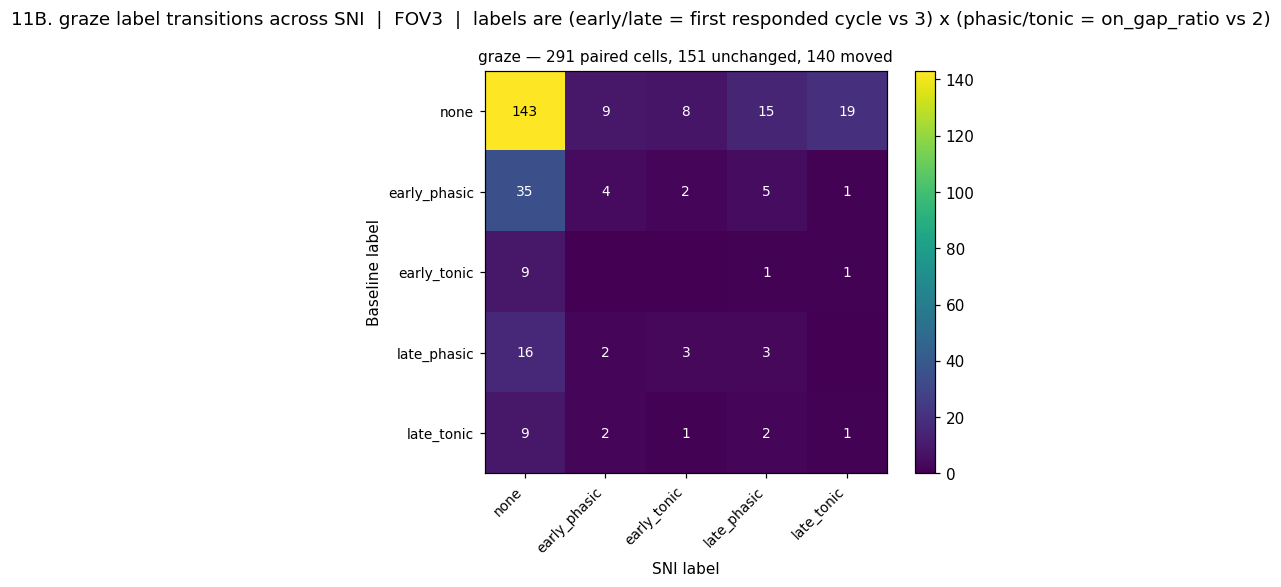


graze: 291 paired cells  |  151 unchanged (52%)  |  140 changed
    early_phasic -> none: 35
    none -> late_tonic: 19
    late_phasic -> none: 16
    none -> late_phasic: 15
    none -> early_phasic: 9
    late_tonic -> none: 9


,axis,Baseline,SNI,change
0,responded at all,97,79,-18
1,late (first cycle >= 4),39,48,9
2,phasic,71,43,-28


In [101]:
transition_B = {}
fig, axes = plt.subplots(1, max(len(PART_B), 1), squeeze=False,
                         figsize=(6.4 * max(len(PART_B), 1), 5.4))
for c, exp in enumerate(PART_B):
    M = None
    for fov in FOVS:
        shared, ia, ib = pair_indices(exp, fov)              # same pairing rule as §11A
        la = graze_table[("Baseline", exp)].label.to_numpy()[ia]
        lb = graze_table[("SNI", exp)].label.to_numpy()[ib]
        ct = pd.crosstab(pd.Series(la, name="Baseline"), pd.Series(lb, name="SNI"))
        M = ct if M is None else M.add(ct, fill_value=0)
    M = M.reindex(index=list(GRAZE_LABELS), columns=list(GRAZE_LABELS),
                  fill_value=0).fillna(0).astype(int)
    transition_B[exp] = M

    ax = axes[0][c]
    im = ax.imshow(M.values, cmap="viridis")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            if M.values[i, j]:
                ax.text(j, i, str(M.values[i, j]), ha="center", va="center", fontsize=9,
                        color="white" if M.values[i, j] < M.values.max() * 0.6 else "black")
    ax.set_xticks(range(M.shape[1]), M.columns, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(M.shape[0]), M.index, fontsize=9)
    ax.set_xlabel("SNI label"); ax.set_ylabel("Baseline label")
    same = int(sum(M.loc[l, l] for l in M.index if l in M.columns))
    total = int(M.values.sum())
    ax.set_title(f"{exp} — {total} paired cells, {same} unchanged, {total - same} moved", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.suptitle(f"11B. graze label transitions across SNI  |  {', '.join(FOVS)}  |  labels are "
             f"(early/late = first responded cycle vs {EARLY_MAX_TRIAL}) x "
             f"(phasic/tonic = on_gap_ratio vs {ON_GAP_HIGH:g})")
fig.tight_layout()
save_fig(fig, "11B_graze_transitions")
plt.show()

for exp in PART_B:
    M = transition_B[exp]
    total = int(M.values.sum())
    same = int(sum(M.loc[l, l] for l in M.index if l in M.columns))
    print(f"\n{exp}: {total} paired cells  |  {same} unchanged "
          f"({100 * same / max(total, 1):.0f}%)  |  {total - same} changed")
    moves = sorted(((int(M.values[i, j]), M.index[i], M.columns[j])
                    for i in range(M.shape[0]) for j in range(M.shape[1])
                    if M.index[i] != M.columns[j] and M.values[i, j]), reverse=True)
    for n, a, b in moves[:6]:
        print(f"    {a} -> {b}: {n}")

    # The two label axes move independently, so read them separately as well as jointly: a cell
    # can keep its timing and flip its shape, and the joint table hides that.
    lab_b = M.sum(axis=1)
    lab_s = M.sum(axis=0)
    axis_rows = []
    for name, keys in (("responded at all", [l for l in GRAZE_LABELS if l != "none"]),
                       ("late (first cycle >= %d)" % (EARLY_MAX_TRIAL + 1),
                        [l for l in GRAZE_LABELS if l.startswith("late")]),
                       ("phasic", [l for l in GRAZE_LABELS if l.endswith("phasic")])):
        axis_rows.append({"axis": name, "Baseline": int(lab_b[keys].sum()),
                          "SNI": int(lab_s[keys].sum()),
                          "change": int(lab_s[keys].sum() - lab_b[keys].sum())})
    display(pd.DataFrame(axis_rows))

## 12B. Spectrum (graze) — per-cycle bands and a constrained-shift weight

Same figure as §12A with two changes.

**A band per ON window instead of one long bar.** The 12 cycles are the structure of this protocol;
a single red bar from 5 s to 125 s draws the thing that made the graze analysis unreadable in the
first place.

**A weight that measures the right window against the right null.** `real` is the detected AUC
summed over **all 12 ON windows** rather than over the 5–125 s block — the block is half gap, so a
cell that fires only during grazes was being scored across 60 s of its own silence — and the
surrogate uses the **constrained** shift from §8b.

The cell prints both changes applied one at a time, against the original §12a definition, so the
gain is attributed rather than asserted:

| variant | window scored | offsets |
|---|---|---|
| `§12a` | whole 5–125 s block | unconstrained |
| middle | ON windows only | unconstrained |
| `§12B` | ON windows only | **constrained** |

> **Read the size of the gain honestly.** Both changes help and both are small. Scoring the ON
> windows mostly moves the median; constraining the offsets mostly moves the tail — the count of
> cells no surrogate ever beat — and on the SNI recording it is the only one of the two that does
> anything. The ceiling is set by the **duty cycle**, not by the offset pool: the ON windows are
> half of every cycle, so even a maximally wrong shift still drops about half the response back
> inside an ON window. No choice of offsets undoes that. graze has less power than clip here; the
> constraint narrows the gap without closing it.

Fewer surrogates are available for graze than for clip (`SPECTRUM_N_SURROGATES_GRAZE`), because the
constraint shrinks the offset pool and §8b's guard refuses to resample a small pool 200 times. That
costs p-resolution: the best attainable p is 1/(N+1), which is the ceiling the weights pile up at.

12B. graze weight — 60 surrogates, p floor = 1/61 so the weight ceiling is 1.785. 'at_p_floor' = cells no surrogate ever beat.


,condition,variant,cells_with_events,weight>0,median_weight_of_event_cells,mean_weight_of_event_cells,at_p_floor
0,Baseline,"§12a: whole 5–125 s block, unconstrained",122,117,0.370,0.530,1
1,Baseline,"ON windows only, unconstrained",122,97,0.474,0.579,4
2,Baseline,"§12B: ON windows only, CONSTRAINED",122,97,0.484,0.600,8
3,SNI,"§12a: whole 5–125 s block, unconstrained",130,126,0.655,0.739,7
4,SNI,"ON windows only, unconstrained",130,94,0.655,0.658,7
5,SNI,"§12B: ON windows only, CONSTRAINED",130,94,0.706,0.695,11


Reading this table
  The two changes do different jobs, and neither is dominant on its own. Scoring the ON windows
  rather than the whole block mostly moves the MEDIAN (the block is half gap, so a cell firing
  only during grazes was being scored across 60 s of silence). Constraining the offsets mostly
  moves the TAIL — `at_p_floor`, the cells no surrogate ever beat — and on the SNI recording it
  is the only one of the two that does anything at all.

  Both gains are real and both are small. The ceiling is set by the DUTY CYCLE, not by the offset
  pool: the ON windows are half of every cycle, so even a maximally wrong shift still drops about
  half the response back inside an ON window. No choice of offsets undoes that. The honest
  statement is that graze has less power than clip here and the constraint narrows the gap
  without closing it — not that it fixed the problem.


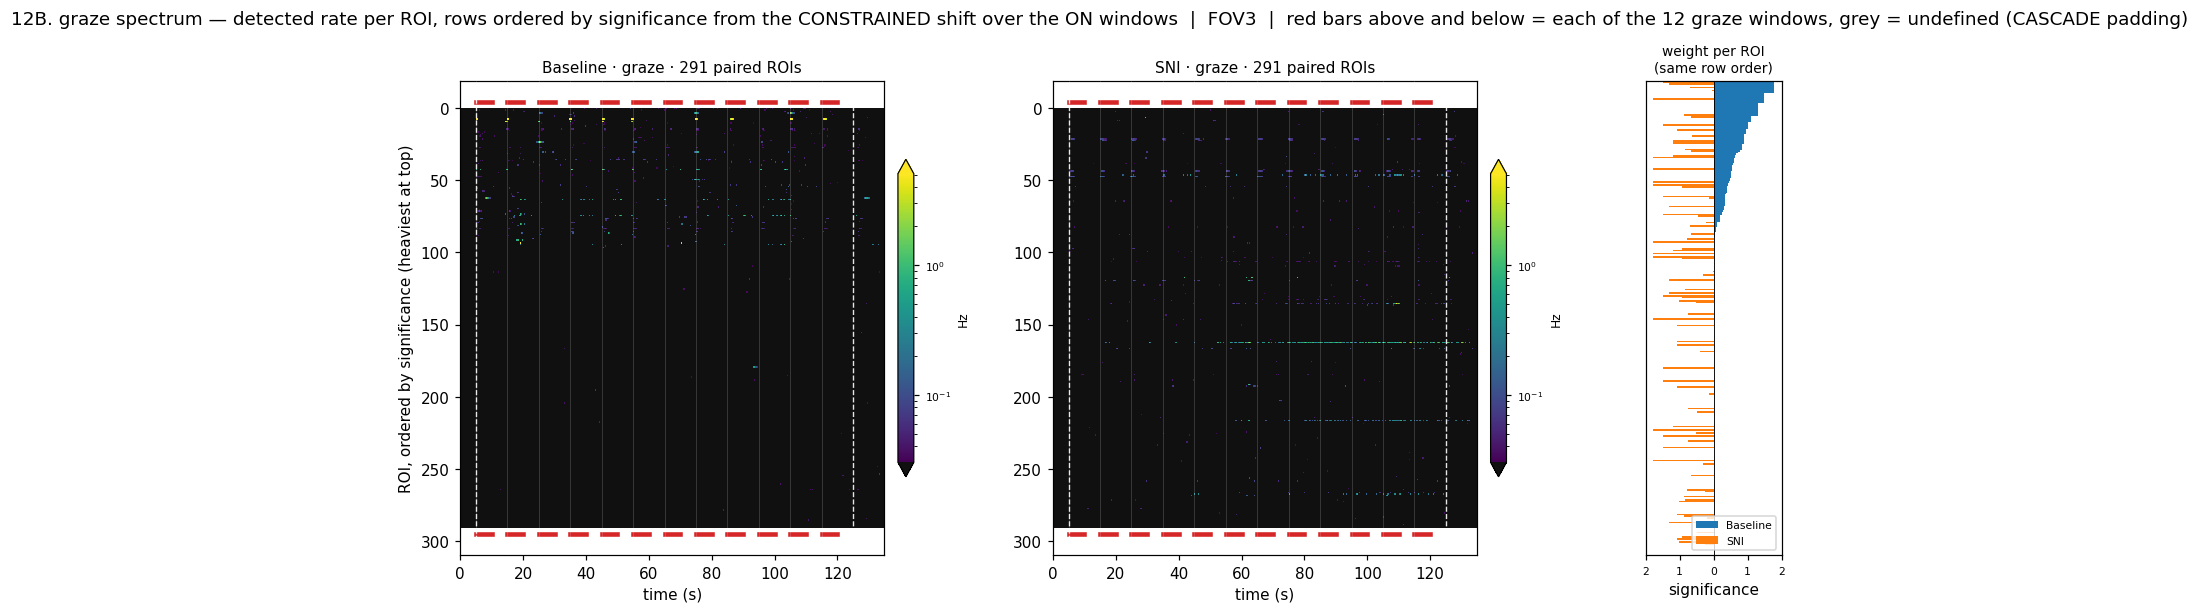

graze: 291 paired ROIs  |  weight>0  Baseline 97, SNI 79  |  gained 69, lost 78  |  top-10 Baseline ROI ids [226, 82, 85, 105, 219, 149, 16, 282, 107, 101]


In [102]:
def graze_weight(rec: dict, exp: str, window: str, constrained: bool, n_surrogates: int,
                 seed: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """Per-ROI -log10(p) for graze, against a circular-shift null. Returns (real AUC, weight).

    Two independent choices, so they can be varied one at a time:
      window     "on"    -> detected AUC summed over the 12 ON windows (§12B)
                 "block" -> detected AUC over the whole 5–125 s stimulus block (what §12a did,
                            which counts the gaps as stimulus)
      constrained         -> whether offsets near a whole cycle are excluded (§8b)
    """
    rng = np.random.default_rng(seed)
    t, edges = rec["time_s"], rec["edges"]
    m = ((rec["kind_of_t"] == "on") if window == "on"
         else (t >= edges[1]) & (t < edges[-2]))
    offsets = (checked_offsets(rec, exp, n_surrogates, tag="§12B ") if constrained else None)

    score = lambda D: np.trapezoid(np.nan_to_num(D[m], nan=0.0), t[m], axis=0)
    real = score(rec["det"]["detected"])
    beaten = np.zeros(rec["rate"].shape[1], dtype=int)
    for _ in range(n_surrogates):
        sur = detect_events(circular_shift(rec["rate"], rng, offsets), t, edges)["detected"]
        beaten += score(sur) >= real
    return real, -np.log10((1 + beaten) / (1 + n_surrogates))


# Vary one thing at a time, so the gain is attributed rather than asserted.
VARIANTS = (("block", False, "§12a: whole 5–125 s block, unconstrained"),
            ("on",    False, "ON windows only, unconstrained"),
            ("on",    True,  "§12B: ON windows only, CONSTRAINED"))
ceiling = -np.log10(1 / (SPECTRUM_N_SURROGATES_GRAZE + 1))
weight_compare = []
for exp in PART_B:
    for cond in CONDITIONS:
        rec = runs[(cond, exp, FOV0)]
        has = rec["det"]["events"].any(axis=0)
        for window, constrained, name in VARIANTS:
            _, w = graze_weight(rec, exp, window, constrained, SPECTRUM_N_SURROGATES_GRAZE)
            if window == "on" and constrained:
                rec["weight"] = w
            weight_compare.append({
                "condition": cond, "variant": name, "cells_with_events": int(has.sum()),
                "weight>0": int((w > 0).sum()),
                "median_weight_of_event_cells": round(float(np.median(w[has])), 3),
                "mean_weight_of_event_cells": round(float(np.mean(w[has])), 3),
                "at_p_floor": int((w >= ceiling - 1e-9).sum())})

print(f"12B. graze weight — {SPECTRUM_N_SURROGATES_GRAZE} surrogates, p floor = "
      f"1/{SPECTRUM_N_SURROGATES_GRAZE + 1} so the weight ceiling is {ceiling:.3f}. "
      "'at_p_floor' = cells no surrogate ever beat.")
with pd.option_context("display.width", 240, "display.max_columns", None):
    display(pd.DataFrame(weight_compare))
print("""Reading this table
  The two changes do different jobs, and neither is dominant on its own. Scoring the ON windows
  rather than the whole block mostly moves the MEDIAN (the block is half gap, so a cell firing
  only during grazes was being scored across 60 s of silence). Constraining the offsets mostly
  moves the TAIL — `at_p_floor`, the cells no surrogate ever beat — and on the SNI recording it
  is the only one of the two that does anything at all.

  Both gains are real and both are small. The ceiling is set by the DUTY CYCLE, not by the offset
  pool: the ON windows are half of every cycle, so even a maximally wrong shift still drops about
  half the response back inside an ON window. No choice of offsets undoes that. The honest
  statement is that graze has less power than clip here and the constraint narrows the gap
  without closing it — not that it fixed the problem.""")

# ── The spectrum ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15.5, 5.6 * max(len(PART_B), 1)))
grid = fig.add_gridspec(max(len(PART_B), 1), 3, width_ratios=[1, 1, 0.30], hspace=0.38, wspace=0.40)

for r, exp in enumerate(PART_B):
    shared, ia, ib = pair_indices(exp, FOV0)
    base, sni = runs[("Baseline", exp, FOV0)], runs[("SNI", exp, FOV0)]
    order = np.argsort(-base["weight"][ia])          # one order for both panels, as in §12A

    pooled_vals = np.concatenate([base["det"]["detected"][:, ia].ravel(),
                                  sni["det"]["detected"][:, ib].ravel()])
    nonzero = pooled_vals[np.isfinite(pooled_vals) & (pooled_vals > 0)]
    vmin = float(min(base["det"]["thr"].min(), sni["det"]["thr"].min()))
    vmax = float(np.percentile(nonzero, 99)) if nonzero.size else 1.0
    norm = LogNorm(vmin=vmin, vmax=max(vmax, vmin * 10))

    for c, (rec, idx, name) in enumerate(((base, ia, "Baseline"), (sni, ib, "SNI"))):
        ax = fig.add_subplot(grid[r, c])
        D = rec["det"]["detected"][:, idx][:, order].T
        M = np.ma.masked_invalid(np.where(D > 0, D, vmin * 0.1))   # 0 -> set_under, NaN -> set_bad
        t = rec["time_s"]
        im = ax.imshow(M, aspect="auto", cmap=spectrum_cmap, norm=norm,
                       extent=[t[0], t[-1], len(shared), 0], interpolation="nearest")
        # One marker per ON window instead of a single 120 s bar: the 12 cycles are the structure
        # of this protocol and a continuous bar hides them. The markers stay in the MARGIN and
        # the in-plot guides are hairlines — a shaded band across the data tints the heatmap and
        # costs exactly the contrast the figure exists to show.
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            ax.plot([x0, x1], [-len(shared) * 0.014] * 2, lw=3, color="tab:red", clip_on=False)
            ax.plot([x0, x1], [len(shared) * 1.014] * 2, lw=3, color="tab:red", clip_on=False)
            ax.axvline(x0, color="white", lw=0.35, alpha=0.30, zorder=3)
        for edge in (rec["edges"][1], rec["edges"][-2]):     # only pre|cycles and cycles|post
            ax.axvline(edge, color="white", lw=0.9, ls="--", alpha=0.9)
        ax.set_xlabel("time (s)")
        ax.set_ylabel(f"ROI, ordered by {SPECTRUM_WEIGHT} (heaviest at top)" if c == 0 else "")
        ax.set_title(f"{name} · {exp} · {len(shared)} paired ROIs", fontsize=10)
        cb = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, extend="both")
        cb.set_label("Hz", fontsize=8)
        cb.ax.tick_params(labelsize=7)

    ax_w = fig.add_subplot(grid[r, 2])
    rows = np.arange(len(shared))
    ax_w.barh(rows, base["weight"][ia][order], height=1.0, color=COND_COLOR["Baseline"],
              label="Baseline")
    ax_w.barh(rows, -sni["weight"][ib][order], height=1.0, color=COND_COLOR["SNI"], label="SNI")
    ax_w.axvline(0, color="k", lw=0.6)
    ax_w.set_ylim(len(shared), 0)
    ax_w.set_yticks([])
    ax_w.set_xlabel(SPECTRUM_WEIGHT)
    ax_w.set_title("weight per ROI\n(same row order)", fontsize=9)
    ax_w.legend(fontsize=7, loc="lower right")
    ticks = ax_w.get_xticks()
    ax_w.set_xticks(ticks, [f"{abs(v):g}" for v in ticks], fontsize=7)

fig.suptitle(f"12B. graze spectrum — detected rate per ROI, rows ordered by {SPECTRUM_WEIGHT} "
             f"from the CONSTRAINED shift over the ON windows  |  {FOV0}  |  red bars above and "
             f"below = each of the {GRAZE_N_TRIALS} graze windows, grey = undefined (CASCADE "
             f"padding)", y=0.995)
save_fig(fig, "12B_graze_spectrum")
plt.show()

for exp in PART_B:
    shared, ia, ib = pair_indices(exp, FOV0)
    wb = runs[("Baseline", exp, FOV0)]["weight"][ia]
    ws = runs[("SNI", exp, FOV0)]["weight"][ib]
    print(f"{exp}: {len(shared)} paired ROIs  |  weight>0  Baseline {int((wb > 0).sum())}, "
          f"SNI {int((ws > 0).sum())}  |  gained {int((ws > wb).sum())}, lost {int((ws < wb).sum())}"
          f"  |  top-10 Baseline ROI ids {shared[np.argsort(-wb)[:10]].tolist()}")

## 12d. Row index → ROI id

Claims are arriving as row ranges — "rows 150–250" — but a row number is a property of a *figure*,
not of a cell. The two protocols no longer even share a figure: a clip row indexes §12A, a graze row
indexes §12B, and §12Ab / §12Ac each re-sort a *different* surviving subset. The same row number
points at different cells in each, and the mapping moves again whenever the weight is recomputed.

This section emits, per experiment, one row per paired ROI with its position in its own spectrum
alongside both days' weights and both days' labels, then resolves the ranges in `CLAIM_ROWS` into
explicit ROI ids. **Every section below takes ROI ids** — none of them names a row.

| column | is |
|---|---|
| `row_spectrum` | position in §12A (clip) or §12B (graze) |
| `row_12b`, `row_12c` | position in the §12Ab / §12Ac filtered figures — **clip only**, `<NA>` for graze |
| `weight_baseline` / `weight_sni` | the weight each spectrum was drawn with, no new surrogates |
| `label_baseline` / `label_sni` | §9A bit-string for clip, §9B phenotype for graze |

> **The tied-zero block — check this before reading any row claim.** Cells with no detected event
> in the scored window score exactly 0, and `np.argsort` orders that whole block arbitrarily. A row
> range falling inside it **does not name a reproducible set of cells**: re-run with a different
> surrogate seed and the membership changes while the figure looks identical. The diagnostic below
> prints where the block starts and how much of each claim range lands in it.

Two provenance strings are also defined here, `SNI_VARIANT` and `STIM_TERRITORY`, and printed in
every caption from §12d to §15. Neither is recoverable from these files — see the closing section.

In [103]:
# Provenance strings for §12d–§15. Neither is inferable from the traces, so both are typed in
# here and printed in every caption below rather than guessed from file names.
SNI_VARIANT    = "unspecified"   # e.g. "tibial + common peroneal ligated, sural spared"
STIM_TERRITORY = "unspecified"   # e.g. "lateral hindpaw, sural territory"

# Row ranges to resolve, per experiment, as (first_row, last_row) inclusive. Edit freely.
CLAIM_ROWS = {"graze": [(75, 125), (150, 250)], "clip": []}


def provenance(extra: str = "") -> str:
    """The caption suffix carried by every figure from here on."""
    return (f"SNI variant: {SNI_VARIANT}  |  stimulated territory: {STIM_TERRITORY}"
            + (f"  |  {extra}" if extra else ""))


def spectrum_row_map(exp: str, fov: str | None = None) -> pd.DataFrame:
    """One row per paired ROI: where it sits in its spectrum figure, its weight and its label.

    The orderings are re-derived here from the same expressions the figures use, not read back
    out of their loop variables, so this table stays correct if a figure is re-run. Which
    figure `row_spectrum` refers to depends on the protocol — §12A for clip, §12B for graze —
    and the §12Ab / §12Ac filters exist only for clip, so those columns are <NA> for graze.
    """
    fov = FOVS[0] if fov is None else fov
    shared, ia, ib = pair_indices(exp, fov)              # same pairing as §11A / §11B
    base, sni = runs[("Baseline", exp, fov)], runs[("SNI", exp, fov)]
    wb, ws = base["weight"][ia], sni["weight"][ib]       # the weights the spectrum was drawn with
    n = len(shared)

    def rows_from(order: np.ndarray, kept: np.ndarray | None = None) -> np.ndarray:
        """Invert a plotted row order into a per-ROI row index; NaN for ROIs not drawn."""
        out = np.full(n, np.nan)
        out[order] = np.arange(len(order))
        if kept is not None:
            out[~kept] = np.nan
        return out

    # Every paired ROI, ordered by Baseline weight, heaviest at row 0 — §12A and §12B alike.
    row_spectrum = rows_from(np.argsort(-wb))
    row_12b = row_12c = np.full(n, np.nan)

    if exp in PART_A:
        # §12Ab — drop only cells quiet on BOTH days, each day cut at its own percentile.
        cut_b, cut_s = quiet_cutoff(wb), quiet_cutoff(ws)
        keep_b = ~((wb <= cut_b) & (ws <= cut_s))
        kept_b = np.flatnonzero(keep_b)
        row_12b = rows_from(kept_b[np.argsort(-wb[kept_b])], keep_b)

        # §12Ac — drop on the percentile-rank sum, with the late-responder guard.
        pr_b, pr_s = percentile_rank(wb), percentile_rank(ws)
        drop = (pr_b + pr_s) < QUIET_PR_SUM
        if PROTECT_LATE_RESPONDERS:
            late_b = base["det"]["events"][base["kind_of_t"] != "pre"][:, ia].any(axis=0)
            late_s = sni["det"]["events"][sni["kind_of_t"] != "pre"][:, ib].any(axis=0)
            drop = drop & ~(late_b | late_s)
        keep_c = ~drop
        kept_c = np.flatnonzero(keep_c)
        row_12c = rows_from(kept_c[np.argsort(-wb[kept_c])], keep_c)

    out = pd.DataFrame({
        "row_spectrum": row_spectrum, "row_12b": row_12b, "row_12c": row_12c,
        "roi_id": shared,
        # + 0.0 turns -log10(1) = -0.0 into 0.0 so the tie test below reads cleanly.
        "weight_baseline": wb + 0.0, "weight_sni": ws + 0.0,
        "label_baseline": base["table"].label.to_numpy()[ia],
        "label_sni": sni["table"].label.to_numpy()[ib],
    })
    for c in ("row_spectrum", "row_12b", "row_12c"):
        out[c] = out[c].astype("Int64")                  # <NA> = not drawn in that figure
    return out.sort_values("row_spectrum", ignore_index=True)


def rois_for_rows(exp: str, lo: int, hi: int, index: str = "row_spectrum") -> np.ndarray:
    """ROI ids occupying rows lo..hi (inclusive) of one spectrum figure. The bridge every later
    section crosses: nothing downstream of here is allowed to name a row."""
    df = ROW_MAPS[exp]
    sel = df[index].notna() & (df[index] >= lo) & (df[index] <= hi)
    return df.loc[sel, "roi_id"].to_numpy()


ROW_MAPS = {exp: spectrum_row_map(exp) for exp in EXPERIMENTS}

for exp in EXPERIMENTS:
    df = ROW_MAPS[exp]
    part = "A (clip, §12A)" if exp in PART_A else "B (graze, §12B)"
    print(f"\n=== {exp} — {len(df)} paired ROIs, Part {part} " + "=" * 30)
    print(f"rows drawn:  spectrum {int(df.row_spectrum.notna().sum())}  |  §12Ab "
          f"{int(df.row_12b.notna().sum())}  |  §12Ac {int(df.row_12c.notna().sum())}"
          + ("   (the 12b/12c filters are Part A only)" if exp in PART_B else ""))

    # Tie diagnostic. Cells with no detected event in the scored window all score weight 0, so
    # np.argsort orders that whole block arbitrarily. A row range inside it names no stable set
    # of cells — re-run with a different surrogate seed and the membership changes while the
    # figure looks identical. Check this before reading any claim off a row number.
    tied = df.weight_baseline == 0.0
    if tied.any():
        first_tied = int(df.loc[tied, "row_spectrum"].min())
        print(f"! spectrum rows {first_tied}–{len(df) - 1} are all tied at weight_baseline = 0 "
              f"({int(tied.sum())} cells): their order within that block is arbitrary, so a row "
              f"range overlapping it does not name a reproducible set of cells.")

    for lo, hi in CLAIM_ROWS.get(exp, []):
        ids = rois_for_rows(exp, lo, hi)
        sub = df[df.row_spectrum.notna() & (df.row_spectrum >= lo) & (df.row_spectrum <= hi)]
        n_tied = int((sub.weight_baseline == 0.0).sum())
        print(f"\n--- {exp} spectrum rows {lo}–{hi} — {len(ids)} ROIs, {n_tied} in the tied block")
        if len(ids) == 0:
            continue
        print(f"    roi_ids: {ids.tolist()}")
        print("    labels Baseline -> SNI: " + ", ".join(
            f"{a}->{b} x{n}" for (a, b), n in
            sub.groupby(["label_baseline", "label_sni"]).size().sort_values(
                ascending=False).head(6).items()))
        with pd.option_context("display.width", 200, "display.max_columns", None):
            display(sub.head(12))

    if not CLAIM_ROWS.get(exp):
        print("no CLAIM_ROWS set for this experiment — head of the table:")
        with pd.option_context("display.width", 200, "display.max_columns", None):
            display(df.head(8))

print(f"\n{provenance()}")
print("Row numbers are figure-local, and the two protocols no longer share a figure: a clip row "
      "indexes §12A, a graze row indexes §12B, and inside the tied-zero block a cell has no fixed "
      "row at all. §13–§15 take ROI ids.")


=== graze — 291 paired ROIs, Part B (graze, §12B) ==============================
rows drawn:  spectrum 291  |  §12Ab 0  |  §12Ac 0   (the 12b/12c filters are Part A only)
! spectrum rows 97–290 are all tied at weight_baseline = 0 (194 cells): their order within that block is arbitrary, so a row range overlapping it does not name a reproducible set of cells.

--- graze spectrum rows 75–125 — 51 ROIs, 29 in the tied block
    roi_ids: [112, 1, 78, 75, 201, 207, 120, 188, 76, 152, 168, 5, 218, 47, 79, 251, 256, 138, 187, 186, 48, 261, 195, 271, 270, 196, 197, 288, 272, 199, 200, 177, 202, 269, 178, 198, 194, 287, 286, 285, 284, 281, 181, 189, 180, 280, 279, 191, 203, 289, 278]
    labels Baseline -> SNI: none->none x19, early_phasic->none x11, none->early_phasic x3, none->early_tonic x3, early_tonic->none x2, late_phasic->late_phasic x2


,row_spectrum,row_12b,row_12c,roi_id,weight_baseline,weight_sni,label_baseline,label_sni
75,75,<NA>,<NA>,112,0.322932,0.000000,early_tonic,none
76,76,<NA>,<NA>,1,0.322932,0.000000,early_phasic,none
77,77,<NA>,<NA>,78,0.308209,1.308209,late_phasic,late_phasic
78,78,<NA>,<NA>,75,0.308209,0.000000,early_phasic,none
79,79,<NA>,<NA>,201,0.308209,0.000000,early_phasic,none
80,80,<NA>,<NA>,207,0.266816,0.000000,early_phasic,none
81,81,<NA>,<NA>,120,0.241262,0.000000,early_tonic,none
82,82,<NA>,<NA>,188,0.241262,1.484300,late_phasic,early_tonic
83,83,<NA>,<NA>,76,0.194265,0.463111,early_phasic,late_phasic
84,84,<NA>,<NA>,152,0.194265,0.000000,early_phasic,none



--- graze spectrum rows 150–250 — 101 ROIs, 101 in the tied block
    roi_ids: [237, 267, 217, 252, 206, 266, 231, 209, 264, 263, 262, 210, 216, 260, 212, 213, 214, 257, 215, 255, 254, 253, 259, 175, 146, 173, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 49, 50, 53, 55, 56, 57, 58, 59, 60, 62, 63, 64, 65, 66, 67, 35, 68, 34, 32, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 20, 21, 22, 24, 25, 26, 27, 28, 29, 31, 33, 69, 70, 74, 136, 137, 139, 140, 141, 142, 145, 148, 150, 151, 153, 155, 156, 157, 159, 160, 161]
    labels Baseline -> SNI: none->none x82, none->late_tonic x9, none->early_phasic x4, none->early_tonic x3, none->late_phasic x3


,row_spectrum,row_12b,row_12c,roi_id,weight_baseline,weight_sni,label_baseline,label_sni
150,150,<NA>,<NA>,237,0.0,1.08636,none,late_phasic
151,151,<NA>,<NA>,267,0.0,0.00000,none,none
152,152,<NA>,<NA>,217,0.0,0.00000,none,none
153,153,<NA>,<NA>,252,0.0,0.00000,none,none
154,154,<NA>,<NA>,206,0.0,0.00000,none,none
155,155,<NA>,<NA>,266,0.0,0.00000,none,none
156,156,<NA>,<NA>,231,0.0,0.00000,none,none
157,157,<NA>,<NA>,209,0.0,0.00000,none,none
158,158,<NA>,<NA>,264,0.0,0.00000,none,none
159,159,<NA>,<NA>,263,0.0,0.00000,none,none



=== clip — 291 paired ROIs, Part A (clip, §12A) ==============================
rows drawn:  spectrum 291  |  §12Ab 93  |  §12Ac 291
! spectrum rows 87–290 are all tied at weight_baseline = 0 (204 cells): their order within that block is arbitrary, so a row range overlapping it does not name a reproducible set of cells.
no CLAIM_ROWS set for this experiment — head of the table:


,row_spectrum,row_12b,row_12c,roi_id,weight_baseline,weight_sni,label_baseline,label_sni
0,0,1,0,126,2.303196,0.000000,011,000
1,1,2,1,218,2.303196,1.127105,011,010
2,2,0,2,5,2.303196,0.000000,011,000
3,3,3,3,1,2.002166,0.000000,011,000
4,4,6,4,137,2.002166,0.000000,011,100
5,5,7,5,83,2.002166,0.000000,010,000
6,6,5,6,78,2.002166,0.000000,011,000
7,7,8,7,36,2.002166,0.000000,011,000



SNI variant: unspecified  |  stimulated territory: unspecified
Row numbers are figure-local, and the two protocols no longer share a figure: a clip row indexes §12A, a graze row indexes §12B, and inside the tied-zero block a cell has no fixed row at all. §13–§15 take ROI ids.


## 13. Response across cycles — the test of claim 1

**Part B.** "The response only appears after the 4th graze." §9B gives every cell a `first_trial`,
which answers the claim per cell; this section asks whether the *population* shifts across cycles.

- **13a** — fraction of paired ROIs responding, per cycle, one line per condition. The direct test.
  The gap window rides alongside as a control panel.
- **13b** — the same, split by whether the cell responded in any Baseline ON window, so the
  "previously low-response" group is plotted apart from the rest.

The trend is tested by shuffling the **cycle order within each cell**. That preserves how many
cycles each cell responded to and destroys only the order, so a rho beyond the null means the
*ordering* carries information — not merely that some cells respond more than others.

> **13b's right panel is half tautology.** The split is "responded in any Baseline ON window", so a
> Baseline non-responder is silent in every Baseline cycle *by definition*. That line is 0 at every
> cycle by construction, drawn dotted to mark it. Only the SNI line in that panel is a measurement.

> **Mandatory caveat, repeated in the cell output.** A monotone increase across cycles is equally
> consistent with sensitisation, progressive tissue damage, photobleaching, and drifting anaesthetic
> depth. This shows **that** the trend exists; it cannot identify the cause. The premise that every
> graze is an **identical operation** — same force, same contact area, same skin site — is an
> assumption, not something these traces record, and should be stated as one. If the graze got
> firmer as the session went on, the same curve appears with no change in any neuron.

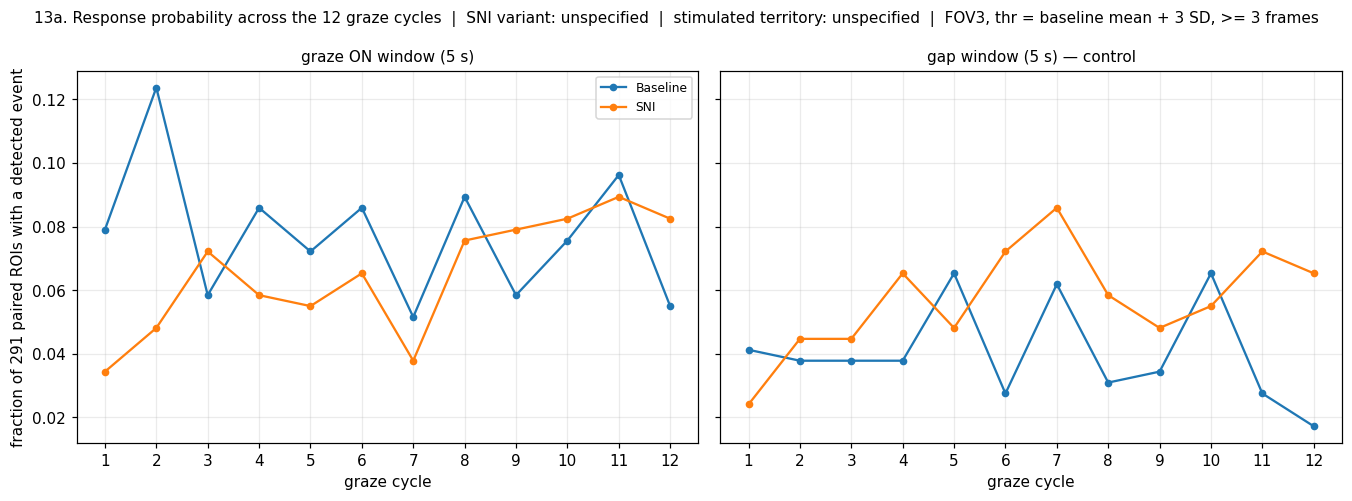

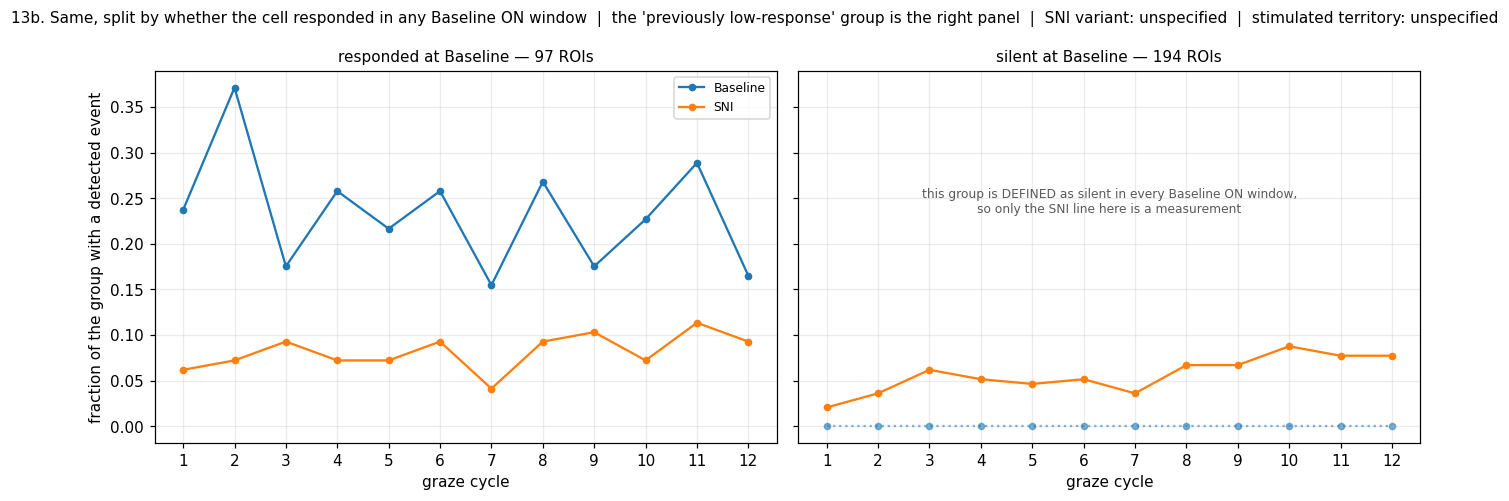


graze: Spearman(cycle index, responder count), null = 2000 within-cell order shuffles (each cell keeps its own number of responding cycles)



,condition,window,group,n_cells,count_first3,count_last3,rho,null_95%,p,note
0,Baseline,graze ON,all,291,76,66,-0.225,"[-0.59, +0.58]",0.4720,
1,Baseline,graze ON,responded at Baseline,97,76,66,-0.225,"[-0.59, +0.59]",0.4835,
2,Baseline,graze ON,silent at Baseline,194,0,0,NaN,"[+nan, +nan]",,no responses to order — this group is defined as silent ...
3,Baseline,gap (control),all,291,34,32,-0.431,"[-0.57, +0.59]",0.1550,
4,SNI,graze ON,all,291,45,74,0.834,"[-0.56, +0.62]",0.0030,
5,SNI,graze ON,responded at Baseline,97,22,27,0.537,"[-0.58, +0.58]",0.0725,
6,SNI,graze ON,silent at Baseline,194,23,47,0.835,"[-0.58, +0.56]",0.0005,
7,SNI,gap (control),all,291,33,56,0.592,"[-0.57, +0.57]",0.0405,



CAVEAT — what a cycle trend can and cannot mean
    A monotone increase across cycles is equally consistent with sensitisation, progressive
    tissue damage, photobleaching, and drifting anaesthetic depth. This analysis shows THAT a
    trend exists and that it is larger than shuffling the cycle order within each cell; it
    cannot identify the cause. Nothing here distinguishes a mechanism.

    "The response only appears from the 4th graze onwards" also assumes an IDENTICAL operation
    on every cycle — same force, same contact area, same skin site, same inter-cycle state. That
    is an ASSUMPTION, not something these traces record. If the experimenter's graze got firmer,
    or the skin sensitised locally, the same curve appears with no change in any neuron.

    The gap-window control panel is the one discriminator available: a trend confined to the ON
    window is at least stimulus-locked, while a trend in both points at drift affecting the whole
    recording. It does not se

In [104]:
TRIAL_N_PERM = 2000     # cycle-order shuffles for the null below
TRIAL_SEED = 0

CYCLE_IDX = np.arange(1, GRAZE_N_TRIALS + 1)


def responder_fraction(sub: pd.DataFrame, column: str = "responded") -> np.ndarray:
    """Fraction of the cells in `sub` responding, per cycle, in cycle order."""
    return sub.groupby("cycle")[column].mean().reindex(CYCLE_IDX).to_numpy(float)


def order_shuffle_test(sub: pd.DataFrame, column: str = "responded") -> dict:
    """Spearman rho between cycle index and per-cycle responder count, against a null that
    shuffles the cycle ORDER within each cell.

    The shuffle keeps how many cycles each cell responded to and destroys only when those
    responses happened, so the null isolates the ordering — not the overall response level.
    """
    R = (sub.pivot_table(index="roi_id", columns="cycle", values=column, aggfunc="max")
            .reindex(columns=CYCLE_IDX).to_numpy(float))
    R = np.nan_to_num(R, nan=0.0)
    counts = R.sum(axis=0)
    rho = spearmanr(CYCLE_IDX, counts).statistic if np.ptp(counts) > 0 else np.nan

    rng = np.random.default_rng(TRIAL_SEED)
    null = np.full(TRIAL_N_PERM, np.nan)
    for k in range(TRIAL_N_PERM):
        shuffled = np.take_along_axis(R, rng.random(R.shape).argsort(axis=1), axis=1)
        c = shuffled.sum(axis=0)
        if np.ptp(c) > 0:
            null[k] = spearmanr(CYCLE_IDX, c).statistic
    null = null[np.isfinite(null)]
    p = float((np.abs(null) >= abs(rho)).mean()) if (null.size and np.isfinite(rho)) else np.nan
    return {"n_cells": int(R.shape[0]), "counts": counts, "rho": rho, "null": null, "p": p,
            "null_lo": float(np.percentile(null, 2.5)) if null.size else np.nan,
            "null_hi": float(np.percentile(null, 97.5)) if null.size else np.nan}


for exp in PART_B:
    # Paired ROIs only, and the Baseline-responder split comes from the §9B summary by ROI id.
    shared, _, _ = pair_indices(exp, FOV0)
    trials = pd.concat([graze_cycles[(cond, exp)] for cond in CONDITIONS], ignore_index=True)
    trials = trials[trials.roi_id.isin(shared)].copy()
    base_resp = graze_table[("Baseline", exp)].set_index("roi_id").n_trials_responded
    trials["baseline_responder"] = trials.roi_id.map(base_resp) > 0
    n_paired = trials.roi_id.nunique()

    # ── FIGURE 13a — response probability across cycles ────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6), sharey=True)
    for ax, (column, title) in zip(axes, [("responded", f"graze ON window ({GRAZE_ON_S:g} s)"),
                                          ("responded_gap", f"gap window ({GRAZE_ON_S:g} s) — "
                                                            "control")]):
        for cond in CONDITIONS:
            ax.plot(CYCLE_IDX, responder_fraction(trials[trials.condition == cond], column),
                    marker="o", ms=4, color=COND_COLOR[cond], label=cond)
        ax.set_xticks(CYCLE_IDX)
        ax.set_xlabel("graze cycle")
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.25)
    axes[0].set_ylabel(f"fraction of {n_paired} paired ROIs with a detected event")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"13a. Response probability across the {GRAZE_N_TRIALS} graze cycles  |  "
                 + provenance(f"{FOV0}, thr = baseline mean + {DETECT_K:g} SD, "
                              f">= {N_CONSEC} frames"), fontsize=10)
    fig.tight_layout()
    save_fig(fig, "13a_cycle_response")
    plt.show()

    # ── FIGURE 13b — split by Baseline responder status ────────────────────────
    # The split is "responded in any Baseline ON window", so a Baseline non-responder cannot
    # respond in ANY Baseline cycle: that line is 0 everywhere by construction, not by
    # measurement. Only the SNI line in the right panel carries information — it is the
    # "previously silent cells now respond" claim.
    fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6), sharey=True)
    for ax, flag in zip(axes, [True, False]):
        n_group = 0
        for cond in CONDITIONS:
            sub = trials[(trials.condition == cond) & (trials.baseline_responder == flag)]
            n_group = sub.roi_id.nunique()
            if n_group == 0:
                continue
            tautology = (not flag) and cond == "Baseline"
            ax.plot(CYCLE_IDX, responder_fraction(sub), marker="o", ms=4, color=COND_COLOR[cond],
                    ls=":" if tautology else "-", alpha=0.55 if tautology else 1.0,
                    label=cond + (" — 0 by construction" if tautology else ""))
        ax.set_xticks(CYCLE_IDX)
        ax.set_xlabel("graze cycle")
        ax.set_title(("responded at Baseline" if flag else "silent at Baseline")
                     + f" — {n_group} ROIs", fontsize=10)
        ax.grid(alpha=0.25)
        if not flag:
            ax.text(0.5, 0.62, "this group is DEFINED as silent in every Baseline ON window,\n"
                               "so only the SNI line here is a measurement",
                    transform=ax.transAxes, ha="center", fontsize=8, color="0.35")
    axes[0].set_ylabel("fraction of the group with a detected event")
    axes[0].legend(fontsize=8)
    fig.suptitle("13b. Same, split by whether the cell responded in any Baseline ON window  |  "
                 "the 'previously low-response' group is the right panel  |  " + provenance(),
                 fontsize=10)
    fig.tight_layout()
    save_fig(fig, "13b_cycle_response_split")
    plt.show()

    # ── TEST — is the cycle trend real? ────────────────────────────────────────
    print(f"\n{exp}: Spearman(cycle index, responder count), null = {TRIAL_N_PERM} within-cell "
          "order shuffles (each cell keeps its own number of responding cycles)\n")
    rows = []
    for cond in CONDITIONS:
        for column, what in (("responded", "graze ON"), ("responded_gap", "gap (control)")):
            for flag, group in ((None, "all"), (True, "responded at Baseline"),
                                (False, "silent at Baseline")):
                sub = trials[trials.condition == cond]
                if flag is not None:
                    sub = sub[sub.baseline_responder == flag]
                    if column != "responded":
                        continue
                if sub.empty:
                    continue
                res = order_shuffle_test(sub, column)
                rows.append({"condition": cond, "window": what, "group": group,
                             "n_cells": res["n_cells"],
                             "count_first3": int(res["counts"][:3].sum()),
                             "count_last3": int(res["counts"][-3:].sum()),
                             "rho": round(float(res["rho"]), 3),
                             "null_95%": f"[{res['null_lo']:+.2f}, {res['null_hi']:+.2f}]",
                             "p": ("" if not np.isfinite(res["p"]) else
                                   f"<{1 / TRIAL_N_PERM:.4f}" if res["p"] == 0
                                   else f"{res['p']:.4f}"),
                             "note": ("no responses to order — this group is defined as silent "
                                      "at Baseline" if not np.isfinite(res["rho"]) else "")})
    with pd.option_context("display.width", 220, "display.max_columns", None,
                           "display.max_colwidth", 60):
        display(pd.DataFrame(rows))

print("""
CAVEAT — what a cycle trend can and cannot mean
    A monotone increase across cycles is equally consistent with sensitisation, progressive
    tissue damage, photobleaching, and drifting anaesthetic depth. This analysis shows THAT a
    trend exists and that it is larger than shuffling the cycle order within each cell; it
    cannot identify the cause. Nothing here distinguishes a mechanism.

    "The response only appears from the 4th graze onwards" also assumes an IDENTICAL operation
    on every cycle — same force, same contact area, same skin site, same inter-cycle state. That
    is an ASSUMPTION, not something these traces record. If the experimenter's graze got firmer,
    or the skin sensitised locally, the same curve appears with no change in any neuron.

    The gap-window control panel is the one discriminator available: a trend confined to the ON
    window is at least stimulus-locked, while a trend in both points at drift affecting the whole
    recording. It does not separate damage from sensitisation either way.""")

## 14. Clip phenotype groups — tests claims 3 and 4

Claim 3 names three groups that already exist as §9 labels, so it needs counting, not a new method:

| label | phenotype |
|---|---|
| `010` | during only |
| `011` | during + chronic |
| `001` | chronic only |

- **a** — how many paired cells sit in each, with the ROI ids printed. This either confirms claim 3
  or does not.
- **b** — the §11 transition matrix restricted to those three starting labels. Claim 4 is the
  statement that most of them land in `000` or lose the third bit; the printout gives both
  percentages per starting label.
- **c** — the chronic bit on its own: how many Baseline `S3 = 1` cells still have it after SNI, and
  for those that do, the latency from withdrawal to the first detected S3 event, before against
  after. A shift to later latency is the testable half of "delayed".

Unlike graze, these groups sit above the §8b null — Baseline clip S2 ran +44.2 and S3 +26.2 cells
over chance — so the counts here are interpretable in a way the graze segments' are not.

> **"Delayed beyond the recording" is not testable here** and is labelled as such in the output. A
> cell that lost the chronic bit and a cell whose chronic response begins after the camera stopped
> are indistinguishable in these data. The post-withdrawal window is **39.7 s at Baseline but only
> 31.9 s after SNI**, so the latency comparison is run twice — over each day's full window, and
> over the common span — with both window lengths printed beside the result. Some fraction of the
> lost bits can be nothing but the shorter recording.

> **The surviving group is small and self-selected.** The latency shift describes the cells whose
> chronic response survived SNI. It says nothing about the ones that did not, and it is not a
> random sample of anything.

a) Baseline clip phenotype groups — 291 paired ROIs, FOV3

  010  during only         24 cells (8% of paired)
        roi_ids: [2, 4, 21, 27, 30, 37, 43, 56, 65, 79, 83, 97, 128, 143, 163, 177, 222, 224, 226, 247, 252, 269, 279, 281]
  011  during + chronic    56 cells (19% of paired)
        roi_ids: [1, 5, 18, 25, 35, 36, 39, 40, 42, 47, 52, 73, 76, 78, 84, 86, 87, 88, 99, 100, 101, 102, 103, 105, 110, 112, 113, 119, 120, 126, 137, 138, 144, 151, 184, 188, 197, 200, 201, 204, 207, 208, 209, 218, 219, 231, 242, 243, 244, 246, 250, 251, 256, 261, 262, 280]
  001  chronic only        44 cells (15% of paired)
        roi_ids: [19, 20, 23, 33, 46, 50, 75, 81, 85, 92, 93, 107, 108, 109, 114, 116, 122, 124, 127, 131, 146, 147, 164, 168, 173, 176, 180, 185, 194, 202, 212, 215, 220, 225, 241, 253, 259, 264, 266, 268, 283, 284, 286, 287]

  the three groups together: 124 of 291 paired cells. All eight labels for reference:


,000,001,010,011,100,101,110,111
n_baseline_cells,159,44,24,56,1,0,1,6


  Read against §8b: Baseline clip excess over the null was +44.2 during and +26.4 after, of 291 cells, so these groups sit above chance — unlike the graze windows.

b) Transitions out of ('010', '011', '001'), restricted from the §11 matrix



SNI,000,001,010,011,100,110
Baseline,,,,,,
010,17,0,3,2,0,2
011,38,4,9,2,2,1
001,31,2,3,2,1,5



  010 (during only, n=24) -> 000 x17, 010 x3, 011 x2, 110 x2
      to 000: 17 (71%)  |  had no chronic bit to lose
  011 (during + chronic, n=56) -> 000 x38, 010 x9, 001 x4, 011 x2, 100 x2, 110 x1
      to 000: 38 (68%)  |  lost the chronic bit: 50 (89%)
  001 (chronic only, n=44) -> 000 x31, 110 x5, 010 x3, 001 x2, 011 x2, 100 x1
      to 000: 31 (70%)  |  lost the chronic bit: 40 (91%)

c) The chronic bit (S3 = after withdrawal)

  observation window after withdrawal: Baseline 30–69.7 s (39.7 s)  |  SNI 30–61.9 s (31.9 s)  |  common span 31.9 s
  Baseline cells with S3 bit = 1: 106  ->  keep it after SNI: 11 (10%), lose it: 95


,window,n_paired_with_both,median_latency_baseline_s,median_latency_sni_s,median_shift_s,n_later_after_sni,n_earlier,wilcoxon_p
0,full window (B 39.7 s / S 31.9 s),11,1.94,7.65,4.85,9,2,0.0068
1,common 31.9 s,11,1.94,7.65,4.85,9,2,0.0068


  truncating to the common 31.9 s changed nothing here — every kept-bit cell's first S3 event on both days already falls inside the shorter window.
  n = 11 pairs. That is a small group and it is not a random sample: it is exactly the cells whose chronic response survived, so the latency shift describes the survivors and says nothing about the 95 that did not.


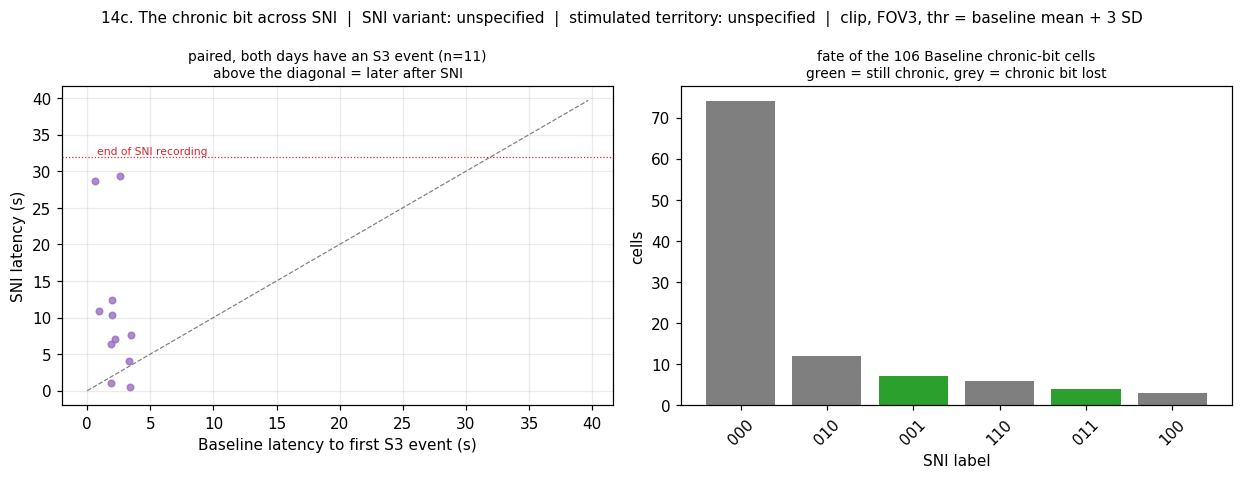


NOT TESTABLE — "delayed beyond the recording"
    A cell that lost the chronic bit is indistinguishable, in these data, from a cell whose
    chronic response starts after the recording stops. The post-withdrawal window is only
    39.7 s at Baseline and 31.9 s after SNI, and the SNI window is 7.8 s SHORTER — so
    part of the 95 lost bits can be nothing but the shorter recording. The
    "common 31.9 s" row above is the comparison that removes that asymmetry; the full-window row
    does not.
    What IS testable is the latency shift among cells that kept the bit, reported above.
    "Delayed beyond the recording" is not a finding this dataset can support or refute.


In [105]:
CLIP_GROUPS = ("010", "011", "001")     # during only | during + chronic | chronic only
CLIP_EXP = "clip"

from scipy.stats import wilcoxon

fov = FOVS[0]
shared, ia, ib = pair_indices(CLIP_EXP, fov)             # same pairing as §11/§12d
base, sni = runs[("Baseline", CLIP_EXP, fov)], runs[("SNI", CLIP_EXP, fov)]
lab_b = base["table"].label.to_numpy()[ia]
lab_s = sni["table"].label.to_numpy()[ib]

# ── a) do the three named groups exist, and which cells are they? ──────────────
print(f"a) Baseline {CLIP_EXP} phenotype groups — {len(shared)} paired ROIs, {fov}\n")
counts = pd.Series(lab_b).value_counts().reindex(LABELS_8, fill_value=0)
named = {"010": "during only", "011": "during + chronic", "001": "chronic only"}
for lab in CLIP_GROUPS:
    ids = shared[lab_b == lab]
    print(f"  {lab}  {named[lab]:<18s} {len(ids):3d} cells "
          f"({100 * len(ids) / len(shared):.0f}% of paired)")
    print(f"        roi_ids: {ids.tolist()}")
print(f"\n  the three groups together: {int((pd.Series(lab_b).isin(CLIP_GROUPS)).sum())} of "
      f"{len(shared)} paired cells. All eight labels for reference:")
display(counts.to_frame("n_baseline_cells").T)
clip_cal = calibration[(calibration.condition == "Baseline")
                       & (calibration.experiment == CLIP_EXP)].set_index("kind")
print(f"  Read against §8b: Baseline {CLIP_EXP} excess over the null was "
      f"{clip_cal.loc['on', 'excess']:+.1f} during and "
      f"{clip_cal.loc['post', 'excess']:+.1f} after, of {clip_cal.loc['on', 'n_roi']} "
      "cells, so these groups sit above chance — unlike the graze windows.")

# ── b) where do those three groups go after SNI? ───────────────────────────────
print(f"\nb) Transitions out of {CLIP_GROUPS}, restricted from the §11 matrix\n")
M = pd.crosstab(pd.Series(lab_b, name="Baseline"), pd.Series(lab_s, name="SNI"))
M = M.reindex(index=LABELS_8, columns=LABELS_8, fill_value=0)
sub = M.loc[list(CLIP_GROUPS)]
sub = sub.loc[:, sub.sum(axis=0) > 0]
display(sub)
print()

for lab in CLIP_GROUPS:
    row = M.loc[lab]
    n = int(row.sum())
    if n == 0:
        continue
    to_000 = int(row["000"])
    # "lost the third bit" = the chronic bit is 1 at Baseline and 0 after, whatever else changed.
    lost_third = int(sum(row[c] for c in LABELS_8 if c[2] == "0")) if lab[2] == "1" else None
    dest = ", ".join(f"{c} x{int(v)}" for c, v in row[row > 0].sort_values(ascending=False).items())
    print(f"  {lab} ({named[lab]}, n={n}) -> {dest}")
    print(f"      to 000: {to_000} ({100 * to_000 / n:.0f}%)"
          + (f"  |  lost the chronic bit: {lost_third} ({100 * lost_third / n:.0f}%)"
             if lost_third is not None else "  |  had no chronic bit to lose"))

# ── c) the chronic bit specifically ────────────────────────────────────────────
S3 = 2                                                    # segment index of "after withdrawal"
win_b = (float(base["edges"][S3]), float(base["edges"][S3 + 1]))
win_s = (float(sni["edges"][S3]), float(sni["edges"][S3 + 1]))
obs_b, obs_s = win_b[1] - win_b[0], win_s[1] - win_s[0]
common = min(obs_b, obs_s)


def first_event_latency(rec: dict, idx: np.ndarray, limit_s: float | None = None) -> np.ndarray:
    """Seconds from withdrawal to the first detected event frame in S3. NaN where there is none.

    `limit_s` truncates the window so both days can be compared over an equal span — the two
    recordings do not run equally long after withdrawal.
    """
    t, seg = rec["time_s"], rec["seg_of_t"]
    m = seg == S3
    if limit_s is not None:
        m = m & (t < rec["edges"][S3] + limit_s)
    ev = rec["det"]["events"][m][:, idx]
    has = ev.any(axis=0)
    first = np.argmax(ev, axis=0)
    return np.where(has, t[m][first] - rec["edges"][S3], np.nan)


chronic = np.array([l[2] == "1" for l in lab_b])
kept_bit = np.array([l[2] == "1" for l in lab_s])
n_chronic = int(chronic.sum())
n_keep = int((chronic & kept_bit).sum())

print(f"\nc) The chronic bit (S3 = after withdrawal)\n")
print(f"  observation window after withdrawal: Baseline {win_b[0]:.0f}–{win_b[1]:.1f} s "
      f"({obs_b:.1f} s)  |  SNI {win_s[0]:.0f}–{win_s[1]:.1f} s ({obs_s:.1f} s)  |  "
      f"common span {common:.1f} s")
print(f"  Baseline cells with S3 bit = 1: {n_chronic}  ->  keep it after SNI: {n_keep} "
      f"({100 * n_keep / max(n_chronic, 1):.0f}%), lose it: {n_chronic - n_keep}")

rows = []
for limit, tag in ((None, f"full window (B {obs_b:.1f} s / S {obs_s:.1f} s)"),
                   (common, f"common {common:.1f} s")):
    lat_b = first_event_latency(base, ia, limit)
    lat_s = first_event_latency(sni, ib, limit)
    sel = chronic & np.isfinite(lat_b) & np.isfinite(lat_s)     # paired: needs both latencies
    d = lat_s[sel] - lat_b[sel]
    stat = wilcoxon(lat_s[sel], lat_b[sel]) if sel.sum() >= 6 else None
    rows.append({"window": tag, "n_paired_with_both": int(sel.sum()),
                 "median_latency_baseline_s": round(float(np.median(lat_b[sel])), 2),
                 "median_latency_sni_s": round(float(np.median(lat_s[sel])), 2),
                 "median_shift_s": round(float(np.median(d)), 2),
                 "n_later_after_sni": int((d > 0).sum()), "n_earlier": int((d < 0).sum()),
                 "wilcoxon_p": round(float(stat.pvalue), 4) if stat else np.nan})
    if limit is None:
        lat_b_full, lat_s_full, sel_full = lat_b, lat_s, sel
lat = pd.DataFrame(rows)
with pd.option_context("display.width", 200, "display.max_columns", None):
    display(lat)
if lat.n_paired_with_both.nunique() == 1 and lat.median_shift_s.nunique() == 1:
    print(f"  truncating to the common {common:.1f} s changed nothing here — every kept-bit cell's "
          "first S3 event on both days already falls inside the shorter window.")
print(f"  n = {int(lat.n_paired_with_both.iloc[0])} pairs. That is a small group and it is not a "
      "random sample: it is exactly the cells whose chronic response survived, so the latency "
      "shift describes the survivors and says nothing about the 95 that did not.")

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.4))
ax = axes[0]
ax.scatter(lat_b_full[sel_full], lat_s_full[sel_full], s=18, color="tab:purple", alpha=0.75)
lim = max(obs_b, obs_s)
ax.plot([0, lim], [0, lim], color="0.5", lw=0.8, ls="--")
ax.axhline(obs_s, color="tab:red", lw=0.8, ls=":")
ax.text(lim * 0.02, obs_s + lim * 0.01, "end of SNI recording", fontsize=7, color="tab:red")
ax.set_xlabel("Baseline latency to first S3 event (s)")
ax.set_ylabel("SNI latency (s)")
ax.set_title(f"paired, both days have an S3 event (n={int(sel_full.sum())})\n"
             "above the diagonal = later after SNI", fontsize=9)
ax.grid(alpha=0.25)

ax = axes[1]
fate = pd.Series(lab_s[chronic]).value_counts().sort_values(ascending=False)
ax.bar(range(len(fate)), fate.values, color=["tab:grey" if l[2] == "0" else "tab:green"
                                             for l in fate.index])
ax.set_xticks(range(len(fate)), fate.index, rotation=45)
ax.set_ylabel("cells")
ax.set_xlabel("SNI label")
ax.set_title(f"fate of the {n_chronic} Baseline chronic-bit cells\n"
             "green = still chronic, grey = chronic bit lost", fontsize=9)
fig.suptitle("14c. The chronic bit across SNI  |  " + provenance(
    f"{CLIP_EXP}, {fov}, thr = baseline mean + {DETECT_K:g} SD"), fontsize=10)
fig.tight_layout()
save_fig(fig, "14c_chronic_latency")
plt.show()

print(f"""
NOT TESTABLE — "delayed beyond the recording"
    A cell that lost the chronic bit is indistinguishable, in these data, from a cell whose
    chronic response starts after the recording stops. The post-withdrawal window is only
    {obs_b:.1f} s at Baseline and {obs_s:.1f} s after SNI, and the SNI window is {obs_b - obs_s:.1f} s SHORTER — so
    part of the {n_chronic - n_keep} lost bits can be nothing but the shorter recording. The
    "common {common:.1f} s" row above is the comparison that removes that asymmetry; the full-window row
    does not.
    What IS testable is the latency shift among cells that kept the bit, reported above.
    "Delayed beyond the recording" is not a finding this dataset can support or refute.""")

## 15. Synchrony — co-activation against a shift null

Cluster firing (the Zheng et al. 2022 direction) is a claim about cells being active *together*,
and nothing above measures that: §9 labels each cell independently, §12 sorts each cell by its own
weight, and §14 counts each cell's own phenotype. Two cells with identical labels may never have
been active in the same frame.

On the **detected event masks** — not the raw rate — restricted to paired ROIs, per condition and
experiment:

- **per frame** — how many cells are simultaneously inside an event;
- **pairwise** — Jaccard over the event masks: shared event frames over frames either cell is in.
  Pairs where neither cell ever has an event are undefined and excluded, not scored 0.

The null circular-shifts each cell independently, reusing §8b's `circular_shift` applied to the
mask so CASCADE's undefined bins stay where they are. Every cell keeps its exact number of event
frames; only the alignment **between** cells is destroyed. The co-activation *total* is therefore
conserved by construction — the printed conservation check confirms it — so only the distribution
over time can move, and the readout is the shape of the trace against the band, never a
whole-recording average. Frames where nothing was measured are masked rather than drawn as zero,
and the band's own chance exceedance (2.5 % of frames) is the reference for the exceedance column.

> **This null does not isolate coupling.** Rotating a cell also destroys its lock to the *stimulus*,
> so common drive clears the band comfortably. A synchronised-cluster claim needs the observed
> trace above the band — but the trace being above the band does not establish the claim, because
> "all these cells were grazed at the same moment" produces exactly that. `excess_stim_off` is the
> partial answer available here: co-activation above the null while the stimulus is off is not
> attributable to everything being driven at once. Separating coupling from common drive properly
> needs a null that preserves each cell's stimulus-locked profile and shuffles only across repeats
> — buildable for graze, which has 12 cycles, and impossible for clip, which has one application.

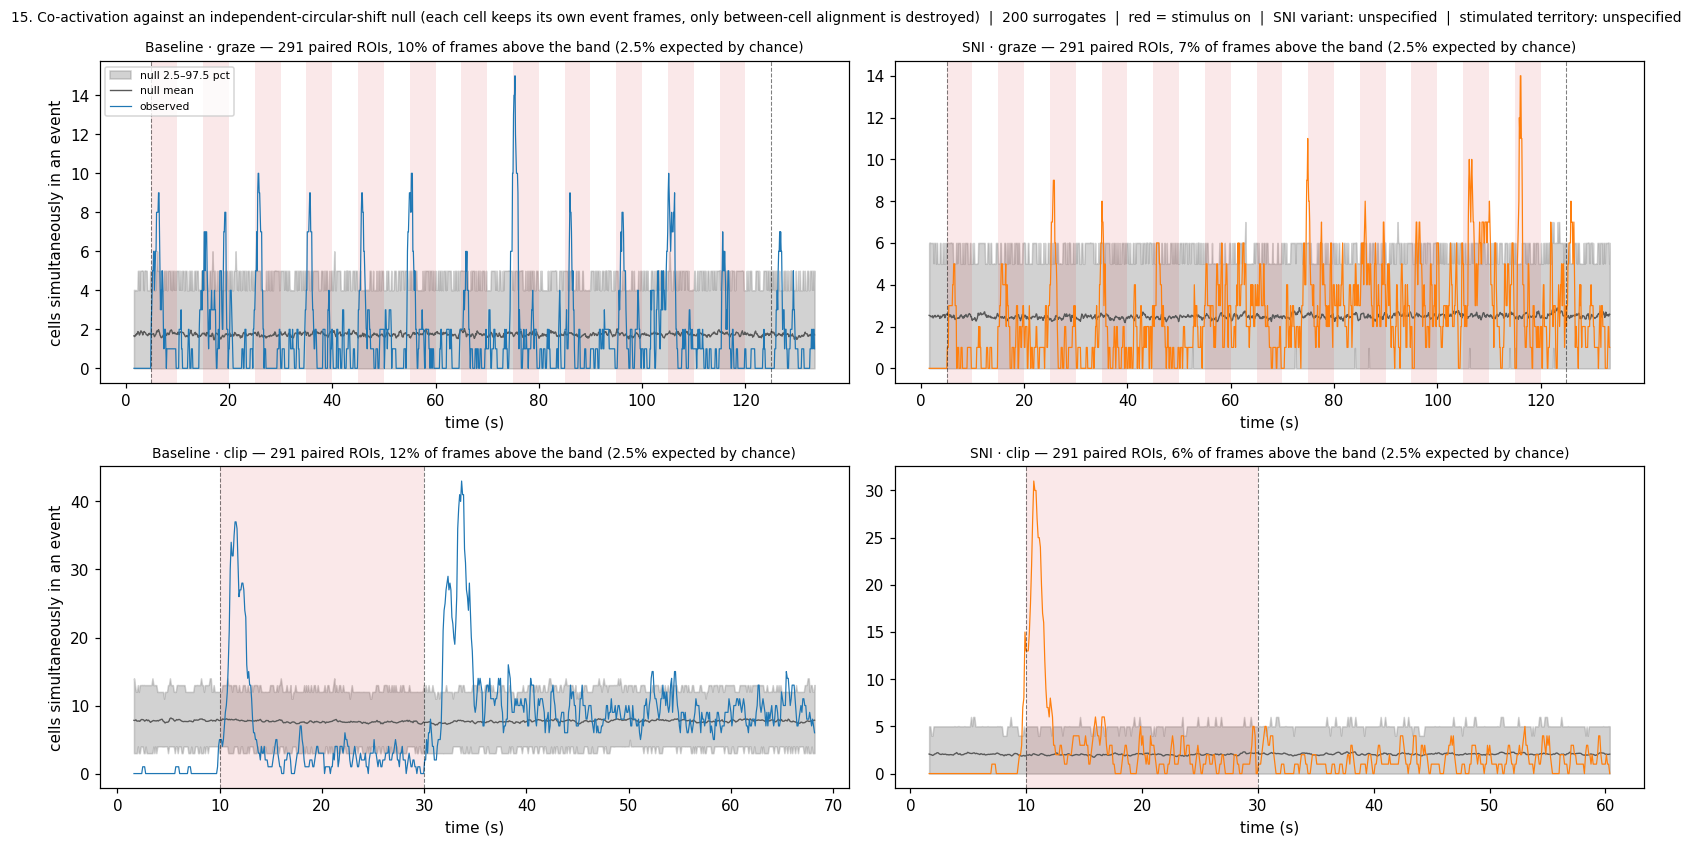

,condition,experiment,n_cells,obs_co_mean,excess_stim_on,excess_stim_off,frames_above_band_%,jaccard_obs,jaccard_null,jaccard_excess,jaccard_p
0,Baseline,graze,291,1.74,0.83,-0.70,10.4,0.0024,0.0012,0.0012,<0.005
1,SNI,graze,291,2.49,0.50,-0.42,6.8,0.0015,0.0011,0.0004,<0.005
2,Baseline,clip,291,7.70,-2.36,1.01,12.0,0.0135,0.0047,0.0088,<0.005
3,SNI,clip,291,2.05,1.64,-0.84,5.7,0.0116,0.0014,0.0102,<0.005



conservation check (observed total co-activation vs mean null total — equal by construction):
  Base graze: 2414 vs 2414  |  SNI graze: 3447 vs 3447  |  Base clip: 5398 vs 5398  |  SNI clip: 1268 vs 1268
chance exceedance of the 97.5th-percentile edge is 2.5% of frames — compare frames_above_band_% against that, not against 0.

WHAT THIS NULL DOES AND DOES NOT SEPARATE
    Rotating each cell independently destroys between-cell alignment — but it also destroys each
    cell's alignment to the STIMULUS. So "observed above the null band" means the cells share
    some temporal structure; it does not say whether they share it because they are coupled or
    because they are all being driven by the same graze or clip. Common drive alone clears this
    null comfortably.
    `excess_stim_off` is the partial answer available here: co-activation above the null while
    the stimulus is off cannot be explained by the stimulus driving everything at once.
    Separating coupling from common driv

In [106]:
SYNC_N_SHIFTS = 200          # circular-shift surrogates per recording
SYNC_BAND_PCT = (2.5, 97.5)  # the null band drawn around the surrogate mean
SYNC_SEED = 0


def paired_event_mask(cond: str, exp: str, fov: str | None = None):
    """Detected-event mask for the paired ROIs only, plus the float form the shifter consumes.

    Undefined (CASCADE-padded) bins are carried as NaN in the float form so `circular_shift`
    leaves them where they are and rotates only the real samples — the same rule as §8b.
    """
    fov = FOVS[0] if fov is None else fov
    rec = runs[(cond, exp, fov)]
    shared, ia, ib = pair_indices(exp, fov)
    idx = ia if cond == "Baseline" else ib
    ev = rec["det"]["events"][:, idx]
    finite = np.isfinite(rec["rate"][:, idx])
    return rec, ev, np.where(finite, ev.astype(np.float32), np.nan), finite


def mean_jaccard(ev: np.ndarray) -> float:
    """Mean pairwise Jaccard over the event masks: shared event frames / frames either is in.

    Pairs where neither cell ever has an event are undefined and excluded, not scored 0.
    """
    M = ev.astype(np.float32)
    inter = M.T @ M
    cnt = np.diag(inter).copy()
    union = cnt[:, None] + cnt[None, :] - inter
    iu = np.triu_indices(len(cnt), 1)
    j = np.divide(inter[iu], union[iu], out=np.full(len(iu[0]), np.nan, dtype=np.float32),
                  where=union[iu] > 0)
    return float(np.nanmean(j))


def synchrony(cond: str, exp: str, fov: str | None = None) -> dict:
    """Observed co-activation against an independent-circular-shift null.

    The null rotates each cell's own event mask by its own random offset. Every cell keeps its
    exact number of event frames; only the alignment BETWEEN cells is destroyed. (A rotation can
    split one run across the wrap, so event-FRAME counts are preserved exactly while event
    counts can move by one per cell — immaterial at these run lengths.)
    """
    rec, ev, masked, finite = paired_event_mask(cond, exp, fov)
    rng = np.random.default_rng(SYNC_SEED)
    obs_co = ev.sum(axis=1).astype(float)
    obs_j = mean_jaccard(ev)

    null_co = np.empty((SYNC_N_SHIFTS, ev.shape[0]))
    null_j = np.empty(SYNC_N_SHIFTS)
    for k in range(SYNC_N_SHIFTS):
        ev_null = circular_shift(masked, rng) > 0.5      # NaN compares False -> never active
        null_co[k] = ev_null.sum(axis=1)
        null_j[k] = mean_jaccard(ev_null)

    lo, hi = np.percentile(null_co, SYNC_BAND_PCT, axis=0)

    # Frames where every cell is undefined (CASCADE's edge padding) are not "nobody was active" —
    # they are "nothing was measured". Mask them so the line breaks instead of touching 0.
    defined = finite.any(axis=1)
    blank = lambda a: np.where(defined, a, np.nan)
    return {"rec": rec, "t": rec["time_s"], "n_cells": ev.shape[1], "defined": defined,
            "obs_co": blank(obs_co), "null_mean": blank(null_co.mean(axis=0)),
            "lo": blank(lo), "hi": blank(hi), "obs_j": obs_j, "null_j": null_j,
            "conserved": (float(np.nansum(obs_co)), float(null_co.sum(axis=1).mean()))}


SYNC = {(cond, exp): synchrony(cond, exp) for exp in EXPERIMENTS for cond in CONDITIONS}

# ── FIGURE — co-activation over time against the null band ─────────────────────
fig, axes = plt.subplots(len(EXPERIMENTS), len(CONDITIONS), squeeze=False,
                         figsize=(7.4 * len(CONDITIONS), 3.9 * len(EXPERIMENTS)))
for r, exp in enumerate(EXPERIMENTS):
    for c, cond in enumerate(CONDITIONS):
        s = SYNC[(cond, exp)]
        ax, t = axes[r][c], s["t"]
        ax.fill_between(t, s["lo"], s["hi"], color="tab:grey", alpha=0.35,
                        label=f"null {SYNC_BAND_PCT[0]}–{SYNC_BAND_PCT[1]} pct")
        ax.plot(t, s["null_mean"], color="0.35", lw=0.9, label="null mean")
        ax.plot(t, s["obs_co"], color=COND_COLOR[cond], lw=0.8, label="observed")
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            ax.axvspan(x0, x1, color="tab:red", alpha=0.10, lw=0)
        for edge in (s["rec"]["edges"][1], s["rec"]["edges"][-2]):
            ax.axvline(edge, color="k", lw=0.7, ls="--", alpha=0.5)
        d = s["defined"]
        above = (s["obs_co"] > s["hi"])[d]
        ax.set_xlabel("time (s)")
        ax.set_ylabel("cells simultaneously in an event" if c == 0 else "")
        ax.set_title(f"{cond} · {exp} — {s['n_cells']} paired ROIs, "
                     f"{100 * above.mean():.0f}% of frames above the band "
                     f"({100 - SYNC_BAND_PCT[1]:.1f}% expected by chance)", fontsize=9)
        if r == 0 and c == 0:
            ax.legend(fontsize=7, loc="upper left")
fig.suptitle("15. Co-activation against an independent-circular-shift null (each cell keeps its "
             f"own event frames, only between-cell alignment is destroyed)  |  {SYNC_N_SHIFTS} "
             "surrogates  |  red = stimulus on  |  " + provenance(), fontsize=9)
fig.tight_layout()
save_fig(fig, "15_coactivation")
plt.show()

rows = []
for exp in EXPERIMENTS:
    for cond in CONDITIONS:
        s = SYNC[(cond, exp)]
        t, d = s["t"], s["defined"]
        on = np.zeros(len(t), bool)
        for x0, x1 in stimulus_spans(exp, float(t[-1])):
            on |= (t >= x0) & (t < x1)
        excess = s["obs_co"] - s["null_mean"]
        p_j = (1 + int((s["null_j"] >= s["obs_j"]).sum())) / (1 + SYNC_N_SHIFTS)
        rows.append({
            "condition": cond, "experiment": exp, "n_cells": s["n_cells"],
            "obs_co_mean": round(float(np.nanmean(s["obs_co"])), 2),
            "excess_stim_on": round(float(np.nanmean(excess[on & d])), 2),
            "excess_stim_off": round(float(np.nanmean(excess[~on & d])), 2),
            "frames_above_band_%": round(100 * float((s["obs_co"] > s["hi"])[d].mean()), 1),
            "jaccard_obs": round(s["obs_j"], 4),
            "jaccard_null": round(float(s["null_j"].mean()), 4),
            "jaccard_excess": round(s["obs_j"] - float(s["null_j"].mean()), 4),
            "jaccard_p": f"<{p_j:.3f}" if p_j <= 1 / SYNC_N_SHIFTS else f"{p_j:.3f}"})
with pd.option_context("display.width", 220, "display.max_columns", None):
    display(pd.DataFrame(rows))

# Conservation check, not a result: the shift preserves every cell's event-frame count, so the
# co-activation TOTAL is identical under the null by construction. Only its distribution over
# time can differ — which is why there is no "excess averaged over the whole recording" column.
print("\nconservation check (observed total co-activation vs mean null total — equal by "
      "construction):\n  " + "  |  ".join(
          f"{cond[:4]} {exp}: {SYNC[(cond, exp)]['conserved'][0]:.0f} vs "
          f"{SYNC[(cond, exp)]['conserved'][1]:.0f}"
          for exp in EXPERIMENTS for cond in CONDITIONS))
print(f"chance exceedance of the {SYNC_BAND_PCT[1]}th-percentile edge is "
      f"{100 - SYNC_BAND_PCT[1]:.1f}% of frames — compare frames_above_band_% against that, "
      "not against 0.")

print("""
WHAT THIS NULL DOES AND DOES NOT SEPARATE
    Rotating each cell independently destroys between-cell alignment — but it also destroys each
    cell's alignment to the STIMULUS. So "observed above the null band" means the cells share
    some temporal structure; it does not say whether they share it because they are coupled or
    because they are all being driven by the same graze or clip. Common drive alone clears this
    null comfortably.
    `excess_stim_off` is the partial answer available here: co-activation above the null while
    the stimulus is off cannot be explained by the stimulus driving everything at once.
    Separating coupling from common drive properly needs a null that preserves each cell's
    stimulus-locked profile and shuffles only across repeats — buildable for graze, which has 12
    cycles, and not for clip, which has one application.

    A synchronised-cluster claim (cf. Zheng et al. 2022) needs the observed trace ABOVE the band.
    A high co-activation count on its own is what you expect whenever many cells respond to the
    same stimulus, and is not evidence of cluster firing.""")

## Not answerable from this dataset

Stated here rather than left for the figures to imply. Nothing above addresses any of these, and no
parameter change in this notebook would make it do so.

**Cell type / neuron subtype.** There is no marker channel in these recordings — one functional
channel, no genetic label, no post-hoc stain registered to the ROIs. The claim that
de-sensitisation is specific to a neuron class (nociceptor, LTMR, proprioceptor) can be neither
supported nor refuted with these data. ROI size is not a subtype proxy either: it comes from the
segmentation, not from soma diameter.

**Which nerve carries which response.** This needs the SNI variant — which branches were ligated,
which spared — and the stimulated skin territory. Neither is in the files, so both are config
strings, `SNI_VARIANT` and `STIM_TERRITORY` in §12d, printed in every caption from §12d on. They
are typed in, not inferred, and they are currently `"unspecified"`.

> Laterality is not settled by the files either: the loaded traces are named
> `RightDRG_FOV3_Graze_FOOT_…` while `TRACE_ROOT` points at `…/leftDRGcut`. That inconsistency is in
> the source data, not in the code. Confirm against the lab record before any territory or nerve
> claim, and fill in the two strings above at the same time.

**A chronic / post-stimulus response in graze.** The window after the 12th cycle is 9.9 s (§8). That
is too short to separate a sustained response from the tail of the last graze, so graze cannot carry
a chronic claim at all. What it *can* carry is `on_gap_ratio` (§9B) — activity persisting into the
5 s gap after each graze. Those are different statements and must not be reported in the same words.

**"The signal was replaced by another FOV."** This needs the other fields loaded, and `FOVS` is
currently `("FOV3",)`. Adding `FOV1`/`FOV2` to that tuple is the entire change — every section here
already loops over `FOVS` and pairs within a field — but nothing in the present run speaks to it.

**Scale.** One animal, one session, one field. Every percentage printed above has cells for its
denominator, not mice, and the two days are two recordings rather than two samples.